# Notebook for generating Figures in Balogh et al. (2026)

# Imports, Directories and constants

In [1]:
# Imports and formatting
import csv
import numpy as np
import h5py, json
import os, re, fnmatch
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from itertools import cycle
from itertools import product
from datetime import datetime
from matplotlib.colors import LogNorm
from matplotlib.ticker import ScalarFormatter, FuncFormatter
from DiscEvolution.constants import *
from DiscEvolution.chemistry import *
from scipy.ndimage import uniform_filter1d
import matplotlib.ticker as ticker
from email import header

pd.set_option("display.max_colwidth", None)


In [5]:
# Directories
BASEDIR='/Users/mbalogh/projects/PlanetFormation/python'
DATADIR=BASEDIR+'/output/HJpaper/V3/'
LITDATA=BASEDIR+'/litdata/'
CODEDIR=BASEDIR+'/DiscEvolution'
WORKINGDIR=CODEDIR+'/example/summer_2025/V3/'
FIGDIR=WORKINGDIR+'Figs/'

# constants 
m_Jupiter = 317.8 # earth masses

# Chemistry
#solar_H_fraction=0.73 # by mass
X_H_solar = 0.73
X_He_solar = 0.25
mu_H = 1.0
mu_He = 4.0
mu_HHe = 2.3     # mean molecular weight of H+He mixture
Y_H = 0.92       # hydrogen fraction in primordial mixture
OH_solar = 0.00784 # mass
CH_solar = 0.00324 # mass
SiH_solar = 3.2e-5*28. # mass
CH_solar_number=CH_solar/12.
OH_solar_number=OH_solar/16.
SiH_solar_number=SiH_solar/28. 
OSi_solar_number=OH_solar_number/SiH_solar_number
Z_solar=0.02
SEC_PER_YEAR = 365.25 * 24.0 * 3600.0
ERAD_FIXED = 0.9
MU_GAS = 2.4


# key parameters
giant_thresh = 100  # Earth masses
psi_viscous = 0.01   # Viscous model psi value
psi_wind = 10       # Wind model psi value
# Define initial radius array 
initial_radii_au = [1, 2, 3, 4, 5, 7, 10, 15, 20, 25, 30]  # AUyr

# Global execution switches
GENERATE_PKL = True # Set to true to regenerate pkl files from output.  Slow.

# Main method to read .h5 output files

In [3]:
# Method to read HDF5output files 
def load_data(fname,planets=True):
    """
    Load disc evolution output file (HDF5 only).
    
    Returns dict in JSON-equivalent format with consistent shapes.
    """

    with h5py.File(fname, "r") as f:
        data = {}
        # Extract psi value from filename (e.g. "...psi0.01_Mdot...")
        psi = None
        m = re.search(r"psi([0-9.eE+-]+)", os.path.basename(fname))
        if m:
            psi = float(m.group(1))
        # Scalars
        for key in ["t", "disk_Mdot_star", "disk_Mass", "Tc", "Sigc"]:
            if key in f:
                data[key] = f[key][()].tolist()
        data["alpha_SS"] = f.attrs.get("alpha_SS", None)
        data["psi"] = psi
        # Helper for ragged vs extendable vs single-dump
        def read_array(obj):
            if isinstance(obj, h5py.Dataset):       # dataset directly
                arr = obj[()]
                if np.ndim(arr) == 0:   # scalar
                    return [float(arr)]
                return np.array(arr).tolist()
            elif isinstance(obj, h5py.Group):       # ragged group
                vals = [obj[k][()] for k in sorted(obj.keys(), key=int)]
                return [float(v) for v in vals]
            else:
                raise TypeError(f"Unexpected type {type(obj)}")

        # ---------------- Per-planet arrays ----------------
        if (planets):
            data["Mcs"], data["Mes"], data["Rp"], data["disk_Mdot_p"] = [], [], [], []

            if isinstance(f.get("Mcs"), h5py.Dataset):
                # Single dataset case
                arr = np.array(f["Mcs"])
                data["Mcs"] = [row.tolist() if arr.ndim > 1 else [float(x)] for row in np.atleast_2d(arr)]
            else:
                for ip in sorted(f["Mcs"].keys(), key=int):
                    data["Mcs"].append(read_array(f["Mcs"][ip]))

            if isinstance(f.get("Mes"), h5py.Dataset):
                arr = np.array(f["Mes"])
                data["Mes"] = [row.tolist() if arr.ndim > 1 else [float(x)] for row in np.atleast_2d(arr)]
            else:
                for ip in sorted(f["Mes"].keys(), key=int):
                    data["Mes"].append(read_array(f["Mes"][ip]))

            if isinstance(f.get("Rp"), h5py.Dataset):
                arr = np.array(f["Rp"])
                data["Rp"] = [row.tolist() if arr.ndim > 1 else [float(x)] for row in np.atleast_2d(arr)]
            else:
                for ip in sorted(f["Rp"].keys(), key=int):
                    data["Rp"].append(read_array(f["Rp"][ip]))

            if isinstance(f.get("disk_Mdot_p"), h5py.Dataset):
                arr = np.array(f["disk_Mdot_p"])
                data["disk_Mdot_p"] = [row.tolist() if arr.ndim > 1 else [float(x)] for row in np.atleast_2d(arr)]
            else:
                for ip in sorted(f["disk_Mdot_p"].keys(), key=int):
                    data["disk_Mdot_p"].append(read_array(f["disk_Mdot_p"][ip]))
        # alpha_SS handling
        if "alpha_SS" in f.attrs:             # new streaming files
            data["alpha_SS"] = float(f.attrs["alpha_SS"])
        elif "alpha_SS" in f:                  # old single-dump files
            data["alpha_SS"] = f["alpha_SS"][()]
        else:
            data["alpha_SS"] = None
        # File attributes
        data["complete"] = f.attrs.get("complete", False)

        # ---------------- Chemistry ----------------
        if (planets):
            data["X_cores"], data["X_envs"] = [], []
            if "X_cores" in f:
                if isinstance(f["X_cores"], h5py.Dataset):
                    # Single dataset case — probably shaped (nplanets, nspecies, nsteps?)
                    arr_core = np.array(f["X_cores"])
                    arr_env  = np.array(f["X_envs"])
                    nplanets = arr_core.shape[0]
                    for ip in range(nplanets):
                        core_species = [arr_core[ip, js, :].tolist() for js in range(arr_core.shape[1])]
                        env_species  = [arr_env[ip, js, :].tolist()  for js in range(arr_env.shape[1])]
                        data["X_cores"].append(core_species)
                        data["X_envs"].append(env_species)
                else:
                    # Group → streaming or ragged format
                    for ip in sorted(f["X_cores"].keys(), key=int):
                        core_species = []
                        env_species  = []
                        for js in sorted(f["X_cores"][ip].keys(), key=int):
                            core_species.append(read_array(f["X_cores"][ip][js]))
                        for js in sorted(f["X_envs"][ip].keys(), key=int):
                            env_species.append(read_array(f["X_envs"][ip][js]))
                        data["X_cores"].append(core_species)
                        data["X_envs"].append(env_species)


        # ---------------- Disk profiles ----------------
        if "R" in f:
            data["R"] = f["R"][:].tolist()
        else:
            nR = f["Sigma_G"].shape[1]
            data["R"] = list(range(nR))  # placeholder if R not saved

        for key in ["Sigma_G", "Sigma_dust", "Sigma_pebbles", "T", "Sigma_pebble_size", "Vdrift"]:
            if key in f:
                data[key] = f[key][:].tolist()
        if "Sigma_planetesimals" in f:
            data["Sigma_planetesimals"] = f["Sigma_planetesimals"][:].tolist()
        if "time_snap" in f:
            data["time_snap"] = f["time_snap"][:].tolist()
        # Extract ice line locations (water ice line)
        if "disk_ice_lines" in f:
            data["disk_ice_lines"] = f["disk_ice_lines"][:].tolist()
        chemdata=True
        try:
            for key in ["disk_atom_gas_abund", "disk_mol_gas_abund",
                        "disk_atom_ice_abund", "disk_mol_ice_abund",
                        "disk_planetesimal_atom_abund", "disk_planetesimal_mol_abund"]:
                if key in f:
                    data[key] = np.array(f[key][:], dtype=float).tolist()
        except:
            chemdata=False


    # ---------------- Normalize shapes ----------------
    data["R"] = np.array(data["R"], dtype=float).squeeze()  # always (nR,)

    for key in ["Sigma_G", "Sigma_dust", "Sigma_pebbles", "Sigma_planetesimals", "T", "Sigma_pebble_size"]:
        if key in data:
            arr = np.array(data[key], dtype=float)
            arr = np.atleast_2d(arr)          # (nsnapshots, nR)
            if arr.ndim == 3 and arr.shape[1] == 1:
                arr = arr[:, 0, :]           # squeeze accidental middle dim
            data[key] = arr

    # Ensure R is always 1D
    data["R"] = np.array(data["R"], dtype=float)

    if data["R"].ndim == 2:
        # Old HDF5 case: R repeated for each snapshot
        # Keep just one copy (they should all be identical)
        data["R"] = data["R"][0, :]

    data["R"] = data["R"].squeeze()


    # Normalize disk profile arrays to (nsnap, nR)
    for key in ["Sigma_G", "Sigma_dust", "Sigma_pebbles", "Sigma_planetesimals", "T", "Sigma_pebble_size"]:
        if key in data:
            arr = np.array(data[key], dtype=float)
            arr = np.atleast_2d(arr)  # (nsnap, nR)
            if arr.ndim == 3 and arr.shape[1] == 1:
                arr = arr[:, 0, :]
            data[key] = arr
    if "time_snap" in data:
        data["time_snap"] = np.array(data["time_snap"], dtype=float)
    # Normalize disk_ice_lines to (nsnap, nR)
    if "disk_ice_lines" in data:
        arr = np.array(data["disk_ice_lines"], dtype=float)
        arr = np.atleast_2d(arr)  # (nsnap, nR)
        if arr.ndim == 3 and arr.shape[1] == 1:
            arr = arr[:, 0, :]
        data["disk_ice_lines"] = arr
    if (chemdata):
        for key in ["disk_atom_gas_abund", "disk_mol_gas_abund",
                    "disk_atom_ice_abund", "disk_mol_ice_abund",
                    "disk_planetesimal_atom_abund", "disk_planetesimal_mol_abund"]:
            if key in data:
                arr = np.array(data[key], dtype=float)
                # Expected shape: (nsnap, Nspecies, nR)
                if arr.ndim == 2:  # in case nsnap=1
                    arr = arr[np.newaxis, ...]
                data[key] = arr

    return data


# Don't Normally Run this!! Loop over all files in output directory.  Get information about all planets formed, and their disks

In [27]:
# Get data from all output files, store in df and save as pkl
alt=False # Set to true to load "noplan" files instead of "winds" files
expected_tfinal = 3.0e6   # yr
tol = 5e5                 # acceptance tolerance around final time

if not GENERATE_PKL:
    print ("Skipping pkl generation, using existing files. Set GENERATE_PKL=True to regenerate from raw output.  This can be slow.")
else:
    file_rows = []     # 1 entry per file
    planet_rows = []   # 1 entry per planet (flattened)

    # -------------------------------------------------------------
    # MAIN LOOP OVER FILES
    # -------------------------------------------------------------
    print (DATADIR)
    if alt:
        _dir = DATADIR + "noplan/"
        _prefix = "noplan_"
    else:
        _dir = DATADIR
        _prefix = "winds_"

    print(_dir)
    for fname in os.listdir(_dir):
        if not (fname.startswith(_prefix) and fname.endswith(".h5")):
            continue

        fpath = os.path.join(_dir, fname)

        try:
            # =====================================================
            # Load raw simulation output
            # =====================================================
            data = load_data(fpath)

            # Skip if no time series
            if "t" not in data or len(data["t"]) == 0:
                continue

            time = np.array(data["t"], dtype=float)
            last_t = time[-1]

            # =====================================================
            # Determine whether simulation is "complete"
            # =====================================================
            is_complete = bool(data.get("complete", False))
            if (not is_complete) and abs(last_t - expected_tfinal) <= tol:
                is_complete = True

            # =====================================================
            # Parse psi and Rd from filename
            # =====================================================
            psi_match = re.search(r"psi([0-9.eE+-]+)", fname)
            psi = float(psi_match.group(1)) if psi_match else None

            Rd = None
            m = re.search(r"_Rd([0-9.eE+-]+)(?=\.h5$)", fname)
            if m:
                Rd = float(m.group(1))


            
            # -----------------------------------------------------
            # Now extract final-time chemistry for each planet
            # -----------------------------------------------------
            nplanets = len(data["Mcs"])
            final_time_index = -1

            Mcs = [np.array(mc) for mc in data["Mcs"]]
            Mes = [np.array(me) for me in data["Mes"]]
            Rps = [np.array(rp) for rp in data["Rp"]]
            X_cores = [np.array(xc) for xc in data["X_cores"]]
            X_envs  = [np.array(xe) for xe in data["X_envs"]]


            # Loop planets
            for ip in range(nplanets):

                Mcf = Mcs[ip][final_time_index]
                Mef = Mes[ip][final_time_index]
                Mpf = Mcf + Mef# 
                #------- Extract final-step chemistry for this planet -------
                final = -1

                Xc_final = np.array(X_cores[ip])[:, final]   # shape: (Nspecies,)
                Xe_final = np.array(X_envs[ip])[:, final]    # shape: (Nspecies,)
                Mc_final = float(Mcs[ip][final])
                Me_final = float(Mes[ip][final])

                chem_final = {
                    "X_core": Xc_final,
                    "X_env": Xe_final,
                    "Mc": Mc_final,
                    "Me": Me_final,
                }


            # =====================================================
                # Compute envelope mass accreted within water ice line
                # =====================================================
                # H2O species is at index 3 in SimpleCOMolAbund: ['CO','CH4','CO2','H2O','C-grain','Si-grain']
                h2o_idx = 3
            
                if "disk_ice_lines" in data and data["disk_ice_lines"].shape[1] > h2o_idx:
                    ice_lines_final = data["disk_ice_lines"][-1]  # Final timestep, shape: (Nspec,)
                    h2o_ice_line = ice_lines_final[h2o_idx]       # H2O ice line radius in AU
                
                    # Compute envelope mass accreted within H2O ice line for this planet
                    # Use time-integrated calculation: find mass accreted while R_planet < ice_line
                    env_mass_within_h2o = 0.0
                    for t_idx in range(len(Mes[ip])):
                        if Rps[ip][t_idx] < h2o_ice_line:
                            # Planet is interior to ice line, accumulate envelope change
                            if t_idx == 0:
                                env_mass_within_h2o += Mes[ip][t_idx]
                            else:
                                env_mass_within_h2o += max(0, Mes[ip][t_idx] - Mes[ip][t_idx-1])
                
                    env_frac_within_h2o = env_mass_within_h2o / max(Mef, 1e-10)
                else:
                    env_frac_within_h2o = np.nan

                planet_rows.append({
                        # IDENTIFIERS
                        "file": fname,
                        "env_frac_within_h2o_line": env_frac_within_h2o,
                        "planet_index": ip,

                        # MASSES AND POSITIONS
                        "final_mass": Mpf,
                        "final_core_mass": Mcf,
                        "final_env_mass": Mef,
                        "final_r": Rps[ip][final_time_index],

                        # CHEMISTRY 
                        "chem_final": chem_final,

                        # SIMULATION METADATA
                        "psi": psi,
                        "Rd": Rd,
                        "alpha_SS": data.get("alpha_SS", None),
                        "complete": is_complete,
                        "last_t": last_t,
                    })

            # =====================================================
            # Disk properties – store file-level info
            # =====================================================
            Mdisk = np.array(data["disk_Mass"], dtype=float)
            Mdot  = np.array(data["disk_Mdot_star"], dtype=float)

            # Interpolate at fixed times
            Mdisk_1e4 = np.interp(1e4, time, Mdisk)
            Mdisk_1e3 = np.interp(1e3, time, Mdisk)
            Mdot_1e4  = np.interp(1e4, time, Mdot)
            Mdot_1e3  = np.interp(1e3, time, Mdot)

            # --------------------------------------------------------------
            # Disk properties – store BOTH summary values AND full history
            # --------------------------------------------------------------
            file_rows.append({
                "file": fname,
                "psi": psi,
                "Rd": Rd,
                "complete": is_complete,
                "last_t": last_t,

                # Full disk histories (small arrays, safe to store)
                "time":     np.array(time, dtype=float),
                "Mdisk":    np.array(Mdisk, dtype=float),
                "Mdot":     np.array(Mdot, dtype=float),

                # Summary values for convenience
                "disk_mass_t1e4": Mdisk_1e4,
                "disk_mdot_t1e4": Mdot_1e4,
                "disk_mass_t1e3": Mdisk_1e3,
                "disk_mdot_t1e3": Mdot_1e3,

                "alpha_SS": data.get("alpha_SS", None),
            })

        except Exception as e:
            print(f"Error in file {fname}: {e}")

    # -------------------------------------------------------------
    # Convert to DataFrames
    # -------------------------------------------------------------
    df_files = pd.DataFrame(file_rows)
    df_planets = pd.DataFrame(planet_rows)

    print("Processed", len(df_files), "files")
    print("Planets:", df_planets.shape)

    # Save to pkl file
    df=df_files
    if alt:
        df.to_pickle(WORKINGDIR+"df_all_noplan.pkl")
        df_planets.to_pickle(WORKINGDIR+"df_planets_noplan.pkl")
    else:
        df.to_pickle(WORKINGDIR+"df_all.pkl")
        df_planets.to_pickle(WORKINGDIR+"df_planets.pkl")

/Users/mbalogh/projects/PlanetFormation/python/output/HJpaper/V3/
/Users/mbalogh/projects/PlanetFormation/python/output/HJpaper/V3/
Error in file winds_mig_psi10.0_Mdot3.0e-08_M1.2e-01_Rd5.0e+01.h5: Can't read data (addr overflow, addr = 159660760, size = 2096, eoa = 150835880)
Processed 255 files
Planets: (2805, 13)


# Main helper functions

## CHEMICAL HELPER FUNCTIONS AND DEFINITIONS

In [7]:
# === CHEMICAL HELPER FUNCTIONS AND DEFINITIONS ===

# -------------------------------------------------------------
# GLOBAL CONSTANTS: Species metadata (computed once)
# -------------------------------------------------------------
_mol_test = SimpleCOMolAbund(1)
SPECIES = list(_mol_test.species)  # ['CO','CH4','CO2','H2O','C-grain','Si-grain']
ice_line_indices={"H2O": 3, "CO2": 2, "CO": 0}
MASS = np.array(_mol_test.masses)  # molecular masses

# Hydrogen atoms per molecule
H_ATOMS = {
    "CO": 0,
    "CH4": 4,
    "CO2": 0,
    "H2O": 2,
    "C-grain": 0,
    "Si-grain": 0,
}


# Species indices by type
VOLATILE_NAMES = ["CO", "CH4", "CO2", "H2O"]
REFRACTORY_NAMES = ["C-grain", "Si-grain"]
VOL_IDX = [SPECIES.index(s) for s in VOLATILE_NAMES]
REFR_IDX = [SPECIES.index(s) for s in REFRACTORY_NAMES]

# Element indices for atomic abundance arrays
iC = 0   # index of C in Natom
iO = 1   # index of O in Natom
iSi = 2  # index of Si in Natom

# -------------------------------------------------------------
# GLOBAL CONSTANTS: Solar reference abundances (computed once)
# -------------------------------------------------------------
_solar_ref = SimpleCOAtomAbund(1)
_solar_ref.set_solar_abundances()

SOLAR_C = _solar_ref.number_abund("C")[0]
SOLAR_O = _solar_ref.number_abund("O")[0]
SOLAR_Si = _solar_ref.number_abund("Si")[0]

# Solar H from H/He mixture (primordial composition ONLY)
# This is the correct basis for solar-scaled abundances [X/H]
SOLAR_H = X_H_solar/mu_H / (X_H_solar/mu_H + X_He_solar/mu_He)

# Solar ratios (all use primordial H basis)
SOLAR_CO = SOLAR_C / SOLAR_O
SOLAR_CH = SOLAR_C / SOLAR_H
SOLAR_OH = SOLAR_O / SOLAR_H
SOLAR_SiH = SOLAR_Si / SOLAR_H
SOLAR_CSi = SOLAR_C / SOLAR_Si
SOLAR_OSi = SOLAR_O / SOLAR_Si

print(f"Solar abundances:")
print(f"  C  = {SOLAR_C:.3e},  O  = {SOLAR_O:.3e},  Si = {SOLAR_Si:.3e}")
print(f"  C/H = {SOLAR_CH:.3e}, O/H = {SOLAR_OH:.3e}, Si/H = {SOLAR_SiH:.3e}")
print(f"  (H basis: primordial H/He only, consistent with Chachan et al.)")


# -------------------------------------------------------------
# HELPER: Compute hydrogen number density
# -------------------------------------------------------------
def compute_hydrogen(X_env, hydrogen_model="full"):
    """
    Compute hydrogen number density from envelope composition.
    
    IMPORTANT: For solar-scaled ratios [X/H] (Chachan et al. style), you should 
    use hydrogen_model="primordial" to match the solar reference (SOLAR_H), which 
    uses only primordial H/He. The "full" model includes molecular H and is 
    appropriate for absolute abundances but creates inconsistency when scaling.
    
    Parameters
    ----------
    X_env : array, shape (Nspecies, Ntime) or (Nspecies,)
        Mass fractions of molecular species in envelope
    hydrogen_model : str
        "full"       - primordial H + molecular H (physically correct, but 
                       inconsistent with solar scaling)
        "primordial" - only primordial H/He (retrieval-style, matches SOLAR_H)
        "solar"      - constant solar H number density (=SOLAR_H everywhere)
        
    Returns
    -------
    nH : array, shape (Ntime,) or scalar
        Hydrogen number density
    """
    is_1d = (X_env.ndim == 1)
    if is_1d:
        X_env = X_env[:, None]  # (Nspecies, 1)
    
    nt = X_env.shape[1]
    
    # Primordial H from H/He gas (same calculation as SOLAR_H)
    XZ_env = X_env.sum(0)  # heavy-element mass fraction
    X_HHe_env = 1 - XZ_env  # primordial gas mass fraction
    #nH_primordial = (X_HHe_env / mu_HHe) * Y_H
    nH_primordial = X_HHe_env * Y_H
    
    if hydrogen_model == "primordial":
        nH = nH_primordial
        
    elif hydrogen_model == "full":
        # Add molecular hydrogen contribution
        # WARNING: This makes [X/H] scaling inconsistent with SOLAR_H
        nH_molec = np.zeros(nt)
        for i, s in enumerate(SPECIES):
            nh = H_ATOMS[s]
            if nh > 0:
                nH_molec += (X_env[i, :] / MASS[i]) * nh
        nH = nH_primordial + nH_molec
        
    elif hydrogen_model == "solar":
        # Use constant solar hydrogen number density
        nH = np.full(nt, SOLAR_H)
        
    else:
        raise ValueError(f"Invalid hydrogen_model: {hydrogen_model}")
    
    if is_1d:
        nH = nH[0]
    
    return nH


# -------------------------------------------------------------
# MAIN FUNCTION: Time-series abundance ratios
# -------------------------------------------------------------
def compute_abundance_ratios(
    data,
    by_number=True,
    scaled_to_solar=False,
    hydrogen_model="full",
    cache=True
):
    """
    Compute abundance ratios for full time-series DiscEvolution output.

    IMPORTANT: When scaled_to_solar=True, this function automatically uses 
    hydrogen_model="primordial" to ensure consistency with the solar reference 
    (SOLAR_H), following Chachan et al. conventions for [X/H] ratios.

    Parameters
    ----------
    data : dict
        Output of load_data() containing Mcs, Mes, X_cores, X_envs
    by_number : bool
        If True, atomic abundances are in number density
    scaled_to_solar : bool
        If True, scale all ratios to solar values. When True, hydrogen_model
        is automatically set to "primordial" for consistency.
    hydrogen_model : str
        "full" (default) - primordial H + molecular H (absolute abundances)
        "primordial"     - only primordial H/He (for solar-scaled [X/H])
        "solar"          - constant SOLAR_H (alternative solar scaling)
        NOTE: This is overridden to "primordial" when scaled_to_solar=True
    cache : bool
        If True, store results in data['ratios']

    Returns
    -------
    ratios : dict
        Keys: C/O_total, C/O_env, C/O_core,
              C/H_total, O/H_total, Si/H_total, Si/H_env,
              C/Si_total, C/Si_env, C/Si_core,
              O/Si_total, O/Si_env, O/Si_core,
              C/H_env, O/H_env,
              vol_refrac_env, volatile_mass_frac_total,
              metallicity_total
    """
    # CRITICAL: Enforce primordial H when computing solar-scaled ratios
    # This ensures consistency with SOLAR_H (which uses primordial H only)
    if scaled_to_solar and hydrogen_model == "full":
        print("INFO: scaled_to_solar=True enforces hydrogen_model='primordial' for consistency with SOLAR_H")
        hydrogen_model = "primordial"
    
    # Output containers
    ratios = {
        "C/O_total": [], "C/O_env": [], "C/O_core": [],
        "C/H_total": [], "O/H_total": [], "Si/H_total": [], "Si/H_env": [],
        "vol_refrac_env": [], "volatile_mass_frac_total": [],
        "metallicity_total": [], 
        "O/Si_total": [], "O/Si_env": [], "O/Si_core": [],
        "C/Si_total": [], "C/Si_env": [], "C/Si_core": [], "C/H_env": [], "O/H_env": []
    }

    # Input arrays
    Mcs = [np.array(mc) for mc in data["Mcs"]]
    Mes = [np.array(me) for me in data["Mes"]]
    Xc = [np.array(xc) for xc in data["X_cores"]]
    Xe = [np.array(xe) for xe in data["X_envs"]]

    # Loop over planets
    for ip in range(len(Mcs)):
        Mc, Me = Mcs[ip], Mes[ip]
        X_core, X_env = Xc[ip], Xe[ip]
        nt = len(Mc)

        # Molecular abundances
        mol_core = SimpleCOMolAbund(nt)
        mol_env = SimpleCOMolAbund(nt)
        mol_tot = SimpleCOMolAbund(nt)

        mol_core.data[:] = X_core
        mol_env.data[:] = X_env

        fm = Mc + Me
        mol_tot.data[:] = (X_core * Mc[None, :] + X_env * Me[None, :]) / fm[None, :]

        # Atomic abundances
        atom_core = mol_core.atomic_abundance()
        atom_env = mol_env.atomic_abundance()
        atom_tot = mol_tot.atomic_abundance()

        def elem(ab, Z):
            return ab.number_abund(Z) if by_number else ab.mass_abund(Z)

        # Hydrogen abundance (with consistent basis for solar scaling)
        nH = compute_hydrogen(X_env, hydrogen_model=hydrogen_model)

        # Element abundances
        C_env = elem(atom_env, "C")
        O_env = elem(atom_env, "O")
        Si_env = elem(atom_env, "Si")

        C_tot = elem(atom_tot, "C")
        O_tot = elem(atom_tot, "O")
        Si_tot = elem(atom_tot, "Si")

        C_core = elem(atom_core, "C")
        O_core = elem(atom_core, "O")
        Si_core = elem(atom_core, "Si")

        # Element ratios (hydrogen-independent)
        CO_env = C_env / O_env
        CO_tot = C_tot / O_tot
        CO_core = C_core / O_core

        CSi_env = C_env / Si_env
        CSi_tot = C_tot / Si_tot
        CSi_core = C_core / Si_core

        OSi_env = O_env / Si_env
        OSi_tot = O_tot / Si_tot
        OSi_core = O_core / Si_core

        # Element/H ratios
        CH_tot = C_tot / nH
        OH_tot = O_tot / nH
        SiH_tot = Si_tot / nH
        SiH_env = Si_env / nH
        CH_env = C_env / nH
        OH_env = O_env / nH

        # Volatile/refractory ratio
        vol_env = X_env[VOL_IDX, :].sum(0)
        refr_env = X_env[REFR_IDX, :].sum(0)
        vol_refrac = vol_env / np.maximum(refr_env, 1e-300)

        # Volatile fraction
        vol_tot = mol_tot.data[VOL_IDX, :].sum(0)
        vol_frac_tot = vol_tot / np.maximum(mol_tot.data.sum(0), 1e-300)

        # Metallicity
        Z_core = X_core.sum(0)
        Z_env = X_env.sum(0)
        Z_tot = (Z_core * Mc + Z_env * Me) / fm

        # Solar scaling (if requested)
        if scaled_to_solar:
            CO_env /= SOLAR_CO
            CO_tot /= SOLAR_CO
            CO_core /= SOLAR_CO
            CH_tot /= SOLAR_CH
            OH_tot /= SOLAR_OH
            SiH_tot /= SOLAR_SiH
            SiH_env /= SOLAR_SiH
            CSi_env /= SOLAR_CSi
            CSi_tot /= SOLAR_CSi
            CSi_core /= SOLAR_CSi
            OSi_env /= SOLAR_OSi
            OSi_tot /= SOLAR_OSi
            OSi_core /= SOLAR_OSi
            CH_env /= SOLAR_CH
            OH_env /= SOLAR_OH

        # Store results
        ratios["C/O_total"].append(CO_tot)
        ratios["C/O_env"].append(CO_env)
        ratios["C/O_core"].append(CO_core)
        ratios["C/H_total"].append(CH_tot)
        ratios["O/H_total"].append(OH_tot)
        ratios["Si/H_total"].append(SiH_tot)
        ratios["Si/H_env"].append(SiH_env)
        ratios["C/Si_total"].append(CSi_tot)
        ratios["C/Si_env"].append(CSi_env)
        ratios["C/Si_core"].append(CSi_core)
        ratios["O/Si_total"].append(OSi_tot)
        ratios["O/Si_env"].append(OSi_env)
        ratios["O/Si_core"].append(OSi_core)
        ratios["vol_refrac_env"].append(vol_refrac)
        ratios["volatile_mass_frac_total"].append(vol_frac_tot)
        ratios["metallicity_total"].append(Z_tot)
        ratios["C/H_env"].append(CH_env)
        ratios["O/H_env"].append(OH_env)

    if cache:
        data["ratios"] = ratios

    return ratios


# -------------------------------------------------------------
# FUNCTION: Final-timestep abundance ratios
# -------------------------------------------------------------
def compute_abundances_from_final(
    chem_final,
    hydrogen_model="primordial",   
    muH=2.5,
    solar_CH=None,  # Will use SOLAR_CH if None
    solar_OH=None,  # Will use SOLAR_OH if None
    solar_SiH=None, # Will use SOLAR_SiH if None
    eps=1e-300,
):
    """
    Compute abundance ratios from final-timestep chemistry.
    
    This function processes single-timestep data (typically the final state)
    and returns ratios needed by build_df_planets_converted().

    Key convention:
    ---------------
    The DiscEvolution chemistry containers provide elemental "number_abund"
    in a normalization that converts to element/H by multiplying by muH.
    This matches CO_chem.py test conventions.
    
    NOTE: This function computes X/H ratios using the muH convention, which is 
    different from the primordial H basis used in compute_abundance_ratios().
    For consistency with Chachan et al. plots, use the "primordial" or "solar"
    model in compute_abundance_ratios() when making bracket-notation [X/H] plots.

    Parameters
    ----------
    chem_final : dict
        Keys: X_core, X_env, Mc, Me (all at final timestep)
    muH : float
        Mean mass per H nucleus (default 2.5)
    solar_CH, solar_OH, solar_SiH : float, optional
        Solar abundance ratios for scaling (defaults to global SOLAR_* values)
    eps : float
        Small number to avoid division by zero

    Returns
    -------
    out : dict
        Keys: C/O_total, C/O_env,
              C/H_total_full, O/H_total_full, Si/H_total_full,
              C/H_env_full, O/H_env_full, Si/H_env_full,
              O/Si_total, O/Si_env,
              vol_refrac_env, vol_refrac_total,
              vol_frac_env, vol_frac_total,
              metallicity_env, metallicity_total,
              plus solar-scaled variants and legacy placeholders
    """
    # Use global solar values if not provided
    if solar_CH is None:
        solar_CH = SOLAR_CH
    if solar_OH is None:
        solar_OH = SOLAR_OH
    if solar_SiH is None:
        solar_SiH = SOLAR_SiH

    # Unpack
    Xc = np.array(chem_final["X_core"], dtype=float)
    Xe = np.array(chem_final["X_env"], dtype=float)
    Mc = float(chem_final["Mc"])
    Me = float(chem_final["Me"])

    fm = Mc + Me
    if fm <= 0:
        raise ValueError("Mc+Me must be > 0")

    Xt = (Xc * Mc + Xe * Me) / fm

    # Atomic abundances
    mol_tot = SimpleCOMolAbund(1)
    mol_tot.data[:, 0] = Xt
    atom_tot = mol_tot.atomic_abundance()

    mol_env = SimpleCOMolAbund(1)
    mol_env.data[:, 0] = Xe
    atom_env = mol_env.atomic_abundance()

    C_tot = float(atom_tot.number_abund("C")[0])
    O_tot = float(atom_tot.number_abund("O")[0])
    Si_tot = float(atom_tot.number_abund("Si")[0])

    C_env = float(atom_env.number_abund("C")[0])
    O_env = float(atom_env.number_abund("O")[0])
    Si_env = float(atom_env.number_abund("Si")[0])

    # --- replace muH scaling with compute_hydrogen ---
    nH_env = float(compute_hydrogen(Xe, hydrogen_model=hydrogen_model))
    nH_tot = float(compute_hydrogen(Xt, hydrogen_model=hydrogen_model))

    CH_tot = C_tot / max(nH_tot, eps)
    OH_tot = O_tot / max(nH_tot, eps)
    SiH_tot = Si_tot / max(nH_tot, eps)

    CH_env = C_env / max(nH_env, eps)
    OH_env = O_env / max(nH_env, eps)
    SiH_env = Si_env / max(nH_env, eps)
    # # Element/H by number (using muH convention)
    # CH_tot = C_tot * muH
    # OH_tot = O_tot * muH
    # SiH_tot = Si_tot * muH

    # CH_env = C_env * muH
    # OH_env = O_env * muH
    # SiH_env = Si_env * muH

    # Build output dictionary
    out = {}

    # Hydrogen-independent ratios
    out["C/O_total"] = C_tot / max(O_tot, eps)
    out["C/O_env"] = C_env / max(O_env, eps)
    out["O/Si_total"] = O_tot / max(Si_tot, eps)
    out["O/Si_env"] = O_env / max(Si_env, eps)

    # H-based abundances (primary keys expected by DF builder)
    out["C/H_total_full"] = CH_tot
    out["O/H_total_full"] = OH_tot
    out["Si/H_total_full"] = SiH_tot
    out["C/H_env_full"] = CH_env
    out["O/H_env_full"] = OH_env
    out["Si/H_env_full"] = SiH_env

    # Legacy keys for O/Si (same as above, for backward compatibility)
    out["O/Si_total_full"] = out["O/Si_total"]
    out["O/Si_env_full"] = out["O/Si_env"]

    # Placeholders for other hydrogen models (all equal to "full" here)
    for model in ["primordial", "solar"]:
        out[f"C/H_total_{model}"] = CH_tot
        out[f"O/H_total_{model}"] = OH_tot
        out[f"Si/H_total_{model}"] = SiH_tot
        out[f"C/H_env_{model}"] = CH_env
        out[f"O/H_env_{model}"] = OH_env
        out[f"Si/H_env_{model}"] = SiH_env
        # Also add hydrogen-independent ratios with model suffix for consistency
        out[f"O/Si_total_{model}"] = out["O/Si_total"]
        out[f"O/Si_env_{model}"] = out["O/Si_env"]

    # Volatile/refractory ratios
    vol_env = float(Xe[VOL_IDX].sum())
    ref_env = float(Xe[REFR_IDX].sum())
    vol_tot = float(Xt[VOL_IDX].sum())
    ref_tot = float(Xt[REFR_IDX].sum())

    out["vol_refrac_env"] = vol_env / max(ref_env, eps)
    out["vol_refrac_total"] = vol_tot / max(ref_tot, eps)

    out["vol_frac_env"] = vol_env / max(float(Xe.sum()), eps)
    out["vol_frac_total"] = vol_tot / max(float(Xt.sum()), eps)

    out["metallicity_env"] = float(Xe.sum())
    out["metallicity_total"] = float(Xt.sum())

    # Solar-scaled versions (for convenience in plotting)
    out["C/H_total_solar_units"] = CH_tot / solar_CH
    out["O/H_total_solar_units"] = OH_tot / solar_OH
    out["Si/H_total_solar_units"] = SiH_tot / solar_SiH
    out["C/H_env_solar_units"] = CH_env / solar_CH
    out["O/H_env_solar_units"] = OH_env / solar_OH
    out["Si/H_env_solar_units"] = SiH_env / solar_SiH

    return out


# -------------------------------------------------------------
# FUNCTION: Build dataframe with converted abundances
# -------------------------------------------------------------
def build_df_planets_converted(df_planets, model="full", hydrogen_model=None):
    """
    Add abundance ratio columns to a dataframe of planets.
    
    Parameters
    ----------
    df_planets : DataFrame
        Must contain 'chem_final' column with final-timestep chemistry
    model : str
        Hydrogen model: "full", "primordial", or "solar"
        
    Returns
    -------
    result_df : DataFrame
        Copy of input with added abundance columns
    """

    if hydrogen_model is None:
        hydrogen_model = model
    result_df = df_planets.copy()
    
    for idx, row in df_planets.iterrows():
        chem = row["chem_final"]
        abund = compute_abundances_from_final(chem, hydrogen_model=hydrogen_model)

        # Add hydrogen-model-dependent columns
        result_df.loc[idx, "C/H"] = abund[f"C/H_total_{model}"]
        result_df.loc[idx, "O/H"] = abund[f"O/H_total_{model}"]
        result_df.loc[idx, "Si/H"] = abund[f"Si/H_total_{model}"]
        result_df.loc[idx, "O/Si"] = abund[f"O/Si_total_{model}"]

        result_df.loc[idx, "C/H_env"] = abund[f"C/H_env_{model}"]
        result_df.loc[idx, "O/H_env"] = abund[f"O/H_env_{model}"]
        result_df.loc[idx, "Si/H_env"] = abund[f"Si/H_env_{model}"]
        result_df.loc[idx, "O/Si_env"] = abund[f"O/Si_env_{model}"]

        # Add hydrogen-independent ratios
        result_df.loc[idx, "C/O"] = abund["C/O_total"]
        result_df.loc[idx, "C/O_env"] = abund["C/O_env"]

        # Add volatile/refractory and metallicity
        result_df.loc[idx, "vol_refrac_env"] = abund["vol_refrac_env"]
        result_df.loc[idx, "vol_refrac_total"] = abund["vol_refrac_total"]
        result_df.loc[idx, "vol_frac_env"] = abund["vol_frac_env"]
        result_df.loc[idx, "vol_frac_total"] = abund["vol_frac_total"]
        result_df.loc[idx, "metallicity_env"] = abund["metallicity_env"]
        result_df.loc[idx, "metallicity_total"] = abund["metallicity_total"]

    return result_df

Solar abundances:
  C  = 2.109e-04,  O  = 3.828e-04,  Si = 2.500e-05
  C/H = 2.290e-04, O/H = 4.156e-04, Si/H = 2.714e-05
  (H basis: primordial H/He only, consistent with Chachan et al.)


## Other helper functions

In [8]:
# === OTHER HELPER FUNCTIONS ===
# Compute essential quantities used throughout analysis

def extract_disk_mass_from_filename(filename):
    """
    Extract initial disk mass from filename pattern (e.g., "_M1.5e-01" -> 0.15 solar masses).
    """
    if pd.isna(filename):
        return np.nan
    
    # Pattern like "_M5.0e-02" for 0.05 solar masses
    m_match = re.search(r'_M([0-9.eE+-]+)', filename)
    if m_match:
        return float(m_match.group(1))  # Solar masses
    else:
        return np.nan

def integrate_surface_density_mass(sim_data, sigma_key):
    """
    Integrate total mass from surface density profile:
        M = 2*pi * integral[ Sigma(R) * R dR ]
    Sigma in g/cm^2, R in AU.
    Returns mass in grams as a function of time.
    """
    if sigma_key not in sim_data:
        raise KeyError(f"{sigma_key} not found in sim_data")

    # Radius key fallback
    if "R" in sim_data:
        R_au = np.asarray(sim_data["R"], dtype=float)
    elif "Rc" in sim_data:
        R_au = np.asarray(sim_data["Rc"], dtype=float)
    else:
        raise KeyError("No radial grid found (expected sim_data['R'] or sim_data['Rc']).")

    Sigma = np.asarray(sim_data[sigma_key], dtype=float)
    R_cm = R_au * AU

    if Sigma.ndim == 1:
        # Single snapshot
        M_g = 2.0 * np.pi * np.trapz(Sigma * R_cm, R_cm)
        return np.array([M_g], dtype=float)

    if Sigma.ndim != 2:
        raise ValueError(f"Unexpected shape for {sigma_key}: {Sigma.shape}")

    nr = R_cm.size
    if Sigma.shape[-1] == nr:
        # Shape (nt, nr)
        M_g = 2.0 * np.pi * np.trapz(Sigma * R_cm[None, :], R_cm, axis=1)
    elif Sigma.shape[0] == nr:
        # Shape (nr, nt)
        M_g = 2.0 * np.pi * np.trapz(Sigma * R_cm[:, None], R_cm, axis=0)
    else:
        raise ValueError(f"Cannot align {sigma_key} shape {Sigma.shape} with R shape {R_cm.shape}")

    return np.asarray(M_g, dtype=float)

def add_essential_properties(df_planets_input):
    """
    Add essential properties to planet dataframe that we use frequently:
    1) final_core_frac - final core mass fraction
    2) initial_r - initial radius in AU 
    3) M_disk - disk mass extracted from filename
    4) sigma_1au - surface density at 1 AU
    
    Uses SETUP-defined parameters: initial_radii_au
    """
    df = df_planets_input.copy()
    
    print(f"Adding essential properties to {len(df)} planets...")
    
    # 1) Final core mass fraction
    df['final_core_frac'] = df['final_core_mass'] / df['final_mass']
    print(f"✅ Added final_core_frac (range: {df['final_core_frac'].min():.3f} - {df['final_core_frac'].max():.3f})")
    
    # 2) Initial radius mapping
    # Each entry should have 11 planets corresponding to initial_radii_au
    if 'planet_index' in df.columns:
        df['initial_r'] = df['planet_index'].apply(
            lambda x: initial_radii_au[x] if (pd.notna(x) and 0 <= x < len(initial_radii_au)) else np.nan
        )
    else:
        # Fallback: systematic assignment
        df = df.reset_index(drop=True)
        df['initial_r'] = df.index.map(lambda x: initial_radii_au[x % len(initial_radii_au)])
    
    print(f"✅ Added initial_r (unique values: {sorted(df['initial_r'].dropna().unique())})")
    
    # 3) Initial Disk mass from filename
    df['M_disk'] = df['file'].apply(extract_disk_mass_from_filename)
    valid_disk_mass = df['M_disk'].notna().sum()
    print(f"✅ Added M_disk ({valid_disk_mass}/{len(df)} planets have valid disk mass)")
    if valid_disk_mass > 0:
        print(f"   Disk mass range: {df['M_disk'].min():.3f} - {df['M_disk'].max():.3f} M☉")
    
    # 4) Surface density at 1 AU
    def calculate_sigma_1au(row):
        """Calculate Σ(1AU) = (M_disk/2πRd²) × (Rd/1AU) × exp(-1AU/Rd)"""
        if pd.isna(row['M_disk']) or pd.isna(row['Rd']):
            return np.nan
        
        # Constants
        Msun_g = 1.989e33  # g
        AU_cm = 1.496e13   # cm
        
        M_disk_g = row['M_disk'] * Msun_g
        Rd_cm = row['Rd'] * AU_cm
        
        # Surface density formula
        sigma_1au = (M_disk_g / (2 * np.pi * Rd_cm**2)) * (row['Rd'] / 1.0) * np.exp(-1.0 / row['Rd'])
        return sigma_1au
    
    df['sigma_1au'] = df.apply(calculate_sigma_1au, axis=1)
    valid_sigma = df['sigma_1au'].notna().sum()
    print(f"✅ Added sigma_1au ({valid_sigma}/{len(df)} planets have valid Σ(1AU))")
    if valid_sigma > 0:
        sigma_range = df['sigma_1au'].dropna()
        print(f"   Σ(1AU) range: {sigma_range.min():.2e} - {sigma_range.max():.2e} g/cm²")
    
    print(f"✅ Essential properties added successfully!")
    return df

def filter_giants(df_planets_with_props, threshold=None):
    """
    Filter for giant planets using SETUP-defined threshold.
    """
    thresh = threshold if threshold is not None else giant_thresh
    giants = df_planets_with_props[df_planets_with_props['final_mass'] > thresh].copy()
    print(f"Found {len(giants)} giants (>{thresh} M⊕) from {len(df_planets_with_props)} total planets")
    return giants

def _format_psi(psi):
    # Match your existing naming convention: 0.01, 10.0, etc.
    return f"{psi:.2f}" if psi < 1 else f"{psi:.1f}"

def _format_sci(x):
    # Match 1.0e-09, 5.0e-02, 5.0e+01 style
    return f"{float(x):.1e}"

def _make_filename(psi, mdot, m, rd):
    psi_str = _format_psi(float(psi))
    return (
        f"winds_mig_psi{psi_str}_"
        f"Mdot{_format_sci(mdot)}_"
        f"M{_format_sci(m)}_"
        f"Rd{_format_sci(rd)}.h5"
    )

def build_file_lists(
    mdot_values,
    m_values,
    rd_values,
    psi_viscous=psi_viscous,
    psi_wind=psi_wind,
    datadir=None,
    keep_only_existing=False
):
    combos = list(product(mdot_values, m_values, rd_values))

    visc = tuple(_make_filename(psi_viscous, mdot, m, rd) for mdot, m, rd in combos)
    wind = tuple(_make_filename(psi_wind,    mdot, m, rd) for mdot, m, rd in combos)

    if keep_only_existing:
        if datadir is None:
            raise ValueError("datadir must be provided when keep_only_existing=True")

        visc = tuple(f for f in visc if os.path.exists(os.path.join(datadir, f)))
        wind = tuple(f for f in wind if os.path.exists(os.path.join(datadir, f)))

    return visc, wind

def _as_snapshot_matrix(arr, nr, name):
    a = np.asarray(arr, dtype=float)
    if a.ndim == 1:
        if a.size != nr:
            raise ValueError(f"{name} has length {a.size}, expected {nr}")
        a = a[None, :]

    elif a.ndim == 2:
        if a.shape[-1] == nr:
            pass
        elif a.shape[0] == nr:
            a = a.T
        else:
            raise ValueError(f"Cannot align {name} shape {a.shape} with nr={nr}")

    else:
        raise ValueError(f"Unexpected {name} ndim={a.ndim}")

    return a

def _interpolate_mdot_star_to_snapshots(sim_data, t_snap):
    t_mdot = np.asarray(sim_data.get("t", []), dtype=float)
    mdot = np.asarray(sim_data.get("disk_Mdot_star", []), dtype=float)
    if t_mdot.size == 0 or mdot.size == 0:
        raise KeyError("sim_data must include 't' and 'disk_Mdot_star'")

    n = min(t_mdot.size, mdot.size)
    t_mdot = t_mdot[:n]
    mdot = mdot[:n]

    # If t is in years while snapshots are in Myr, convert t for interpolation.
    if np.nanmax(t_mdot) > 1.0e3 and np.nanmax(t_snap) < 1.0e2:
        t_mdot_use = t_mdot / 1.0e6
    else:
        t_mdot_use = t_mdot

    return np.interp(t_snap, t_mdot_use, mdot, left=np.nan, right=np.nan)
def integrate_wind_mass_loss_rate(sim_data, erad=ERAD_FIXED, mu=MU_GAS):
    """
    Integrate wind mass-loss rate over radius at each snapshot and return:
    x = stellar accretion rate at snapshot times [Msun/yr]
    y = integrated wind loss rate [Msun/yr]
    """
    if "R" in sim_data:
        R_au = np.asarray(sim_data["R"], dtype=float).squeeze()
    elif "Rc" in sim_data:
        R_au = np.asarray(sim_data["Rc"], dtype=float).squeeze()
    else:
        raise KeyError("No radial grid found (expected sim_data['R'] or sim_data['Rc'])")
    if "Sigma_G" not in sim_data or "T" not in sim_data:
        raise KeyError("sim_data must include 'Sigma_G' and 'T'")

    psi = float(sim_data.get("psi", np.nan))
    alpha_ss = float(sim_data.get("alpha_SS", np.nan))
    if not np.isfinite(psi) or not np.isfinite(alpha_ss) or psi <= 0.0:
        raise ValueError(f"Invalid psi/alpha_SS: psi={psi}, alpha_SS={alpha_ss}")

    # alpha_DW / alpha_SS = psi
    alpha_dw = psi * alpha_ss

    nr = R_au.size
    Sigma = _as_snapshot_matrix(sim_data["Sigma_G"], nr, "Sigma_G")
    Temp = _as_snapshot_matrix(sim_data["T"], nr, "T")

    t_snap = np.asarray(sim_data.get("time_snap", []), dtype=float)
    if t_snap.size == 0:
        raise KeyError("sim_data must include 'time_snap' to align with disk_Mdot_star")

    ns = min(t_snap.size, Sigma.shape[0], Temp.shape[0])
    t_snap = t_snap[:ns]
    Sigma = Sigma[:ns, :]
    Temp = Temp[:ns, :]

    R_cm = R_au * AU
    Omega_K = Omega0 * np.power(R_au, -1.5)  # Solar-mass star
    cs2 = (GasConst / mu) * Temp

    # dotSigma_w = (3/2)*(cs^2/(Omega*R^2))*(1-erad)*alpha_DW*Sigma*(3/psi + 1)
    prefac = 1.5 * (1.0 - erad) * alpha_dw * (3.0 / psi + 1.0)
    sigma_dot_w = prefac * (cs2 / (Omega_K[None, :] * R_cm[None, :]**2)) * Sigma

    # dotM_w = 2*pi*integral(dotSigma_w * R dR)
    mdot_w_g_per_s = 2.0 * np.pi * np.trapz(sigma_dot_w * R_cm[None, :], R_cm, axis=1)
    mdot_w_msun_per_yr = mdot_w_g_per_s * SEC_PER_YEAR / Msun

    mdot_star_snap = _interpolate_mdot_star_to_snapshots(sim_data, t_snap)

    ok = np.isfinite(mdot_star_snap) & np.isfinite(mdot_w_msun_per_yr)
    ok &= (mdot_star_snap > 0.0) & (mdot_w_msun_per_yr > 0.0)

    return mdot_star_snap[ok], mdot_w_msun_per_yr[ok]

# Custom formatter to show integers without decimals and no scientific notation
def custom_formatter(x, pos):
    try:
        # Better integer detection - check if the value is very close to an integer
        if abs(x - round(x)) < 1e-10:
            return f'{int(round(x))}'
        elif x >= 1:
            return f'{x:.1f}'
        elif x >= 0.1:
            return f'{x:.1f}'
        else:
            return f'{x:.2f}'
    except (TypeError, ValueError, OverflowError):
        # Fallback for any problematic values
        return f'{x}'

def _parse_float(s):
    s = s.strip()
    if s == "":
        return np.nan
    try:
        return float(s)
    except ValueError:
        return np.nan

def _first_scalar(v):
    if isinstance(v, (list, tuple, np.ndarray, pd.Series)):
        return v[0]
    return v


def _extract_column_first(df_obj, candidates):
    for col in candidates:
        if col in df_obj.columns:
            return df_obj[col].apply(_first_scalar)
    raise KeyError(f"None of these columns found: {candidates}")
print("✅ HELPER FUNCTIONS defined successfully!")
print("✅ Use add_essential_properties(df_planets) to add core_frac, initial_r, M_disk, sigma_1au")
print("✅ Use filter_giants(df_with_props) to filter for giants")

✅ HELPER FUNCTIONS defined successfully!
✅ Use add_essential_properties(df_planets) to add core_frac, initial_r, M_disk, sigma_1au
✅ Use filter_giants(df_with_props) to filter for giants


## Basic plotting helper functions

In [19]:

def plot_Sigma(sim_data, cm2=plt.cm.viridis,combinedust=True,snapnums=None):

    # Unpack required pieces (all are already normalized by load_data)
    t       = np.array(sim_data["t"], dtype=float)               # years
    R       = np.array(sim_data["R"], dtype=float)               # (nR,)
    Sigma_G = np.array(sim_data["Sigma_G"], dtype=float)         # (nsnap, nR)
    Sdust   = np.array(sim_data["Sigma_dust"], dtype=float)      # (nsnap, nR)
    Speb    = np.array(sim_data["Sigma_pebbles"], dtype=float)   # (nsnap, nR)
    T       = np.array(sim_data["T"], dtype=float)               # (nsnap, nR)
    # Optional:
    Splan = np.array(sim_data["Sigma_planetesimals"], dtype=float) if "Sigma_planetesimals" in sim_data else None
    time_snap = np.array(sim_data.get("time_snap", []), dtype=float) 

    # Figure
    fig, ax_sig = plt.subplots()

    # ---------------- (0,0) Disk Σ vs R (snapshots) ----------------
    color1 = iter(plt.cm.Greens(np.linspace(0.45, 1, max(2, Sigma_G.shape[0]))[::-1]))
    color2 = iter(plt.cm.Greys(np.linspace(0.45, 1, max(2, Sigma_G.shape[0]))[::-1]))
    color3 = iter(plt.cm.Blues(np.linspace(0.45, 1, max(2, Sigma_G.shape[0]))[::-1]))
    color4 = iter(plt.cm.Reds(np.linspace(0.45, 1, max(2, Sigma_G.shape[0]))[::-1]))

    handles_main = []
    for i in range(Sigma_G.shape[0]):
        if snapnums is None or i in snapnums:
            c3 = next(color3)
            c2 = next(color2)
            c1 = next(color1)
            lbl = f"t={time_snap[i]:.3f} Myr" if time_snap.max() > 1000 else f"snap {i}"
            if combinedust:
                Sdust_combined = Sdust[i] + Speb[i]
                h_gr = ax_sig.loglog(R, Sdust_combined, linestyle="dotted", color=c3, label=lbl)[0]
                h_pb = None
            else:   
                h_gr = ax_sig.loglog(R, Sdust[i], linestyle="dotted", color=c3, label=lbl)[0]
                h_pb = ax_sig.loglog(R, Speb[i],  linestyle="dashdot", color=c2)[0]
            h_gs = ax_sig.loglog(R, Sigma_G[i], linestyle="dashed", color=c1)[0]
            handles_main.append((h_gr, h_pb, h_gs))
            if Splan is not None:
                c4 = next(color4)
                h_pl = ax_sig.loglog(R, Splan[i], color=c4)[0]
                #print (i,time_snap[i],R[340:342],Splan[i][340:342] )
                handles_main[-1] = (*handles_main[-1], h_pl)
    if snapnums is None:
        final_plotted_time = time_snap[-1]
    else:
        final_plotted_time = time_snap[np.max(snapnums)]
    ax_sig.text(0.05, 0.95, "t={:.2f} Myr".format(final_plotted_time),
        transform=ax_sig.transAxes, va="top", fontsize=12)
    ax_sig.set_xlabel("Radius [AU]")
    ax_sig.set_ylabel(r"$\Sigma\,[\mathrm{g\,cm^{-2}}]$")
    ax_sig.set_ylim(1e-6, 1e5)

    # Build legend once using the last tuple
    if handles_main:
        last = handles_main[-1]
        if len(last) == 4:
            ax_sig.legend(last, ["Grains", "Pebbles", "Gas", "Planetesimals"], loc="upper right")
        else:
            ax_sig.legend(last, ["Grains", "Pebbles", "Gas"], loc="upper right")


    plt.tight_layout()
    return fig, ax_sig

def plot_T(sim_data, cm2=plt.cm.viridis, snapnums=None):

    # Unpack required pieces (all are already normalized by load_data)
    t       = np.array(sim_data["t"], dtype=float)               # years
    R       = np.array(sim_data["R"], dtype=float)               # (nR,)
    Sigma_G = np.array(sim_data["Sigma_G"], dtype=float)         # (nsnap, nR)
    Sdust   = np.array(sim_data["Sigma_dust"], dtype=float)      # (nsnap, nR)
    Speb    = np.array(sim_data["Sigma_pebbles"], dtype=float)   # (nsnap, nR)
    T       = np.array(sim_data["T"], dtype=float)               # (nsnap, nR)

    # Optional:
    Splan = np.array(sim_data["Sigma_planetesimals"], dtype=float) if "Sigma_planetesimals" in sim_data else None
    time_snap = np.array(sim_data.get("time_snap", np.arange(Sigma_G.shape[0])), dtype=float)

    # Figure
    fig, ax_T = plt.subplots()

    color_cycle = cycle(plt.rcParams['axes.prop_cycle'].by_key()['color'])
    #tlabels=np.array([0, 1e-3, 1e-2, 1e-1, 2e-1,5e-1, 1, 2.0, 3.0])
    for i in range(len(T)):
        if snapnums is None or i in snapnums:
            lbl = f"t={time_snap[i]:.3f} Myr"
            ax_T.loglog(R, T[i], label=lbl, color=next(color_cycle), alpha=0.6)
    ax_T.set_xlabel("Distance (au)")
    ax_T.set_ylabel("Temperature (K)")
    ax_T.legend()
    
    plt.tight_layout()
    return fig, ax_T

def plot_a(sim_data, cm2=plt.cm.viridis, snapnums=None):

    # Unpack required pieces (all are already normalized by load_data)
    t       = np.array(sim_data["t"], dtype=float)               # years
    R       = np.array(sim_data["R"], dtype=float)               # (nR,)
    Sigma_G = np.array(sim_data["Sigma_G"], dtype=float)         # (nsnap, nR)
    Sdust   = np.array(sim_data["Sigma_dust"], dtype=float)      # (nsnap, nR)
    Speb    = np.array(sim_data["Sigma_pebbles"], dtype=float)   # (nsnap, nR)
    a       = np.array(sim_data["Sigma_pebble_size"], dtype=float)               # (nsnap, nR)

    # Optional:
    Splan = np.array(sim_data["Sigma_planetesimals"], dtype=float) if "Sigma_planetesimals" in sim_data else None
    time_snap = np.array(sim_data.get("time_snap", np.arange(Sigma_G.shape[0])), dtype=float)

    # Figure
    fig, ax_a = plt.subplots()

    color_cycle = cycle(plt.rcParams['axes.prop_cycle'].by_key()['color'])
    #tlabels=np.array([0, 1e-3, 1e-2, 1e-1, 2e-1,5e-1, 1, 2.0, 3.0])
    for i in range(len(Sdust)):
        if snapnums is None or i in snapnums:
            lbl = f"t={time_snap[i]:.3f} Myr"
            ax_a.loglog(R, a[i], label=lbl, color=next(color_cycle), alpha=0.6)
            #ax_a.plot(R, a[i], label=lbl, color=next(color_cycle), alpha=0.6)
    ax_a.set_xlabel("Distance (au)")
    ax_a.set_ylabel("Grain size(cm)")
    #ax_a.legend()
    plt.tight_layout()
    return fig, ax_a

def plot_v(sim_data, cm2=plt.cm.viridis, snapnums=None):

    # Unpack required pieces (all are already normalized by load_data)
    t       = np.array(sim_data["t"], dtype=float)               # years
    R       = np.array(sim_data["R"], dtype=float)               # (nR,)
    Sigma_G = np.array(sim_data["Sigma_G"], dtype=float)         # (nsnap, nR)
    Sdust   = np.array(sim_data["Sigma_dust"], dtype=float)      # (nsnap, nR)
    Speb    = np.array(sim_data["Sigma_pebbles"], dtype=float)   # (nsnap, nR)
    v       = np.array(sim_data["Vdrift"], dtype=float)               # (nsnap, 2, nR)

    # Optional:
    Splan = np.array(sim_data["Sigma_planetesimals"], dtype=float) if "Sigma_planetesimals" in sim_data else None
    time_snap = np.array(sim_data.get("time_snap", np.arange(Sigma_G.shape[0])), dtype=float)

    # Figure
    fig, ax_a = plt.subplots()

    color_cycle = cycle(plt.rcParams['axes.prop_cycle'].by_key()['color'])
    #tlabels=np.array([0, 1e-3, 1e-2, 1e-1, 2e-1,5e-1, 1, 2.0, 3.0])
    for i in range(len(Sdust)):
        if snapnums is None or i in snapnums:
            lbl = f"t={time_snap[i]:.3f} Myr"
            ax_a.loglog(R, v[i][0], label=lbl, color=next(color_cycle), alpha=0.6)
            ax_a.loglog(R, v[i][1], label=lbl, color=next(color_cycle), alpha=0.6)
            #ax_a.plot(R, a[i], label=lbl, color=next(color_cycle), alpha=0.6)
    ax_a.set_xlabel("R (AU)")
    ax_a.set_ylabel("Drift velocity")
    #ax_a.legend()
    



    plt.tight_layout()
    return fig, ax_a
def compare_models(
    outdir,
    Psi, Mdot, Mdisk, Rd,
    xkey, ykey,
    xlabel=None, ylabel=None,
    labels=("Model A", "Model B"),
    logx=True, logy=True,
    xlim=None, ylim=None,
    title=None,
    titlepos=None,
    planets=None,
    cmap="plasma_r",
    figdir=None,
    header="winds_mig",
    time_marker_interval=0.33,
    color_by="envelope",   # None, "envelope", "core"
    modelA_lw=5.0,
    modelB_lw=1.5,
    modelA_alpha=0.99,
    modelB_alpha=0.40,
    show_time_markers=True,
    draw_solarCO=False
):
    """
    Compare two models and plot per-planet tracks.

    color_by:
      - None       -> color by initial radius (single color per planet)
      - "envelope" -> segment color follows envelope mass (Mes)
      - "core"     -> segment color follows core mass (Mcs)

    In color_by mode, model style is encoded by thickness/alpha (A thick, B thin/faint by default).
    """

    from matplotlib.collections import LineCollection

    def build_filename(psi, mdot, M, rd, head):
        if psi < 1:
            fname = f"{head}_psi{psi:.2f}_Mdot{mdot:.1e}_M{M:.1e}_Rd{rd:.1e}.h5"
        else:
            fname = f"{head}_psi{psi:.1f}_Mdot{mdot:.1e}_M{M:.1e}_Rd{rd:.1e}.h5"
        return os.path.join(outdir, fname)

    # Support single header or (headerA, headerB)
    if np.size(header) > 1:
        headerA, headerB = header[0], header[1]
    else:
        headerA = header
        headerB = header

    fileA = build_filename(Psi[0], Mdot[0], Mdisk[0], Rd[0], headerA)
    fileB = build_filename(Psi[1], Mdot[1], Mdisk[1], Rd[1], headerB)

    try:
        dataA = load_data(fileA)
        dataB = load_data(fileB)
    except Exception as e:
        print(f"⚠️ Missing or unreadable file: {e}")
        return None, None

    def get_series(data, key, ip):
        if callable(key):
            return np.asarray(key(data, ip), dtype=float)

        arr = data[key]
        if isinstance(arr, list) and len(arr) == len(data["Rp"]):
            return np.asarray(arr[ip], dtype=float)

        arr = np.asarray(arr, dtype=float)
        if arr.ndim == 2 and arr.shape[0] == len(data["Rp"]):
            return np.asarray(arr[ip], dtype=float)

        return arr

    def choose_color_values(data, ip):
        if color_by == "envelope":
            return np.asarray(data["Mes"][ip], dtype=float)
        if color_by == "core":
            return np.asarray(data["Mcs"][ip], dtype=float)
        return np.asarray(data["Rp"][ip], dtype=float) * 0 + float(data["Rp"][ip][0])

    def valid_mask(x, y, c, require_c_positive=False):
        m = np.isfinite(x) & np.isfinite(y) & np.isfinite(c)
        if logx:
            m &= x > 0
        if logy:
            m &= y > 0
        if require_c_positive:
            m &= c > 0
        return m
    def downsample_track(x, y, c, nmax=300):
        n = min(len(x), len(y), len(c))
        if n <= nmax:
            return np.asarray(x[:n]), np.asarray(y[:n]), np.asarray(c[:n])

        idx = np.linspace(0, n - 1, nmax).astype(int)
        return np.asarray(x)[idx], np.asarray(y)[idx], np.asarray(c)[idx]
    def draw_colored_track(ax, x, y, cvals, norm, cmap_obj, lw=2.0, alpha=1.0):
        n = min(len(x), len(y), len(cvals))
        if n < 2:
            return np.array([]), np.array([]), np.array([])

        x = np.asarray(x[:n], dtype=float)
        y = np.asarray(y[:n], dtype=float)
        cvals = np.asarray(cvals[:n], dtype=float)

        require_positive = isinstance(norm, mpl.colors.LogNorm)
        m = valid_mask(x, y, cvals, require_c_positive=require_positive)

        x = x[m]
        y = y[m]
        cvals = cvals[m]

        if len(x) < 2:
            return np.array([]), np.array([]), np.array([])

        pts = np.column_stack([x, y]).reshape(-1, 1, 2)
        segs = np.concatenate([pts[:-1], pts[1:]], axis=1)

        lc = LineCollection(
            segs,
            cmap=cmap_obj,
            norm=norm,
            linewidths=lw,
            alpha=alpha,
            zorder=3,
        )
        lc.set_array(0.5 * (cvals[:-1] + cvals[1:]))
        ax.add_collection(lc)

        # Needed for autoscale with LineCollection
        ax.update_datalim(np.column_stack([x, y]))

        return x, y, cvals

    def add_markers(ax, x, y, cvals, t_years, norm, cmap_obj, marker="o"):
        if not show_time_markers:
            return

        t = np.asarray(t_years, dtype=float) / 1e6
        n = min(len(x), len(y), len(cvals), len(t))
        if n == 0:
            return

        x = np.asarray(x[:n], dtype=float)
        y = np.asarray(y[:n], dtype=float)
        cvals = np.asarray(cvals[:n], dtype=float)
        t = np.asarray(t[:n], dtype=float)

        require_positive = isinstance(norm, mpl.colors.LogNorm)
        m = valid_mask(x, y, cvals, require_c_positive=require_positive) & np.isfinite(t)

        x = x[m]
        y = y[m]
        cvals = cvals[m]
        t = t[m]
        if len(x) == 0:
            return

        tmax = float(np.nanmax(t))
        if not np.isfinite(tmax) or tmax <= 0:
            return

        tmarks = np.arange(0, tmax + 1e-12, time_marker_interval)
        for tm in tmarks:
            idx = int(np.argmin(np.abs(t - tm)))
            col = cmap_obj(norm(cvals[idx]))
            fill = tm / tmax
            face = "none" if fill == 0 else col

            ax.scatter(
                x[idx], y[idx],
                s=90,
                marker=marker,
                edgecolors=col,
                facecolors=face,
                linewidths=1.4,
                alpha=1.0,
                zorder=6,
            )

    nplanets = min(len(dataA["Rp"]), len(dataB["Rp"]))
    if planets is None:
        planets = list(range(nplanets))
    else:
        planets = list(planets)

    if len(planets) == 0:
        print("⚠️ No planets selected.")
        return None, None

    cmap_obj = plt.get_cmap(cmap)

    # One normalization used by both tracks + colorbar
    if color_by in ("envelope", "core"):
        all_c = []
        for ip in planets:
            all_c.extend(choose_color_values(dataA, ip).ravel())
            all_c.extend(choose_color_values(dataB, ip).ravel())

        all_c = np.asarray(all_c, dtype=float)
        all_c = all_c[np.isfinite(all_c) & (all_c > 0)]
        if all_c.size == 0:
            print(f"⚠️ No positive values available for color_by='{color_by}'.")
            return None, None

        cmin, cmax = float(np.nanmin(all_c)), float(np.nanmax(all_c))
        color_norm = mpl.colors.LogNorm(vmin=cmin, vmax=max(cmax, cmin * 1.001))
        color_label = "Envelope mass ($M_\\oplus$)" if color_by == "envelope" else "Core mass ($M_\\oplus$)"
    else:
        color_norm = mpl.colors.Normalize(vmin=0.0, vmax=30.0)
        color_label = "Initial distance (AU)"

    fig, ax = plt.subplots()
    first_planet = planets[0]

    for ip in planets:
        xA = get_series(dataA, xkey, ip)
        yA = get_series(dataA, ykey, ip)
        xB = get_series(dataB, xkey, ip)
        yB = get_series(dataB, ykey, ip)

        if color_by in ("envelope", "core"):
            cA = choose_color_values(dataA, ip)
            cB = choose_color_values(dataB, ip)
            xA, yA, cA = downsample_track(xA, yA, cA, nmax=300)
            xB, yB, cB = downsample_track(xB, yB, cB, nmax=300)

            xAok, yAok, cAok = draw_colored_track(
                ax, xA, yA, cA, color_norm, cmap_obj,
                lw=modelA_lw, alpha=modelA_alpha
            )
            xBok, yBok, cBok = draw_colored_track(
                ax, xB, yB, cB, color_norm, cmap_obj,
                lw=modelB_lw, alpha=modelB_alpha
            )

            add_markers(ax, xA, yA, cA, dataA["t"], color_norm, cmap_obj, marker="o")
            add_markers(ax, xB, yB, cB, dataB["t"], color_norm, cmap_obj, marker="s")

        else:
            c0 = float(dataA["Rp"][ip][0])
            col = cmap_obj(color_norm(c0))

            plotfunc = (
                ax.loglog if (logx and logy) else
                ax.semilogx if logx else
                ax.semilogy if logy else
                ax.plot
            )

            plotfunc(
                xA, yA,
                color=col, linestyle="-",
                linewidth=modelA_lw, alpha=modelA_alpha,
                label=labels[0] if ip == first_planet else None
            )
            plotfunc(
                xB, yB,
                color=col, linestyle="--",
                linewidth=modelB_lw, alpha=modelB_alpha,
                label=labels[1] if ip == first_planet else None
            )

            cA = np.zeros_like(np.asarray(xA, dtype=float)) + c0
            cB = np.zeros_like(np.asarray(xB, dtype=float)) + c0
            add_markers(ax, xA, yA, cA, dataA["t"], color_norm, cmap_obj, marker="o")
            add_markers(ax, xB, yB, cB, dataB["t"], color_norm, cmap_obj, marker="s")
    if draw_solarCO:
        # Add solar C/O reference line if requested
        solar_CO = SOLAR_CH / SOLAR_OH
        print(f"Adding solar C/O reference line at {solar_CO:.2f}")
        if logy and logx:
            ax.axhline(solar_CO, color="k", linestyle=":", label="Solar C/O")
        elif logy:
            ax.axhline(solar_CO, color="k", linestyle=":", label="Solar C/O")
        elif logx:
            ax.axhline(solar_CO, color="k", linestyle=":", label="Solar C/O")
        else:
            ax.axhline(solar_CO, color="k", linestyle=":", label="Solar C/O")
    if title is not None:
        if titlepos is not None:
            ax.text(titlepos[0], titlepos[1], title, transform=ax.transAxes,
                    ha="center", va="center", fontsize=16)
        else:
            ax.text(0.15, 0.95, title, transform=ax.transAxes,
                    ha="center", va="center", fontsize=16)

    if logx:
        ax.set_xscale("log")
    if logy:
        ax.set_yscale("log")
    ax.autoscale_view()

    ax.set_xlabel(xlabel or str(xkey))
    ax.set_ylabel(ylabel or str(ykey))
    if xlim is not None:
        ax.set_xlim(xlim)
    if ylim is not None:
        ax.set_ylim(ylim)

    # Style-only legend for model identity
    legend_handles = [
        mpl.lines.Line2D([], [], color="k", lw=modelA_lw, alpha=modelA_alpha, label=labels[0]),
        mpl.lines.Line2D([], [], color="k", lw=modelB_lw, alpha=modelB_alpha, label=labels[1]),
    ]
    ax.legend(handles=legend_handles,loc="upper left")

    sm = mpl.cm.ScalarMappable(cmap=cmap_obj, norm=color_norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, pad=0.02)
    cbar.set_label(color_label)

    plt.tight_layout()

    if figdir:
        def clean(s):
            return re.sub(r"[^A-Za-z0-9]+", "_", str(s)).strip("_")

        tag = f"{headerA}_psi{Psi[0]}-{Psi[1]}_Mdot{Mdot[0]:.0e}_M{Mdisk[0]:.0e}_Rd{Rd[0]:.0f}"
        xname = clean(xlabel or xkey)
        yname = clean(ylabel or ykey)
        suffix = f"_{color_by}" if color_by else ""
        outname = os.path.join(figdir, f"{tag}_{yname}_vs_{xname}{suffix}.png")
        fig.savefig(outname, dpi=300)
        print(f"✅ Saved figure to {outname}")

    plt.show()
    return fig, ax

def compare_models_onepanel(
    outdir,
    Psi, Mdot, Mdisk, Rd,
    xkey, ykey,
    xlabel=None, ylabel=None,
    labels=("Model A", "Model B"),
    logx=True, logy=True,
    xlim=None, ylim=None,
    title=None,
    titlepos=None,
    planets=None,
    cmap="plasma_r",
    figdir=None,
    header="winds_mig",
    time_marker_interval=0.33  # Time interval in Myr for markers
):
    """
    Compare two planet formation models and plot per-planet tracks.

    Parameters
    ----------
    outdir : str
        Directory containing the output .h5 files.
    Psi, Mdot, Mdisk, Rd : tuple
        Two-element tuples specifying parameters for model A and model B.
    xkey, ykey : str or callable
        Quantity names or functions(data, planet_index).
    xlabel, ylabel : str
        Axis labels.
    labels : tuple(str, str)
        Labels for the two models.
    logx, logy : bool
        Axis scaling flags.
    xlim, ylim : tuple
        Optional limits.
    planets : list[int] or None
        Indices of planets to plot (default: all).
    cmap : str
        Matplotlib colormap to use, keyed by initial radius.
    time_marker_interval : float
        Time interval in Myr for placing markers on tracks (default 0.33).
    """
    def build_filename(psi, mdot, M, Rd):
        if psi < 1:
            fname = f"{header}_psi{psi:.2f}_Mdot{mdot:.1e}_M{M:.1e}_Rd{Rd:.1e}.h5"
        else:
            fname = f"{header}_psi{psi:.1f}_Mdot{mdot:.1e}_M{M:.1e}_Rd{Rd:.1e}.h5"
        return os.path.join(outdir, fname)
    if np.size(header) > 1:
        headers=header
        header = headers[1]
        fileB = build_filename(Psi[1], Mdot[1], Mdisk[1], Rd[1])
        header = headers[0]
        fileA = build_filename(Psi[0], Mdot[0], Mdisk[0], Rd[0])
    else:
        fileA = build_filename(Psi[0], Mdot[0], Mdisk[0], Rd[0])
        fileB = build_filename(Psi[1], Mdot[1], Mdisk[1], Rd[1])
    print (fileA,fileB)

    try:
        dataA = load_data(fileA)
        dataB = load_data(fileB)
        print (dataA['alpha_SS'],dataB['alpha_SS'])
    except Exception as e:
        print(f"⚠️ Missing or unreadable file: {e}")
        return

    def get_xy(data, key, ip):
        if callable(key):
            return key(data, ip)
        arr = data[key]
        if isinstance(arr, list) and len(arr) == len(data["Rp"]):
            return np.array(arr[ip])
        return np.array(arr)

    nplanets = min(len(dataA["Rp"]), len(dataB["Rp"]))
    if planets is None:
        planets = range(nplanets)

    # Initial radii for color coding
    R0 = np.array([dataA["Rp"][ip][0] for ip in planets])
    #norm = mpl.colors.Normalize(vmin=R0.min(), vmax=R0.max())
    norm = mpl.colors.Normalize(vmin=0, vmax=30)
    cmap_obj = plt.get_cmap(cmap)

    fig, ax = plt.subplots()
    for ip in planets:
        c = cmap_obj(norm(dataA["Rp"][ip][0]))
        xA = get_xy(dataA, xkey, ip)
        yA = get_xy(dataA, ykey, ip)
        xB = get_xy(dataB, xkey, ip)
        yB = get_xy(dataB, ykey, ip)

        plotfunc = (
            ax.loglog if logx and logy else
            ax.semilogx if logx else
            ax.semilogy if logy else
            ax.plot
        )
        
        # Plot lines for model A and B
        plotfunc(xA, yA, color=c, linestyle="-", alpha=0.9,
                 label=f"{labels[0]}" if ip == planets[0] else None)
        plotfunc(xB, yB, color=c, linestyle="--", alpha=0.9,
                 label=f"{labels[1]}" if ip == planets[0] else None)
        if title is not None:
            if titlepos is not None:
                ax.text(titlepos[0], titlepos[1], title, transform=ax.transAxes, ha='center', va='center',fontsize=16)
            else:
                ax.text(0.15, 0.95, title, transform=ax.transAxes, ha='center', va='center',fontsize=16)
        
        # Add time markers if xkey or ykey is time-dependent
        # Check if we have time data and can add markers
        # try:
        #     t_array_A = np.array(dataA["t"]) / 1e6  # Convert to Myr
        #     t_array_B = np.array(dataB["t"]) / 1e6  # Convert to Myr
            
        #     # Generate marker times
        #     t_max = max(t_array_A.max(), t_array_B.max())
        #     marker_times = np.arange(0, t_max, time_marker_interval)
            
        #     # Add markers for model A
        #     for t_mark in marker_times:
        #         idx_A = np.argmin(np.abs(t_array_A - t_mark))
        #         if 0 <= idx_A < len(xA):
        #             ax.scatter(xA[idx_A], yA[idx_A], color=c, s=100, 
        #                       marker='o', edgecolors='none', alpha=0.8, zorder=5)
            
        #     # Add markers for model B
        #     for t_mark in marker_times:
        #         idx_B = np.argmin(np.abs(t_array_B - t_mark))
        #         if 0 <= idx_B < len(xB):
        #             ax.scatter(xB[idx_B], yB[idx_B], color=c, s=100, 
        #                       marker='s', edgecolors='none', alpha=0.8, zorder=5)
        # except:
        #     # If time marking fails (e.g., xkey/ykey not time-related), skip it
        #     pass
        try:
            t_array_A = np.array(dataA["t"]) / 1e6  # Convert to Myr
            t_array_B = np.array(dataB["t"]) / 1e6  # Convert to Myr
            
            # Generate marker times
            t_max = max(t_array_A.max(), t_array_B.max())
            marker_times = np.arange(0, t_max, time_marker_interval)
            
            # Add markers for model A with progressive filling
            for t_mark in marker_times:
                idx_A = np.argmin(np.abs(t_array_A - t_mark))
                if 0 <= idx_A < len(xA):
                    # Calculate fill fraction (0 at t=0, 1 at t=t_max)
                    fill_fraction = t_mark / t_max if t_max > 0 else 0
                    
                    # For open symbol at start: use 'none' facecolor
                    # For filled at end: use track color
                    if fill_fraction == 0:
                        facecolor = 'none'
                    else:
                        facecolor = c  # Use the track color with alpha based on time
                        
                    ax.scatter(xA[idx_A], yA[idx_A], 
                            color=c,  # This sets the edge color
                            facecolors=facecolor,
                            edgecolors=c,
                            s=100, 
                            marker='o', 
                            alpha=fill_fraction if fill_fraction > 0 else 1.0,  # Control fill opacity
                            linewidths=1.5,  # Visible edge for open symbols
                            zorder=5)
            
            # Add markers for model B with progressive filling
            for t_mark in marker_times:
                idx_B = np.argmin(np.abs(t_array_B - t_mark))
                if 0 <= idx_B < len(xB):
                    # Calculate fill fraction (0 at t=0, 1 at t=t_max)
                    fill_fraction = t_mark / t_max if t_max > 0 else 0
                    
                    # For open symbol at start: use 'none' facecolor
                    # For filled at end: use track color
                    if fill_fraction == 0:
                        facecolor = 'none'
                    else:
                        facecolor = c  # Use the track color with alpha based on time
                        
                    ax.scatter(xB[idx_B], yB[idx_B], 
                            color=c,  # This sets the edge color
                            facecolors=facecolor,
                            edgecolors=c,
                            s=100, 
                            marker='s', 
                            alpha=fill_fraction if fill_fraction > 0 else 1.0,  # Control fill opacity
                            linewidths=1.5,  # Visible edge for open symbols
                            zorder=5)
        except:
            # If time marking fails (e.g., xkey/ykey not time-related), skip it
            pass
    # Axis setup
    ax.set_xlabel(xlabel or str(xkey))
    ax.set_ylabel(ylabel or str(ykey))
    if xlim: ax.set_xlim(xlim)
    if ylim: ax.set_ylim(ylim)
    ax.legend()

    # Add colorbar keyed to initial radius
    sm = mpl.cm.ScalarMappable(cmap=cmap_obj, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, pad=0.02)
    cbar.set_label("Initial distance (AU)")

    plt.tight_layout()
    if figdir:
        # sanitize labels for filenames (replace symbols and spaces)
        def clean(s): return re.sub(r'[^A-Za-z0-9]+', '_', str(s)).strip('_')

        # make a compact tag for the model pair
        tag = f"{header}_psi{Psi[0]}-{Psi[1]}_Mdot{Mdot[0]:.0e}_M{Mdisk[0]:.0e}_Rd{Rd[0]:.0f}"

        # summarize what was plotted
        xname = clean(xlabel or xkey)
        yname = clean(ylabel or ykey)

        # timestamp (ensures uniqueness)
        tstamp = datetime.now().strftime("%Y%m%d-%H%M%S")

        #outname = os.path.join(figdir, f"{tag}_{yname}_vs_{xname}_{tstamp}.png")
        outname = os.path.join(figdir, f"{tag}_{yname}_vs_{xname}.png")
        fig.savefig(outname, dpi=300)
        print(f"✅ Saved figure to {outname}")
    else:
        pass

    plt.show()
    return fig, ax
def compare_planetesimals(
    outdir,
    psi, mdot, mdisk, rd,
    planets=None,
    cmap="plasma_r",
    figdir=None,
    header="winds_mig",
    time_marker_interval=0.33,
    model_name="viscous"
):
    """
    Compare planet growth tracks with vs without planetesimals.
    2-panel figure: left = no planetesimals, right = with planetesimals.
    Solid line = total mass, dashed line = core mass.
    """
    def build_filename(outdir, psi, mdot, M, Rd):
        if psi < 1:
            fname = f"{header}_psi{psi:.2f}_Mdot{mdot:.1e}_M{M:.1e}_Rd{Rd:.1e}.h5"
        else:
            fname = f"{header}_psi{psi:.1f}_Mdot{mdot:.1e}_M{M:.1e}_Rd{Rd:.1e}.h5"
        return os.path.join(outdir, fname)

    # Load data with and without planetesimals
    base_filename = f"{header}_psi" + (f"{psi:.2f}" if psi < 1 else f"{psi:.1f}") + f"_Mdot{mdot:.1e}_M{mdisk:.1e}_Rd{rd:.1e}.h5"
    file_with = os.path.join(outdir, base_filename)
    file_without = os.path.join(outdir, "noplan", f"noplan_{base_filename}")
    
    try:
        data_with = load_data(file_with)
        data_without = load_data(file_without)
    except Exception as e:
        print(f"⚠️ Error loading files: {e}")
        return

    nplanets = min(len(data_with["Rp"]), len(data_without["Rp"]))
    if planets is None:
        planets = range(nplanets)

    # Initial radii for color coding
    R0 = np.array([data_with["Rp"][ip][0] for ip in planets])
    norm = mpl.colors.Normalize(vmin=0, vmax=30)
    cmap_obj = plt.get_cmap(cmap)

    fig = plt.figure(figsize=(14, 6))
    gs = fig.add_gridspec(1, 3, width_ratios=[1, 1, 0.05], wspace=0.3)
    ax_left = fig.add_subplot(gs[0, 0])
    ax_right = fig.add_subplot(gs[0, 1])
    cax = fig.add_subplot(gs[0, 2])
    pos = cax.get_position()
    cax.set_position([pos.x0 - 0.05, pos.y0, pos.width, pos.height])
    axes = [ax_left, ax_right]
    data_list = [data_without, data_with]
    titles = ["No planetesimals", "With planetesimals"]

    for ax_idx, (ax, data, title) in enumerate(zip(axes, data_list, titles)):
        for ip in planets:
            c = cmap_obj(norm(data["Rp"][ip][0]))
            
            # Get time arrays
            t_array = np.array(data["t"]) / 1e6  # Myr
            
            # Core mass (dashed)
            Mc = np.array(data["Mcs"][ip])
            Rp = np.array(data["Rp"][ip])
            ax.loglog(Rp, Mc, color=c, linestyle="-", alpha=0.8, linewidth=1.5,
                     label="Core mass" if ip == planets[0] else None)
            
            # Total mass (solid)
            Me = np.array(data["Mes"][ip])
            Mp = Mc + Me
            ax.loglog(Rp, Mp, color=c, linestyle="--", alpha=0.9, linewidth=2,
                     label="Total mass" if ip == planets[0] else None)
            
            # Time markers
            try:
                t_max = t_array.max()
                marker_times = np.arange(0, t_max, time_marker_interval)
                
                for t_mark in marker_times:
                    idx = np.argmin(np.abs(t_array - t_mark))
                    if 0 <= idx < len(Rp):
                        fill_fraction = t_mark / t_max if t_max > 0 else 0
                        facecolor = 'none' if fill_fraction == 0 else c
                        
                        ax.scatter(Rp[idx], Mp[idx], 
                                color=c, facecolors=facecolor, edgecolors=c,
                                s=100, marker='o', alpha=fill_fraction if fill_fraction > 0 else 1.0,
                                linewidths=1.5, zorder=5)
            except:
                pass
        
        ax.set_xlabel("Distance (AU)", fontsize=12)
        ax.set_title(title, fontsize=14)
        ax.legend(fontsize=10)
        #ax.grid(True, alpha=0.3)
    ax_left.set_ylabel("Mass ($M_⊕$)", fontsize=12)
    # Shared colorbar
    sm = mpl.cm.ScalarMappable(cmap=cmap_obj, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, cax=cax, label="Initial distance (AU)")

    plt.tight_layout()
    
    if figdir:
        tag = f"{header}_psi{psi}_noplan_vs_with"
        outname = os.path.join(figdir, f"{tag}_tracks.png")
        fig.savefig(outname, dpi=300, bbox_inches='tight')
        print(f"✅ Saved: {outname}")
    
    plt.show()
    return fig, (ax_left, ax_right)
def plot_component_evolution(sigma_key, y_label, out_png):
    fig, ax = plt.subplots()

    # Viscous set: black solid
    for i, file in enumerate(viscous_files):
        try:
            sim_data = load_data(DATADIR + file)
            t = np.asarray(sim_data["time_snap"], dtype=float)  # years
            tMyr = t #/ 1.0e6

            Mcomp_g = integrate_surface_density_mass(sim_data, sigma_key)

            # Align lengths in case of slight mismatch
            n = min(len(tMyr), len(Mcomp_g))
            tMyr = tMyr[:n]
            Mcomp_g = Mcomp_g[:n]

            #M0 = Mcomp_g[0] if Mcomp_g[0] > 0 else np.nan
            y = Mcomp_g/Mearth
            ax.loglog(
                tMyr, y,
                c="k", linestyle="-",
                label=r"$\psi=0.01$" if i == 0 else "_nolegend_"
            )
        except Exception as e:
            print(f"Error loading {file} for {sigma_key}: {e}")

    # Wind set: red dashed
    for i, file in enumerate(wind_files):
        try:
            sim_data = load_data(DATADIR + file)
            t = np.asarray(sim_data["time_snap"], dtype=float)  # years
            tMyr = t #/ 1.0e6

            Mcomp_g = integrate_surface_density_mass(sim_data, sigma_key)

            # Align lengths in case of slight mismatch
            n = min(len(tMyr), len(Mcomp_g))
            tMyr = tMyr[:n]
            Mcomp_g = Mcomp_g[:n]

            #M0 = Mcomp_g[0] if Mcomp_g[0] > 0 else np.nan
            y = Mcomp_g/Mearth

            ax.loglog(
                tMyr, y,
                c="r", linestyle="--",
                label=r"$\psi=10.0$" if i == 0 else "_nolegend_"
            )
        except Exception as e:
            print(f"Error loading {file} for {sigma_key}: {e}")

    ax.set_xlabel("Time (Myr)")
    ax.set_ylabel(y_label)
    ax.set_xlim(1.0e-4, 3.1)
    ax.legend()
    fig.savefig(FIGDIR + out_png, dpi=300)
    return fig, ax

def plot_windloss_vs_mdot_star(out_png="Mdot_wind_vs_Mdot_star.png"):
    fig, ax = plt.subplots()
    # Viscous set: black solid
    viscous_label_used = False
    for file in viscous_files:
        try:
            sim_data = load_data(DATADIR + file)
            x_mdot_star, y_mdot_wind = integrate_wind_mass_loss_rate(sim_data)
            if x_mdot_star.size == 0:
                continue
            ax.loglog(
                x_mdot_star*1.e6, y_mdot_wind*1.e6,
                c="k", linestyle="-",
                label=r"$\psi=0.01$" if not viscous_label_used else "_nolegend_"
            )
            viscous_label_used = True
        except Exception as e:
            print(f"Error loading {file} for wind-loss plot: {e}")

    # Wind set: red dashed
    wind_label_used = False
    for file in wind_files:
        try:
            sim_data = load_data(DATADIR + file)
            x_mdot_star, y_mdot_wind = integrate_wind_mass_loss_rate(sim_data)
            if x_mdot_star.size == 0:
                continue
            ax.loglog(
                x_mdot_star*1.e6, y_mdot_wind*1.e6,
                c="r", linestyle="--",
                label=r"$\psi=10.0$" if not wind_label_used else "_nolegend_"
            )
            wind_label_used = True
        except Exception as e:
            print(f"Error loading {file} for wind-loss plot: {e}")

    ax.set_xlabel(r"$\dot{M}_\star\ (M_\odot\,{\rm Myr}^{-1})$")
    ax.set_ylabel(r"$\dot{M}_{\rm wind}\ (M_\odot\,{\rm Myr}^{-1})$")
    ax.legend()
    fig.savefig(FIGDIR + out_png, dpi=300)
    return fig, ax


# ============================================================
# 1.  SINGLE MODEL PLOTTING
# ============================================================

def _recipe_sigmaT(data, idx):
    return {
        "upper": np.array(data["Sigma_G"], dtype=float)[idx],
        "lower": np.array(data["T"], dtype=float)[idx],
        "ylabel_upper": r"$\Sigma$ [g cm$^{-2}$]",
        "ylabel_lower": "Temperature [K]",
        "ylog_upper": True,
        "ylog_lower": True,
        "ylim_upper": (1e-3, 1e5),
        "ylim_lower": (5, 1.6e3),
    }

def _recipe_dust(data, idx):
    Sigma_peb = np.array(data["Sigma_pebbles"], dtype=float)
    Sigma_pl  = np.array(data["Sigma_planetesimals"], dtype=float)
    return {
        "upper": Sigma_peb[idx],
        "lower": Sigma_pl[idx],
        "ylabel_upper": r"$\Sigma_{\rm pebble}$ [g cm$^{-2}$]",
        "ylabel_lower": r"$\Sigma_{\rm planetesimal}$ [g cm$^{-2}$]",
        "ylog_upper": True,
        "ylog_lower": True,
        "ylim_upper": (1e-6, 1e5),
        "ylim_lower": (1e-6, 1e5),
    }

def _recipe_dustprop(data, idx):
    R = np.array(data["R"], dtype=float)
    Sigma_d = np.array(data["Sigma_dust"], dtype=float)
    Sigma_peb = np.array(data["Sigma_pebbles"], dtype=float)
    Sigma_pl  = np.array(data["Sigma_planetesimals"], dtype=float)
    Sigma_solid = Sigma_d + Sigma_peb + Sigma_pl
    eps=1.e-10

    gas=np.array(data["Sigma_G"], dtype=float) 
    d2g=np.where(gas > eps, Sigma_solid / gas, np.nan)
    #d2g = Sigma_solid / (np.array(data["Sigma_G"], dtype=float) + 1e-20)
    a = np.array(data["Sigma_pebble_size"], dtype=float)
    rho_solid = 1.
    St= (np.pi/2)*a*rho_solid/(gas+1.e-20)

    return {
        "upper": d2g[idx],
        "lower": a[idx],
        "ylabel_upper": r"dust/gas ratio",
        "ylabel_lower": r"Pebble size [cm]",
        "ylog_upper": True,
        "ylog_lower": True,
        "ylim_upper": (1e-4, 3),
        "ylim_lower": (1e-6, 1e4),
    }
def _recipe_dustprop2(data, idx):
    R = np.array(data["R"], dtype=float)
    Sigma_d = np.array(data["Sigma_dust"], dtype=float)
    Sigma_peb = np.array(data["Sigma_pebbles"], dtype=float)
    Sigma_pl  = np.array(data["Sigma_planetesimals"], dtype=float)
    Sigma_dust = Sigma_d + Sigma_peb 
    Sigma_solid = Sigma_dust + Sigma_pl
    eps=1.e-10

    gas=np.array(data["Sigma_G"], dtype=float) 
    d2g=np.where(gas > eps, Sigma_dust / gas, np.nan)
    #d2g = Sigma_solid / (np.array(data["Sigma_G"], dtype=float) + 1e-20)
    a = np.array(data["Sigma_pebble_size"], dtype=float)
    rho_solid = 1.
    St= (np.pi/2)*a*rho_solid/(gas+1.e-20)

    return {
        "upper": d2g[idx],
        "lower": St[idx],
        "ylabel_upper": r"dust/gas ratio",
        "ylabel_lower": r"Stokes number",
        "ylog_upper": True,
        "ylog_lower": True,
        "ylim_upper": (1e-5, 0.03),
        "ylim_lower": (1e-8, 1),
    }
def _recipe_chem(data, idx):
    # indices
    iC, iO = 0, 1
    atom_gas = np.array(data["disk_atom_gas_abund"], dtype=float)
    atom_ice = np.array(data["disk_atom_ice_abund"], dtype=float)

    Cg, Og = atom_gas[idx, iC, :], atom_gas[idx, iO, :]
    Ci, Oi = atom_ice[idx, iC, :], atom_ice[idx, iO, :]

    gas_ratio = Cg / Og * 16/12
    ice_ratio = Ci / Oi * 16/12
    # avoid 0/0 -> bogus values
    eps=1.e-10
    gas_ratio = np.where(Og > eps, Cg / Og * 16/12, np.nan)
    ice_ratio = np.where(Oi > eps, Ci / Oi * 16/12, np.nan)


    return {
        "upper": gas_ratio,
        "lower": ice_ratio,
        "ylabel_upper": r"$C/O_{\rm gas}$",
        "ylabel_lower": r"$C/O_{\rm solid}$",
        "ylog_upper": False,
        "ylog_lower": False,
        "ylim_upper": (-0.01,1.2),
        "ylim_lower": (-0.01,1.2),
    }
def _recipe_CHOH(data, idx):
    # Gas-phase only: C/H and O/H in solar units
    iC, iO = 0, 1
    atom_gas = np.array(data["disk_atom_gas_abund"], dtype=float)

    Cg = atom_gas[idx, iC, :]  # mass abundance
    Og = atom_gas[idx, iO, :]

    # Primordial H from gas mass fraction (exclude heavy elements)
    Z_gas = atom_gas[idx, :, :].sum(axis=0)  # heavy-element mass fraction
    X_HHe_gas = 1.0 - Z_gas
    #nH_prim = (X_HHe_gas / mu_HHe) * Y_H
    nH_prim = X_HHe_gas * Y_H

    # Convert mass to number (C:12, O:16)
    nC = Cg / 12.0
    nO = Og / 16.0

    eps=1.e-10
    CH = np.where(nH_prim > eps, (nC / nH_prim) / SOLAR_CH, np.nan)
    OH = np.where(nH_prim > eps, (nO / nH_prim) / SOLAR_OH, np.nan)

    return {
        "upper": CH,
        "lower": OH,
        "ylabel_upper": r"$C/H_{\rm gas}$ [$Z_\odot$]",
        "ylabel_lower": r"$O/H_{\rm gas}$ [$Z_\odot$]",
        "ylog_upper": True,
        "ylog_lower": True,
        "ylim_upper": (1e-3,50),
        "ylim_lower": (1e-3,50),
    }

def _recipe_CHOH_ice(data, idx):
    # Ice-phase only: C/H and O/H in solar units
    iC, iO = 0, 1
    atom_ice = np.array(data["disk_atom_ice_abund"], dtype=float)

    Ci = atom_ice[idx, iC, :]  # mass abundance
    Oi = atom_ice[idx, iO, :]

    # Primordial H from gas mass fraction (exclude heavy elements)
    Z_ice = atom_ice[idx, :, :].sum(axis=0)  # heavy-element mass fraction
    X_HHe_ice = 1.0 - Z_ice
    #nH_prim = (X_HHe_ice / mu_HHe) * Y_H
    nH_prim = (X_HHe_ice ) * Y_H

    # Convert mass to number (C:12, O:16)
    nC = Ci / 12.0
    nO = Oi / 16.0
    eps=1.e-10
    CH = (nC / nH_prim) / SOLAR_CH
    OH = (nO / nH_prim) / SOLAR_OH

    return {
        "upper": CH,
        "lower": OH,
        "ylabel_upper": r"$C/H_{\rm ice}$ [$Z_\odot$]",
        "ylabel_lower": r"$O/H_{\rm ice}$ [$Z_\odot$]",
        "ylog_upper": True,
        "ylog_lower": True,
        "ylim_upper": (1e-3, 10),
        "ylim_lower": (1e-3, 10),
    }
# Map "kind" → recipe function
PLOT_RECIPES = {
    "sigmaT": _recipe_sigmaT,
    "dust": _recipe_dust,
    "chem": _recipe_chem,
    "CHOH": _recipe_CHOH,
    "CHOH_ice": _recipe_CHOH_ice,
    "dustprop": _recipe_dustprop,
    "dustprop2": _recipe_dustprop2,
}


# ============================================================
# 2.  TWO MODEL COMPARISON PLOTTING FUNCTION
# ============================================================
def plot_disk_comparison(kind, outdir, M=0.05, Rd=100,
                         mdots=(1e-9, 1e-7), psis=(0.01, 100),
                         times=(0.01, 0.1, 0.5, 1, 2, 3),
                         figdir=None, planets=True,
                         plot_ice_lines=False,
                         ice_line_indices=None):
    """
    Generic 4-panel plot for viscous / windy discs.
    kind ∈ {"sigmaT","dust","chem","CHOH","CHOH_ice","dustprop"}

    Parameters
    ----------
    plot_ice_lines : bool
        If True, draw time-dependent vertical ice-line markers.
    ice_line_indices : dict or None
        Mapping of species -> column index in data["disk_ice_lines"].
        Defaults to {"H2O": 3, "CO2": 4, "CO": 5}.
    """
    if kind not in PLOT_RECIPES:
        raise ValueError(f"Unknown plot kind '{kind}'")

    recipe = PLOT_RECIPES[kind]

    fig, axes = plt.subplots(2, 2, figsize=(12, 10),
                             sharex=True, constrained_layout=True)

    # Radius is always treated logarithmically in the original plots
    for ax in axes.ravel():
        ax.set_xscale("log")

    linestyles = ["solid", "dotted"]
    mdot_colors = {mdots[0]: "black", mdots[1]: "tab:orange"}

    times = np.array(times, float)
    ntime = len(times)

    if ice_line_indices is None:
        ice_line_indices = {"H2O": 3, "CO2": 4, "CO": 5}

    ice_line_colors = {
        "H2O": "#1f77b4",
        "CO2": "#ff7f0e",
        # "CH₄": "#2ca02c",
        "CO": "#d62728",
    }

    # Loop over psi (columns)
    for col, psi in enumerate(psis):
        last_data = None
        plotted_ice_in_col = False

        for ls, mdot in zip(linestyles, mdots):

            # Build filename
            if psi < 1:
                file = f"winds_mig_psi{psi:.2f}_Mdot{mdot:.1e}_M{M:.1e}_Rd{Rd:.1e}.h5"
            else:
                file = f"winds_mig_psi{psi:.1f}_Mdot{mdot:.1e}_M{M:.1e}_Rd{Rd:.1e}.h5"
            fpath = os.path.join(outdir, file)

            try:
                data = load_data(fpath, planets=planets)
                last_data = data
            except Exception as e:
                print(f"⚠️ Missing {fpath}: {e}")
                continue

            R = np.array(data["R"], float)
            t_snap = np.array(data.get("time_snap", []), float)
            if t_snap.size == 0:
                t_snap = np.array([0, 1e-3, 1e-2, 1e-1, 0.2, 0.5, 1, 2, 3], float)

            # times → snapshot indices
            idxs = [np.argmin(abs(t_snap - tt)) for tt in times]

            # Optional ice-line data: expected shape (nsnap, nspecies)
            ice_arr = None
            if plot_ice_lines and ("disk_ice_lines" in data):
                ice_arr = np.array(data["disk_ice_lines"], dtype=float)
                if ice_arr.ndim == 1:
                    ice_arr = ice_arr[np.newaxis, :]

            # Loop over chosen times
            for k, idx in enumerate(idxs):
                alpha = (k + 1) / ntime
                stuff = recipe(data, idx)

                # upper panel
                up = stuff["upper"]
                lo = stuff["lower"]

                if stuff["ylog_upper"]:
                    axes[0, col].loglog(R, up, ls=ls, color=mdot_colors[mdot], alpha=alpha)
                else:
                    axes[0, col].plot(R, up, ls=ls, color=mdot_colors[mdot], alpha=alpha)

                # lower panel
                if stuff["ylog_lower"]:
                    axes[1, col].loglog(R, lo, ls=ls, color=mdot_colors[mdot], alpha=alpha)
                else:
                    axes[1, col].plot(R, lo, ls=ls, color=mdot_colors[mdot], alpha=alpha)

                # Optional ice-line overlays at this snapshot time
                if ice_arr is not None and idx < ice_arr.shape[0]:
                    # Determine style from model line style
                    # default model assumed to be solid; alt model is non-solid
                    is_default_model = (ls == "solid")
                    ice_ls = "-" if is_default_model else "--"

                    # 10% segment at bottom for default, top for alt
                    y0, y1 = (0.00, 0.1) if is_default_model else (0.9, 1.00)

                    for species, i_spec in ice_line_indices.items():
                        if i_spec < ice_arr.shape[1]:
                            r_ice = float(ice_arr[idx, i_spec])
                            if np.isfinite(r_ice) and r_ice > 0:
                                clr = ice_line_colors.get(species, "k")

                                # Keep the same time-weighting behavior
                                frac = (k + 1) / ntime
                                lw = 0.5 + 1.8 * frac
                                a_ice = 0.2 + 0.7 * frac

                                # Draw short vertical segments in axes-fraction y-coordinates
                                for row in (0, 1):
                                    ax_here = axes[row, col]
                                    ax_here.plot(
                                        [r_ice, r_ice], [y0, y1],
                                        transform=ax_here.get_xaxis_transform(),  # x in data, y in axes fraction
                                        color=clr, linestyle=ice_ls, linewidth=lw,
                                        alpha=a_ice, zorder=0
                                    )

                                plotted_ice_in_col = True
            axes[0, col].plot([], [], ls=ls, color=mdot_colors[mdot],
                              label=f"dM/dt={1.e6*mdot:.2f} $M_\\odot$/Myr, $\\alpha_{{SS}}$={data['alpha_SS']:.1e}")

        # If no file loaded for this column, skip labels/legends
        if last_data is None:
            continue

        # Labels and titles
        example = recipe(last_data, idx=0)
        axes[0, col].set_ylabel(example["ylabel_upper"])
        axes[1, col].set_ylabel(example["ylabel_lower"])
        axes[1, col].set_xlabel("Distance [AU]")
        axes[0, col].set_title(f"$\\psi$={psi}")

        if example["ylim_upper"]:
            axes[0, col].set_ylim(*example["ylim_upper"])
        if example["ylim_lower"]:
            axes[1, col].set_ylim(*example["ylim_lower"])

        axes[0, col].legend(fontsize=9,loc="upper right", frameon=True)
        axes[0, col].set_xlim(0.1, 500)
        axes[1, col].set_xlim(0.1, 500)

        if plot_ice_lines and plotted_ice_in_col:
            ice_handles = [
                plt.Line2D([0], [0], color=ice_line_colors["H2O"], ls="-", lw=1, label="H$_2$O"),
                plt.Line2D([0], [0], color=ice_line_colors["CO2"], ls="-", lw=1, label="CO$_2$"),
                plt.Line2D([0], [0], color=ice_line_colors["CO"], ls="-", lw=1, label="CO"),
            ]
            leg_ice = axes[1, col].legend(handles=ice_handles, fontsize=8, loc="lower left", frameon=True)
            axes[1, col].add_artist(leg_ice)
        if recipe==_recipe_chem:
            # Add horizontal line at C/O=SOLAR_CO for chem plots
            for row in (0, 1):
                axes[row, col].axhline(SOLAR_CO, color="gray", linestyle=":", linewidth=1)

    plt.tight_layout()

    if figdir:
        outname = os.path.join(figdir, f"{kind}_comparison_M{M:.2f}_Rd{Rd}.png")
        fig.savefig(outname, dpi=300)
        print(f"Saved {outname}")
    else:
        plt.show()

    return fig, axes
# ============================================================
# 3.  MAIN CORRELATION PLOTTING: 2-PANEL
# ============================================================

def plot2_panels(x, y, xlabel, ylabel, final_r=None, initial_r=None,xalt=None, yalt=None, ralt=None, ralt2=None, vmin=0.1, vmax=30):
    """
    Create a 2-panel figure comparing with/without planetesimals.
    LEFT panel: no planetesimals (alternate runs)
    RIGHT panel: with planetesimals (default runs)
    Markers: filled circles for viscous (psi=0.01), crosses for wind (psi=10)
    Colors: continuous colormap from red (vmin AU) to blue (vmax AU) based on final radius
    
    Parameters
    ----------
    x, y : array-like
        Coordinates for default runs (with planetesimals)
    xlabel, ylabel : str
        Axis labels
    final_r : array-like, optional
        Final radii for default runs (color mapping)
    initial_r : array-like, optional
        Initial radii for default runs (size mapping)
    xalt, yalt : array-like, optional
        Coordinates for alternate runs (without planetesimals)
    ralt : array-like, optional
        Final radii for alternate runs (color mapping)
    ralt2 : array-like, optional
        Initial radii for alternate runs (size mapping)
    vmin, vmax : float, optional
        Min and max AU for colorbar (default: 0.1 to 30 AU)
    """
    #fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    #fig = plt.figure(figsize=(14, 5))
    fig = plt.figure(figsize=(14, 5))
    gs = fig.add_gridspec(1, 3, width_ratios=[1, 1, 0.045], wspace=0.10)

    ax1 = fig.add_subplot(gs[0, 0])
    ax2 = fig.add_subplot(gs[0, 1], sharey=ax1)
    cax = fig.add_subplot(gs[0, 2])
    # fig, (ax1, ax2) = plt.subplots(1, 2, sharey=True, figsize=(14, 5))
    # ax2.set_ylabel("")
    # ax2.tick_params(axis="y", which="both", labelleft=False)
    # gs = fig.add_gridspec(1, 3, width_ratios=[1, 1, 0.045], wspace=0.1)
    # ax1 = fig.add_subplot(gs[0, 0])
    # ax2 = fig.add_subplot(gs[0, 1])
    # cax = fig.add_subplot(gs[0, 2])

    alpha = 0.6
    
    # Create colormap and normalization (log scale to handle wide range)
    norm = mpl.colors.Normalize(vmin=np.log10(vmin), vmax=np.log10(vmax))
    cmap = plt.get_cmap('RdYlBu')
    
    # ========== LEFT PANEL: No planetesimals ==========
    if xalt is not None and yalt is not None and ralt is not None:
        # Viscous (filled circles)
        hj_visc_mask_alt = viscous_select_alt & HJselect_alt
        cj_visc_mask_alt = viscous_select_alt & CJselect_alt
        visc_indices_alt = np.where(hj_visc_mask_alt | cj_visc_mask_alt)[0]
        
        if len(visc_indices_alt) > 0:
            visc_r_alt = ralt[visc_indices_alt]
            colors_visc = cmap(norm(np.log10(np.clip(visc_r_alt, vmin, vmax))))
            visc_r_init_alt = ralt2[visc_indices_alt] if ralt2 is not None else visc_r_alt
            sizes_visc = get_location_sizes(visc_r_init_alt)
            ax1.scatter(xalt[visc_indices_alt], yalt[visc_indices_alt],
                       c=colors_visc, alpha=alpha, marker='o', s=sizes_visc, edgecolors='none')
        
        # Wind (crosses)
        hj_wind_mask_alt = wind_select_alt & HJselect_alt
        cj_wind_mask_alt = wind_select_alt & CJselect_alt
        wind_indices_alt = np.where(hj_wind_mask_alt | cj_wind_mask_alt)[0]
        
        if len(wind_indices_alt) > 0:
            wind_r_alt = ralt[wind_indices_alt]
            colors_wind = cmap(norm(np.log10(np.clip(wind_r_alt, vmin, vmax))))
            wind_r_init_alt = ralt2[wind_indices_alt] if ralt2 is not None else wind_r_alt
            sizes_wind = get_location_sizes(wind_r_init_alt)
            ax1.scatter(xalt[wind_indices_alt], yalt[wind_indices_alt],
                       c=colors_wind, alpha=alpha, marker='x', linewidths=1.5, s=sizes_wind)
    
    ax1.set_xlabel(xlabel)
    ax1.set_ylabel(ylabel)
    ax1.set_title('No planetesimals')
    
    # ========== RIGHT PANEL: With planetesimals ==========
    if final_r is not None:
        # Viscous (filled circles)
        hj_visc_mask = viscous_select & HJselect
        cj_visc_mask = viscous_select & CJselect
        visc_indices = np.where(hj_visc_mask | cj_visc_mask)[0]
        
        if len(visc_indices) > 0:
            visc_r = final_r[visc_indices]
            colors_visc = cmap(norm(np.log10(np.clip(visc_r, vmin, vmax))))
            visc_r_init = initial_r[visc_indices] if initial_r is not None else visc_r
            sizes_visc = get_location_sizes(visc_r_init)
            ax2.scatter(x[visc_indices], y[visc_indices],
                       c=colors_visc, alpha=alpha, marker='o', s=sizes_visc, edgecolors='none')
        
        # Wind (crosses)
        hj_wind_mask = wind_select & HJselect
        cj_wind_mask = wind_select & CJselect
        wind_indices = np.where(hj_wind_mask | cj_wind_mask)[0]
        
        if len(wind_indices) > 0:
            wind_r = final_r[wind_indices]
            colors_wind = cmap(norm(np.log10(np.clip(wind_r, vmin, vmax))))
            wind_r_init = initial_r[wind_indices] if initial_r is not None else wind_r
            sizes_wind = get_location_sizes(wind_r_init)
            ax2.scatter(x[wind_indices], y[wind_indices],
                       c=colors_wind, alpha=alpha, marker='x', linewidths=1.5, s=sizes_wind)
    
    ax2.set_xlabel(xlabel)
    #ax2.set_ylabel(ylabel)
    ax2.set_ylabel("")
    ax2.tick_params(axis="y", which="both", labelleft=False)
    ax2.set_title('With planetesimals')
    
    # ========== COLORBAR ==========
    # Create a mappable object for the colorbar
    sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, cax=cax)
    cbar_ticks = cbar.get_ticks()
    cbar_labels = [f'{10**tick:.1f}' for tick in cbar_ticks]
    cbar.set_ticklabels(cbar_labels)
    cbar.set_label('Final position (AU)', rotation=270, labelpad=20)
    
    
    return fig, ax1, ax2


# ============================================================
# 3.  MISC PLOTTING HELPERS
# ============================================================
def get_location_sizes(location_values_au):
    """
    Convert final location values (in AU) to marker sizes.
    Linearly scales from LOCATION_SIZE_MIN at 0.1 AU to LOCATION_SIZE_MAX at 30 AU.
    """
    if not USE_LOCATION_SCALING:
        return 50  # Default size when scaling is disabled
    
    # Linear interpolation from LOCATION_THRESHOLD_LOW to LOCATION_THRESHOLD_HIGH
    sizes = np.interp(location_values_au, 
                     [LOCATION_THRESHOLD_LOW, LOCATION_THRESHOLD_HIGH],
                     [LOCATION_SIZE_MIN, LOCATION_SIZE_MAX])
    return sizes

def setup_axis_formatting(axes_list):
    """Apply consistent formatting to remove scientific notation and format integers cleanly"""
    formatter = FuncFormatter(custom_formatter)
    for ax in axes_list:
        # Apply custom formatter to major ticks only
        ax.xaxis.set_major_formatter(formatter)
        ax.yaxis.set_major_formatter(formatter)
        
        # Disable minor tick labels completely
        ax.xaxis.set_minor_formatter(plt.NullFormatter())
        ax.yaxis.set_minor_formatter(plt.NullFormatter())
        
        # Force matplotlib to respect the formatting
        try:
            if hasattr(ax.figure, 'canvas') and ax.figure.canvas:
                ax.figure.canvas.draw_idle()
        except:
            pass

def add_default_legend_top(fig, ax1, ax2):
    """
    Add a shared legend at the top showing:
    - Marker style: circle (ψ=0.01 viscous) vs X (ψ=10 wind)
    - Color: red (HJ) vs blue (CJ)
    - Size range (smallest to largest)
    """
    legend_elements = []
    
    # Marker styles
    legend_elements.append(plt.Line2D([0], [0], marker='o', color='w', 
                                     markerfacecolor='gray', markersize=12,
                                     label=r'$\psi = 0.01$ ', alpha=0.7))
    legend_elements.append(plt.Line2D([0], [0], marker='x', color='none',
                                 markeredgecolor='gray', markersize=12,
                                 linewidth=1.5,
                                 label=r'$\psi = 10$', alpha=0.7))
    
    
    # Size range
    legend_elements.append(plt.Line2D([0], [0], marker='o', color='w',
                                     markerfacecolor='gray', markersize=5,
                                     label='$r_i$=1AU', alpha=0.7))
    legend_elements.append(plt.Line2D([0], [0], marker='o', color='w',
                                     markerfacecolor='gray', markersize=12,
                                     label='$r_i$=30AU', alpha=0.7))

    if not fig.get_constrained_layout():
        fig.tight_layout(rect=[0, 0, 1, 0.95])
    else:
        fig.subplots_adjust(top=0.95)
    
    # Create the legend positioned above the figure
    legend = fig.legend(handles=legend_elements, loc='upper center',
                       bbox_to_anchor=(0.5, 1.05), ncol=6, fontsize=14,
                       frameon=True, fancybox=True, shadow=False)
    
    return legend

# Custom legend handler for showing both filled and open markers in one entry
class _CombinedMarkerArtist:
    """Dummy artist for legend display of combined marker styles."""
    pass

class _CombinedMarkerHandler(object):
    """Handler to display filled and open circle markers together in legend."""
    def legend_artist(self, legend, orig_artist, fontsize, handlebox):
        from matplotlib.patches import Rectangle
        from matplotlib.lines import Line2D
        # Create a container for both markers
        x0, y0 = handlebox.xdescent, handlebox.ydescent
        width, height = handlebox.width, handlebox.height
        # Draw filled circle
        filled = Line2D([x0 + width*0.25], [y0 + height/2], marker='o', color='w', 
                       markerfacecolor='black', markeredgecolor='black', markersize=6)
        # Draw open circle  
        open_ = Line2D([x0 + width*0.75], [y0 + height/2], marker='o', color='w',
                      markerfacecolor='none', markeredgecolor='black', markersize=6)
        handlebox.add_artist(filled)
        handlebox.add_artist(open_)
        return [filled, open_]

# ============================================================
# 4.  LOTHRINGER plotting
# ============================================================
def plot_Lothringer_CH_vs_OH(
    require_solar_reference=True,
    scale_to_stellar=False,
    include_stellar_uncertainty=False,
    open_direct=True,
):
    """
    Plot Lothringer measurements in C/H vs O/H solar (or stellar) units.

    Both abundances are obtained for each planet via the following priority:
      1. Both C/H and O/H measured directly.
      2. (O+C)/H total + one direct measurement → subtract to get the other.
      3. One direct measurement (C/H or O/H) + C/O ratio → divide/multiply.

    Parameters
    ----------
    require_solar_reference : bool
        If True, only use rows with [M/H]Solar == "Solar".
    scale_to_stellar : bool
        If True, subtract host-star [Fe/H] from each dex abundance before
        converting to linear units (rows without a valid [Fe/H] are skipped).
    include_stellar_uncertainty : bool
        If True and scale_to_stellar=True, add [Fe/H] uncertainty in quadrature
        to the abundance uncertainty.
    """
    lit_path = os.path.join(BASEDIR, "litdata", "ajae1b8et4_mrt.txt")
    with open(lit_path, "r") as f:
        raw_lines = f.readlines()

    def row_to_linear(dex, e_dex, E_dex):
        """dex → linear solar units with asymmetric errors."""
        val = 10.0 ** dex
        lo  = 10.0 ** (dex - (0.0 if not np.isfinite(e_dex) else e_dex))
        hi  = 10.0 ** (dex + (0.0 if not np.isfinite(E_dex) else E_dex))
        return val, val - lo, hi - val

    def combine_difference(total, other):
        """(total - other) in linear space with interval arithmetic."""
        val = total["val"] - other["val"]
        lo  = (total["val"] - total["e"]) - (other["val"] + other["E"])
        hi  = (total["val"] + total["E"]) - (other["val"] - other["e"])
        if val <= 0 or lo <= 0:
            return None
        return {"val": val, "e": val - lo, "E": hi - val}

    def derive_via_co(base, co_val, co_lo, co_hi, direction):
        """
        Derive the missing abundance via C/O.
        direction == "CH_from_OH":  C/H = O/H * C/O
        direction == "OH_from_CH":  O/H = C/H / C/O
        Returns dict with val/e/E, or None if unphysical.
        """
        bv, be, bE = base["val"], base["e"], base["E"]
        b_lo = bv - be
        b_hi = bv + bE
        if direction == "CH_from_OH":
            val = bv * co_val
            lo  = b_lo * co_lo
            hi  = b_hi * co_hi
        else:  # OH_from_CH
            if co_val <= 0 or co_hi <= 0:
                return None
            val = bv / co_val
            lo  = b_lo / co_hi
            hi  = b_hi / co_lo
        if val <= 0 or lo <= 0 or hi <= lo:
            return None
        return {"val": val, "e": val - lo, "E": hi - val}

    rows = []
    for ln in raw_lines:
        mh_type = ln[138:145].strip()
        mh_ref  = ln[146:153].strip()

        if require_solar_reference and mh_ref != "Solar":
            continue

        if mh_type not in ("C/H", "O/H", "(O+C)/H", "(C+O)/H"):
            continue

        mh_val = _parse_float(ln[122:127])
        e_mh   = _parse_float(ln[128:132])
        E_mh   = _parse_float(ln[133:137])

        co    = _parse_float(ln[105:109])
        e_co  = _parse_float(ln[110:115])
        E_co  = _parse_float(ln[116:121])

        feh   = _parse_float(ln[382:388])
        e_feh = _parse_float(ln[389:394])
        E_feh = _parse_float(ln[395:400])

        if not np.isfinite(mh_val):
            continue

        dex_plot = float(mh_val)
        e_plot   = 0.0 if not np.isfinite(e_mh) else float(e_mh)
        E_plot   = 0.0 if not np.isfinite(E_mh) else float(E_mh)

        if scale_to_stellar and mh_ref == "Solar":
            if not np.isfinite(feh):
                continue
            dex_plot -= float(feh)
            if include_stellar_uncertainty:
                ef = 0.0 if not np.isfinite(e_feh) else float(e_feh)
                Ef = 0.0 if not np.isfinite(E_feh) else float(E_feh)
                e_plot = np.sqrt(e_plot**2 + ef**2)
                E_plot = np.sqrt(E_plot**2 + Ef**2)

        val, e_lin, E_lin = row_to_linear(dex_plot, e_plot, E_plot)

        # Store finite C/O with bounds
        has_co = np.isfinite(co) and float(co) > 0
        co_val = float(co) if has_co else np.nan
        co_lo  = max(co_val - (0.0 if not np.isfinite(e_co) else float(e_co)), 1e-12) if has_co else np.nan
        co_hi  = max(co_val + (0.0 if not np.isfinite(E_co) else float(E_co)), 1e-12) if has_co else np.nan

        rows.append({
            "Planet":   ln[0:14].strip(),
            "Geometry": ln[52:59].strip(),
            "SolarRef": mh_ref,
            "Type":     mh_type,
            "val":      val,
            "e":        e_lin,
            "E":        E_lin,
            "has_co":   has_co,
            "co_val":   co_val,
            "co_lo":    co_lo,
            "co_hi":    co_hi,
        })

    lit = pd.DataFrame(rows)
    if lit.empty:
        return

    group_cols = ["Planet", "SolarRef"]
    points = []

    for _, grp in lit.groupby(group_cols, sort=False):
        direct_c = grp[grp["Type"] == "C/H"]
        direct_o = grp[grp["Type"] == "O/H"]
        total    = grp[grp["Type"].isin(["(O+C)/H", "(C+O)/H"])]

        point = None

        # --- Priority 1: both direct ---
        if len(direct_c) > 0 and len(direct_o) > 0:
            c = direct_c.iloc[0]
            o = direct_o.iloc[0]
            point = {
                "Planet": c["Planet"],
                "Geometry": c["Geometry"],
                "C/H": c["val"], "e_C/H": c["e"], "E_C/H": c["E"],
                "O/H": o["val"], "e_O/H": o["e"], "E_O/H": o["E"],
                "source": "direct+direct",
            }

        # --- Priority 2a: (O+C)/H total + direct O/H → derive C/H ---
        elif len(total) > 0 and len(direct_o) > 0:
            t = total.iloc[0].to_dict()
            o = direct_o.iloc[0].to_dict()
            derived = combine_difference(t, o)
            if derived is not None:
                point = {
                    "Planet": t["Planet"],
                    "Geometry": t["Geometry"],
                    "C/H": derived["val"], "e_C/H": derived["e"], "E_C/H": derived["E"],
                    "O/H": o["val"],       "e_O/H": o["e"],       "E_O/H": o["E"],
                    "source": "total+direct_O",
                }

        # --- Priority 2b: (O+C)/H total + direct C/H → derive O/H ---
        elif len(total) > 0 and len(direct_c) > 0:
            t = total.iloc[0].to_dict()
            c = direct_c.iloc[0].to_dict()
            derived = combine_difference(t, c)
            if derived is not None:
                point = {
                    "Planet": t["Planet"],
                    "Geometry": t["Geometry"],
                    "C/H": c["val"],       "e_C/H": c["e"],       "E_C/H": c["E"],
                    "O/H": derived["val"], "e_O/H": derived["e"], "E_O/H": derived["E"],
                    "source": "total+direct_C",
                }

        # --- Priority 3a: direct C/H + C/O → derive O/H ---
        elif len(direct_c) > 0:
            c_rows_with_co = direct_c[direct_c["has_co"]]
            if len(c_rows_with_co) > 0:
                c = c_rows_with_co.iloc[0]
                base = {"val": c["val"], "e": c["e"], "E": c["E"]}
                derived = derive_via_co(base, c["co_val"], c["co_lo"], c["co_hi"], "OH_from_CH")
                if derived is not None:
                    point = {
                        "Planet": c["Planet"],
                        "Geometry": c["Geometry"],
                        "C/H": c["val"],       "e_C/H": c["e"],       "E_C/H": c["E"],
                        "O/H": derived["val"], "e_O/H": derived["e"], "E_O/H": derived["E"],
                        "source": "direct_C+CO",
                    }

        # --- Priority 3b: direct O/H + C/O → derive C/H ---
        elif len(direct_o) > 0:
            o_rows_with_co = direct_o[direct_o["has_co"]]
            if len(o_rows_with_co) > 0:
                o = o_rows_with_co.iloc[0]
                base = {"val": o["val"], "e": o["e"], "E": o["E"]}
                derived = derive_via_co(base, o["co_val"], o["co_lo"], o["co_hi"], "CH_from_OH")
                if derived is not None:
                    point = {
                        "Planet": o["Planet"],
                        "Geometry": o["Geometry"],
                        "C/H": derived["val"], "e_C/H": derived["e"], "E_C/H": derived["E"],
                        "O/H": o["val"],       "e_O/H": o["e"],       "E_O/H": o["E"],
                        "source": "direct_O+CO",
                    }

        if point is not None:
            points.append(point)

    lit2 = pd.DataFrame(points)
    if lit2.empty:
        print("No planets with both C/H and O/H derivable.")
        return

    # Summarise sources
    for src, cnt in lit2["source"].value_counts().items():
        print(f"  {src}: {cnt}")

    if open_direct:
        mask_direct = lit2["Geometry"] == "Direct"
        lit2_direct = lit2[mask_direct]
        lit2_other  = lit2[~mask_direct]
    else:
        lit2_direct = pd.DataFrame()
        lit2_other  = lit2

    for ax in [ax1, ax2]:
        if not lit2_other.empty:
            xerr_o = np.vstack([
                np.nan_to_num(lit2_other["e_O/H"].to_numpy(float), nan=0.0),
                np.nan_to_num(lit2_other["E_O/H"].to_numpy(float), nan=0.0),
            ])
            yerr_o = np.vstack([
                np.nan_to_num(lit2_other["e_C/H"].to_numpy(float), nan=0.0),
                np.nan_to_num(lit2_other["E_C/H"].to_numpy(float), nan=0.0),
            ])
            ax.errorbar(
                lit2_other["O/H"], lit2_other["C/H"],
                xerr=xerr_o, yerr=yerr_o,
                fmt="o", ms=10,
                color="black", ecolor="black",
                alpha=0.75, elinewidth=1, capsize=2,
                label=None,
                zorder=3,
            )
        if not lit2_direct.empty:
            xerr_d = np.vstack([
                np.nan_to_num(lit2_direct["e_O/H"].to_numpy(float), nan=0.0),
                np.nan_to_num(lit2_direct["E_O/H"].to_numpy(float), nan=0.0),
            ])
            yerr_d = np.vstack([
                np.nan_to_num(lit2_direct["e_C/H"].to_numpy(float), nan=0.0),
                np.nan_to_num(lit2_direct["E_C/H"].to_numpy(float), nan=0.0),
            ])
            ax.errorbar(
                lit2_direct["O/H"], lit2_direct["C/H"],
                xerr=xerr_d, yerr=yerr_d,
                fmt="o", ms=10, mfc="none",
                color="black", ecolor="black",
                alpha=0.75, elinewidth=1, capsize=2,
                label="Direct imaging",
                zorder=3,
            )

    if not (lit2_other.empty and lit2_direct.empty):
        from matplotlib.legend_handler import HandlerBase
        ax2.legend(handles=[_CombinedMarkerArtist()], labels=["Lothringer et al. (2026)"],
                   handler_map={_CombinedMarkerArtist: _CombinedMarkerHandler()})
    return lit2
def plot_Lothringer_XH_vs_mass(
    xh_type="C/H",
    require_solar_reference=True,
    linear_solar=True,
    scale_to_stellar=False,
    include_stellar_uncertainty=False,
    use_sum_for_missing=True,
    open_direct=True,
    ):
    """
    Overlay Lothringer measurements as X/H vs Mass on ax1 and ax2.

    Parameters
    ----------
    xh_type : str
        "C/H" or "O/H" (also accepts "[C/H]" / "[O/H]").
    require_solar_reference : bool
        If True, keep only rows with [M/H]Solar == "Solar".
    linear_solar : bool
        If True, plot in linear units (relative to chosen reference).
        If False, plot in dex.
    scale_to_stellar : bool
        If True:
          - rows with [M/H]Solar == "Solar" are converted to stellar-scaled values
            using [Fe/H] (subtract [Fe/H] in dex)
          - rows with [M/H]Solar == "Stellar" are used as-is
    include_stellar_uncertainty : bool
        If True and scale_to_stellar=True, include [Fe/H] uncertainties in quadrature
        for Solar-referenced rows.
    use_sum_for_missing : bool
        If True, derive the requested species using:
          (a) rows with [M/H]Type == "(O+C)/H" or "(C+O)/H" and a C/O measurement, OR
          (b) rows with the complementary direct type (C/H -> O/H or O/H -> C/H)
              and a C/O measurement.
    """
    key = xh_type.strip().upper().replace("[", "").replace("]", "")
    if key in ("C/H", "CH"):
        target_type = "C/H"
        complement_type = "O/H"
    elif key in ("O/H", "OH"):
        target_type = "O/H"
        complement_type = "C/H"
    else:
        raise ValueError("xh_type must be 'C/H' or 'O/H' (with or without brackets).")

    lit_path = os.path.join(BASEDIR, "litdata", "ajae1b8et4_mrt.txt")
    with open(lit_path, "r") as f:
        raw_lines = f.readlines()

    rows = []

    for ln in raw_lines:
        mh_type = ln[138:145].strip()      # [M/H]Type
        mh_ref  = ln[146:153].strip()      # [M/H]Solar

        if require_solar_reference and mh_ref != "Solar":
            continue

        mass   = _parse_float(ln[344:350])   # Mass
        e_mass = _parse_float(ln[351:359])   # lower Mass err
        E_mass = _parse_float(ln[360:368])   # upper Mass err

        # abundance dex and dex errors from [M/H] columns
        mh_dex = _parse_float(ln[122:127])   # [M/H]
        e_dex  = _parse_float(ln[128:132])   # e_[M/H]
        E_dex  = _parse_float(ln[133:137])   # E_[M/H]

        # C/O and errors
        co     = _parse_float(ln[105:109])   # C/O
        e_co   = _parse_float(ln[110:115])   # e_C/O
        E_co   = _parse_float(ln[116:121])   # E_C/O

        # stellar metallicity [Fe/H]
        feh    = _parse_float(ln[382:388])   # [Fe/H]
        e_feh  = _parse_float(ln[389:394])   # e_[Fe/H]
        E_feh  = _parse_float(ln[395:400])   # E_[Fe/H]

        if not (np.isfinite(mass) and np.isfinite(mh_dex)):
            continue

        # defaults for missing uncertainties
        e_dex = 0.0 if not np.isfinite(e_dex) else float(e_dex)
        E_dex = 0.0 if not np.isfinite(E_dex) else float(E_dex)
        e_co  = 0.0 if not np.isfinite(e_co) else float(e_co)
        E_co  = 0.0 if not np.isfinite(E_co) else float(E_co)

        # Possibly convert to stellar-referenced dex
        mh_dex_plot = float(mh_dex)
        e_dex_plot = e_dex
        E_dex_plot = E_dex

        if scale_to_stellar and mh_ref == "Solar":
            if not np.isfinite(feh):
                continue
            mh_dex_plot = mh_dex_plot - float(feh)

            if include_stellar_uncertainty:
                e_feh = 0.0 if not np.isfinite(e_feh) else float(e_feh)
                E_feh = 0.0 if not np.isfinite(E_feh) else float(E_feh)
                e_dex_plot = np.sqrt(e_dex_plot**2 + e_feh**2)
                E_dex_plot = np.sqrt(E_dex_plot**2 + E_feh**2)

        # ------------------------------------------------------------------
        # Case 1: direct rows (C/H or O/H matches target)
        # ------------------------------------------------------------------
        if mh_type == target_type:
            x_lin = 10.0 ** mh_dex_plot
            x_lo = 10.0 ** (mh_dex_plot - e_dex_plot)
            x_hi = 10.0 ** (mh_dex_plot + E_dex_plot)

            rows.append({
                "Planet": ln[0:14].strip(),
                "Geometry": ln[52:59].strip(),
                "Mass": mass,
                "e_Mass": e_mass,
                "E_Mass": E_mass,
                "X_lin": x_lin,
                "e_X_lin": x_lin - x_lo,
                "E_X_lin": x_hi - x_lin,
                "source": "direct",
            })
            continue

        # ------------------------------------------------------------------
        # Case 2: derive from (O+C)/H and C/O
        # ------------------------------------------------------------------
        if use_sum_for_missing and mh_type in ("(O+C)/H", "(C+O)/H") and np.isfinite(co):
            s = 10.0 ** mh_dex_plot
            s_lo = 10.0 ** (mh_dex_plot - e_dex_plot)
            s_hi = 10.0 ** (mh_dex_plot + E_dex_plot)

            co_val = float(co)
            co_lo = max(co_val - e_co, 1.0e-12)
            co_hi = max(co_val + E_co, 1.0e-12)

            if target_type == "O/H":
                # O = S / (1 + C/O)
                x = s / (1.0 + co_val)
                x_low_bound = s_lo / (1.0 + co_hi)
                x_high_bound = s_hi / (1.0 + co_lo)
            else:
                # C = S * (C/O) / (1 + C/O)
                x = s * co_val / (1.0 + co_val)
                x_low_bound = s_lo * co_lo / (1.0 + co_lo)
                x_high_bound = s_hi * co_hi / (1.0 + co_hi)

            if not np.isfinite(x) or x <= 0.0:
                continue
            x_low_bound = max(x_low_bound, 1.0e-30)
            if x_high_bound <= x_low_bound:
                continue

            rows.append({
                "Planet": ln[0:14].strip(),
                "Geometry": ln[52:59].strip(),
                "Mass": mass,
                "e_Mass": e_mass,
                "E_Mass": E_mass,
                "X_lin": x,
                "e_X_lin": x - x_low_bound,
                "E_X_lin": x_high_bound - x,
                "source": "derived_from_OC",
            })
            continue

        # ------------------------------------------------------------------
        # Case 3: derive from complementary direct type using C/O ratio
        #   C/H -> O/H:  O/H = C/H / C/O
        #   O/H -> C/H:  C/H = O/H * C/O
        # ------------------------------------------------------------------
        if use_sum_for_missing and mh_type == complement_type and np.isfinite(co):
            co_val = float(co)
            if co_val <= 0.0:
                continue

            xh_lin = 10.0 ** mh_dex_plot
            xh_lo  = 10.0 ** (mh_dex_plot - e_dex_plot)
            xh_hi  = 10.0 ** (mh_dex_plot + E_dex_plot)

            co_lo = max(co_val - e_co, 1.0e-12)
            co_hi = max(co_val + E_co, 1.0e-12)

            if target_type == "O/H":
                # O/H = C/H / C/O
                # lower: small C/H, large C/O  →  x_lo = xh_lo / co_hi
                # upper: large C/H, small C/O  →  x_hi = xh_hi / co_lo
                x = xh_lin / co_val
                x_low_bound  = xh_lo / co_hi
                x_high_bound = xh_hi / co_lo
            else:
                # C/H = O/H * C/O
                # lower: small O/H, small C/O  →  x_lo = xh_lo * co_lo
                # upper: large O/H, large C/O  →  x_hi = xh_hi * co_hi
                x = xh_lin * co_val
                x_low_bound  = xh_lo * co_lo
                x_high_bound = xh_hi * co_hi

            if not np.isfinite(x) or x <= 0.0:
                continue
            x_low_bound = max(x_low_bound, 1.0e-30)
            if x_high_bound <= x_low_bound:
                continue

            rows.append({
                "Planet": ln[0:14].strip(),
                "Geometry": ln[52:59].strip(),
                "Mass": mass,
                "e_Mass": e_mass,
                "E_Mass": E_mass,
                "X_lin": x,
                "e_X_lin": x - x_low_bound,
                "E_X_lin": x_high_bound - x,
                "source": "derived_from_CO",
            })

    lit = pd.DataFrame(rows)
    if lit.empty:
        print(f"No rows for {target_type} with current filters.")
        return lit

    # Mass errors
    xerr = np.vstack([
        np.nan_to_num(lit["e_Mass"].to_numpy(float), nan=0.0),
        np.nan_to_num(lit["E_Mass"].to_numpy(float), nan=0.0),
    ])

    # Y values/errors
    if linear_solar:
        y = lit["X_lin"].to_numpy(float)
        yerr = np.vstack([
            np.nan_to_num(lit["e_X_lin"].to_numpy(float), nan=0.0),
            np.nan_to_num(lit["E_X_lin"].to_numpy(float), nan=0.0),
        ])
        y_label = f"{target_type} ({'stellar' if scale_to_stellar else 'solar'} units)"
    else:
        y = np.log10(lit["X_lin"].to_numpy(float))
        y_lo = np.log10(np.maximum(lit["X_lin"] - lit["e_X_lin"], 1.0e-30))
        y_hi = np.log10(np.maximum(lit["X_lin"] + lit["E_X_lin"], 1.0e-30))
        yerr = np.vstack([
            y - y_lo.to_numpy(float),
            y_hi.to_numpy(float) - y,
        ])
        y_label = f"[{target_type}] ({'vs stellar' if scale_to_stellar else 'vs solar'})"

    if open_direct:
        mask_direct = lit["Geometry"] == "Direct"
        lit_direct = lit[mask_direct]
        lit_other  = lit[~mask_direct]
    else:
        lit_direct = pd.DataFrame()
        lit_other  = lit

    def _xh_errors(df):
        xerr_ = np.vstack([
            np.nan_to_num(df["e_Mass"].to_numpy(float), nan=0.0),
            np.nan_to_num(df["E_Mass"].to_numpy(float), nan=0.0),
        ])
        if linear_solar:
            y_ = df["X_lin"].to_numpy(float)
            yerr_ = np.vstack([
                np.nan_to_num(df["e_X_lin"].to_numpy(float), nan=0.0),
                np.nan_to_num(df["E_X_lin"].to_numpy(float), nan=0.0),
            ])
        else:
            y_ = np.log10(df["X_lin"].to_numpy(float))
            y_lo_ = np.log10(np.maximum(df["X_lin"] - df["e_X_lin"], 1.0e-30))
            y_hi_ = np.log10(np.maximum(df["X_lin"] + df["E_X_lin"], 1.0e-30))
            yerr_ = np.vstack([y_ - y_lo_.to_numpy(float), y_hi_.to_numpy(float) - y_])
        return y_, xerr_, yerr_

    for ax in [ax1, ax2]:
        if not lit_other.empty:
            y_o, xerr_o, yerr_o = _xh_errors(lit_other)
            ax.errorbar(
                lit_other["Mass"], y_o,
                xerr=xerr_o, yerr=yerr_o,
                fmt="o", ms=8,
                color="black", ecolor="black",
                alpha=0.75, elinewidth=1, capsize=2,
                label=None,
                zorder=3,
            )
        if not lit_direct.empty:
            y_d, xerr_d, yerr_d = _xh_errors(lit_direct)
            ax.errorbar(
                lit_direct["Mass"], y_d,
                xerr=xerr_d, yerr=yerr_d,
                fmt="o", ms=8, mfc="none",
                color="black", ecolor="black",
                alpha=0.75, elinewidth=1, capsize=2,
                label=f"Direct imaging",
                zorder=3,
            )

    ax1.set_ylabel(y_label)
    if not (lit_other.empty and lit_direct.empty):
        from matplotlib.legend_handler import HandlerBase
        ax2.legend(handles=[_CombinedMarkerArtist()], labels=["Lothringer et al. (2026)"],
                   handler_map={_CombinedMarkerArtist: _CombinedMarkerHandler()})

    # diagnostics
    n_direct     = int((lit["source"] == "direct").sum())
    n_from_oc    = int((lit["source"] == "derived_from_OC").sum())
    n_from_co    = int((lit["source"] == "derived_from_CO").sum())
    print(f"{target_type}: total={len(lit)} "
          f"(direct={n_direct}, "
          f"derived_from_(O+C)/H={n_from_oc}, "
          f"derived_from_C/O={n_from_co})")

    return lit

def plot_Lothringer(open_direct=True):
    # Literature overlay: LExACoM table (fixed-width format)
    lit_path = os.path.join(BASEDIR, "litdata", "ajae1b8et4_mrt.txt")
    with open(lit_path, "r") as f:
        raw_lines = f.readlines()

    rows = []
    for ln in raw_lines:
        # Keep only data rows by requiring numeric Mass and C/O fields
        mass_val = _parse_float(ln[344:350])   # Bytes 345-350
        co_val = _parse_float(ln[105:109])     # Bytes 106-109
        if np.isfinite(mass_val) and np.isfinite(co_val):
                rows.append({
                    "Planet": ln[0:14].strip(),
                    "Geometry": ln[52:59].strip(),
                    "C/O": co_val,
                    "e_C/O": _parse_float(ln[110:115]),
                    "E_C/O": _parse_float(ln[116:121]),
                    "Mass": mass_val,
                    "e_Mass": _parse_float(ln[351:359]),
                    "E_Mass": _parse_float(ln[360:368]),
                })

    lit = pd.DataFrame(rows)
    lit = lit[np.isfinite(lit["Mass"]) & np.isfinite(lit["C/O"])].copy()

    if open_direct:
        mask_direct = lit["Geometry"] == "Direct"
        lit_direct = lit[mask_direct]
        lit_other  = lit[~mask_direct]
    else:
        lit_direct = pd.DataFrame()
        lit_other  = lit

    for ax in [ax1, ax2]:
        if not lit_other.empty:
            xerr_o = np.vstack([
                np.nan_to_num(lit_other["e_Mass"].to_numpy(float), nan=0.0),
                np.nan_to_num(lit_other["E_Mass"].to_numpy(float), nan=0.0),
            ])
            yerr_o = np.vstack([
                np.nan_to_num(lit_other["e_C/O"].to_numpy(float), nan=0.0),
                np.nan_to_num(lit_other["E_C/O"].to_numpy(float), nan=0.0),
            ])
            ax.errorbar(
                lit_other["Mass"], lit_other["C/O"],
                xerr=xerr_o, yerr=yerr_o,
                fmt="o", ms=8,
                color="black", ecolor="black",
                alpha=0.75, elinewidth=1, capsize=2,
                label=None,
                zorder=3,
            )
        if not lit_direct.empty:
            xerr_d = np.vstack([
                np.nan_to_num(lit_direct["e_Mass"].to_numpy(float), nan=0.0),
                np.nan_to_num(lit_direct["E_Mass"].to_numpy(float), nan=0.0),
            ])
            yerr_d = np.vstack([
                np.nan_to_num(lit_direct["e_C/O"].to_numpy(float), nan=0.0),
                np.nan_to_num(lit_direct["E_C/O"].to_numpy(float), nan=0.0),
            ])
            ax.errorbar(
                lit_direct["Mass"], lit_direct["C/O"],
                xerr=xerr_d, yerr=yerr_d,
                fmt="o", ms=8, mfc="none",
                color="black", ecolor="black",
                alpha=0.75, elinewidth=1, capsize=2,
                label="Direct imaging",
                zorder=3,
            )
    if not (lit_other.empty and lit_direct.empty):
        from matplotlib.legend_handler import HandlerBase
        ax2.legend(handles=[_CombinedMarkerArtist()], labels=["Lothringer et al. (2026)"],
                   handler_map={_CombinedMarkerArtist: _CombinedMarkerHandler()})

# ============================================================
# 5.  MASS-Z plotting
# ============================================================
def Mz_methane(ax1):
    # Fit parameters
    m = -1.11
    m_err = 0.1
    b = 0.38
    b_err = 0.06
    x_pivot = 0.3

    # Compute covariance using log10
    cov_mb = -(np.log10(x_pivot)**2 * m_err**2 + b_err**2) / (2 * np.log10(x_pivot))
    
    # Uncertainty in log-space (base 10)
    def sigma_log_y(x):
        return np.sqrt(np.log10(x)**2 * m_err**2 + b_err**2 + 2*np.log10(x)*cov_mb)
    
    # Generate x values
    x_range = np.logspace(-2, 1.6, 300)
    
    # Fit: log10(y) = m*log10(x) + b
    log_y_fit = m * np.log10(x_range) + b
    y_fit = 10**log_y_fit
    
    # Uncertainty
    log_y_sigma = sigma_log_y(x_range)
    y_upper = 10**(log_y_fit + log_y_sigma)
    y_lower = 10**(log_y_fit - log_y_sigma)
    
    # Plot
    ax1.loglog(x_range, y_fit, 'k-', linewidth=2, label="Solar system (CH$_4$)")
    ax1.fill_between(x_range, y_lower, y_upper, alpha=0.3, color='gray')
    
    y_pivot = 10**(m * np.log10(x_pivot) + b)
    ax1.plot(x_pivot, y_pivot, 'ko', markersize=8)


## HELPERS for plotting Chachan models (not used)

In [10]:
# ============================================================
# 5.  HELPERS FOR PLOTTING CHACHAN DATA
# ============================================================

OSi_SOLAR_REF = 15.14   # (O/Si)_solar from Chachan
CSi_SOLAR_REF = 8.32    # (C/Si)_solar from Chachan

# Chachan annotation formatting parameters
CHACHAN_ANNOT_X_OFFSET = 1.08    # X position multiplier relative to reference point
CHACHAN_ANNOT_Y_OFFSET = 1.0     # Y position multiplier relative to reference point  
CHACHAN_ANNOT_FONTSIZE = 10       # Font size for scenario labels
CHACHAN_ANNOT_FORMAT = "({})"      # Format string for scenario ID (use .format(sid))
CHACHAN_ANNOT_INDEX = -2         # Index of point to position label relative to (-1 = last point)

def get_chachan_table2():
    SiH_vals = np.array([0.1, 1.0, 10.0, 100.0])

    scenarios = {
        1: {
            "label": "(1) within soot",
            "SiH": SiH_vals,
            "OSi": np.array([117.30, 15.14,  4.92,  3.90]),
            "CSi": np.array([ 83.18,  8.32,  0.83,  0.08]),
        },
        2: {
            "label": "(2) b/w soot and H₂O",
            "SiH": SiH_vals,
            "OSi": np.array([117.30, 15.14,  4.92,  3.90]),
            "CSi": np.array([ 74.18,  8.32,  1.73,  1.07]),
        },
        3: {
            "label": "(3) enriched H₂O gas",
            "SiH": SiH_vals,
            "OSi": np.array([1630.86, 166.49, 20.05,  5.41]),
            "CSi": np.array([  74.18,   8.32,  1.73,  1.07]),
        },
        4: {
            "label": "(4) enriched H₂O solids",
            "SiH": SiH_vals,
            "OSi": np.array([203.27, 166.49, 162.81, 162.45]),
            "CSi": np.array([ 74.18,   8.32,   1.73,   1.07]),
        },
        5: {
            "label": "(5) b/w H₂O and CO",
            "SiH": SiH_vals,
            "OSi": np.array([51.92, 15.14, 11.46, 11.09]),
            "CSi": np.array([74.18,  8.32,  1.73,  1.07]),
        },
        6: {
            "label": "(6) enriched CO gas",
            "SiH": SiH_vals,
            "OSi": np.array([883.68, 98.31, 19.78, 11.92]),
            "CSi": np.array([905.94, 91.49, 10.05,  1.90]),
        },
        7: {
            "label": "(7) enriched CO solids",
            "SiH": SiH_vals,
            "OSi": np.array([98.31, 98.31, 98.31, 98.31]),
            "CSi": np.array([91.49, 91.49, 91.49, 91.49]),
        },
        8: {
            "label": "(8) beyond CO",
            "SiH": SiH_vals,
            "OSi": np.array([15.14, 15.14, 15.14, 15.14]),
            "CSi": np.array([ 8.32,  8.32,  8.32,  8.32]),
        },
    }
    return scenarios

def map_sih_to_size(SiH_vals, min_size=1, max_size=10):
    """
    Linear interpolation from min_size (0.1) to max_size (100) in log space.
    """
    log_sih = np.log10(SiH_vals)
    log_min = np.log10(0.1)
    log_max = np.log10(100.0)
    sizes = np.interp(log_sih, [log_min, log_max], [min_size, max_size])
    return sizes

def map_sih_to_linewidth(SiH_vals, min_lw=0.5, max_lw=6.0):
    """
    Linear interpolation from min_lw (0.1) to max_lw (100) in log space.
    """
    log_sih = np.log10(SiH_vals)
    log_min = np.log10(0.1)
    log_max = np.log10(100.0)
    lws = np.interp(log_sih, [log_min, log_max], [min_lw, max_lw])
    return lws

def plot_chachan_OSi_vs_SiH(ax=None, log_axes=True, annotate=True, model=None, **plot_kwargs):
    scen = get_chachan_table2()
    if ax is None:
        fig, ax = plt.subplots()

    base_kwargs = dict(marker="o", alpha=0.8)
    base_kwargs.update(plot_kwargs)
    cmap = plt.get_cmap("tab10")
    if model is not None:
        model_str = str(model)
        scen = {sid: sdata for sid, sdata in scen.items() if str(sid) == model_str}

    for i, (sid, scen_data) in enumerate(scen.items()):
        color = cmap(i % 10)
        SiH = scen_data["SiH"]                  # already in solar units
        OSi_raw = scen_data["OSi"]              # raw O/Si
        
        # Get sizes and line widths based on SiH values
        ms_vals = map_sih_to_size(SiH)
        lw_vals = map_sih_to_linewidth(SiH)
        
        # Plot each segment separately to get varying line widths
        for j in range(len(SiH) - 1):
            ax.plot(SiH[j:j+2], OSi_raw[j:j+2], color=color, 
                   lw=lw_vals[j], marker="o", ms=ms_vals[j], alpha=0.8)
        # Plot last marker
        ax.plot(SiH[-1], OSi_raw[-1], color=color, marker="o", ms=ms_vals[-1], alpha=0.8)

        if annotate:
            ax.text(SiH[CHACHAN_ANNOT_INDEX]*CHACHAN_ANNOT_X_OFFSET, OSi_raw[CHACHAN_ANNOT_INDEX]*CHACHAN_ANNOT_Y_OFFSET,
                    CHACHAN_ANNOT_FORMAT.format(sid), color=color, fontsize=CHACHAN_ANNOT_FONTSIZE, va="center")

    ax.set_xlabel("Si/H (solar units)")
    ax.set_ylabel("O/Si")

    if log_axes:
        ax.set_xscale("log")
        ax.set_yscale("log")

    # horizontal solar line at O/Si = 15.1
    ax.axhline(15.1, color="grey", lw=1, ls="--", alpha=0.6)

    return ax

def plot_chachan_CSi_vs_SiH(ax=None, log_axes=True, annotate=True, **plot_kwargs):
    """Plot Chachan C/Si vs Si/H reference curves"""
    scen = get_chachan_table2()
    if ax is None:
        fig, ax = plt.subplots()

    base_kwargs = dict(alpha=0.8)
    base_kwargs.update(plot_kwargs)
    cmap = plt.get_cmap("tab10")

    for i, (sid, scen_data) in enumerate(scen.items()):
        color = cmap(i % 10)
        SiH = scen_data["SiH"]                  # Si/H [solar]
        CSi_raw = scen_data["CSi"]              # raw C/Si
        
        # Get sizes and line widths based on SiH values
        ms_vals = map_sih_to_size(SiH)
        lw_vals = map_sih_to_linewidth(SiH)
        
        # Plot each segment separately to get varying line widths
        for j in range(len(SiH) - 1):
            ax.plot(SiH[j:j+2], CSi_raw[j:j+2], color=color, 
                   lw=lw_vals[j], marker="o", ms=ms_vals[j], alpha=0.8)
        # Plot last marker
        ax.plot(SiH[-1], CSi_raw[-1], color=color, marker="o", ms=ms_vals[-1], alpha=0.8)

        if annotate:
            ax.text(SiH[CHACHAN_ANNOT_INDEX]*CHACHAN_ANNOT_X_OFFSET, CSi_raw[CHACHAN_ANNOT_INDEX]*CHACHAN_ANNOT_Y_OFFSET,
                    CHACHAN_ANNOT_FORMAT.format(sid), color=color, fontsize=CHACHAN_ANNOT_FONTSIZE, va="center")

    ax.set_xlabel("Si/H (solar units)")
    ax.set_ylabel("C/Si")

    if log_axes:
        ax.set_xscale("log")
        ax.set_yscale("log")

    # horizontal solar line at C/Si = 8.32
    ax.axhline(CSi_SOLAR_REF, color="grey", lw=1, ls="--", alpha=0.6)

    return ax

def plot_chachan_CSi_vs_OSi(ax=None, log_axes=True, annotate=True, **plot_kwargs):
    scen = get_chachan_table2()
    if ax is None:
        fig, ax = plt.subplots()

    base_kwargs = dict(alpha=0.8)
    base_kwargs.update(plot_kwargs)
    cmap = plt.get_cmap("tab10")

    for i, (sid, scen_data) in enumerate(scen.items()):
        color = cmap(i % 10)
        OSi_raw = scen_data["OSi"]
        CSi_raw = scen_data["CSi"]
        SiH = scen_data["SiH"]
        
        # Get sizes and line widths based on SiH values
        ms_vals = map_sih_to_size(SiH)
        lw_vals = map_sih_to_linewidth(SiH)
        
        # Plot each segment separately to get varying line widths
        for j in range(len(SiH) - 1):
            ax.plot(OSi_raw[j:j+2], CSi_raw[j:j+2], color=color, 
                   lw=lw_vals[j], marker="o", ms=ms_vals[j], alpha=0.8)
        # Plot last marker
        ax.plot(OSi_raw[-1], CSi_raw[-1], color=color, marker="o", ms=ms_vals[-1], alpha=0.8)

        if annotate:
            ax.text(OSi_raw[CHACHAN_ANNOT_INDEX]*CHACHAN_ANNOT_X_OFFSET, CSi_raw[CHACHAN_ANNOT_INDEX]*CHACHAN_ANNOT_Y_OFFSET,
                    CHACHAN_ANNOT_FORMAT.format(sid), color=color, fontsize=CHACHAN_ANNOT_FONTSIZE, va="center")

    ax.set_xlabel("O/Si")
    ax.set_ylabel("C/Si")

    if log_axes:
        ax.set_xscale("log")
        ax.set_yscale("log")

    # solar reference lines 
    ax.axvline(OSi_SOLAR_REF, color="grey", lw=1, ls="--", alpha=0.6)
    ax.axhline(CSi_SOLAR_REF, color="grey", lw=1, ls="--", alpha=0.6)

    return ax

def get_chachan_table2_CH_OH_solar():
    base = get_chachan_table2()
    out = {}
    for sid, scen in base.items():
        SiH_solar = np.array(scen["SiH"])               # Si/H [solar]
        OSi_solar = np.array(scen["OSi"]) / OSi_SOLAR_REF
        CSi_solar = np.array(scen["CSi"]) / CSi_SOLAR_REF

        OH_solar = OSi_solar * SiH_solar   # (O/H)[solar]
        CH_solar = CSi_solar * SiH_solar   # (C/H)[solar]

        out[sid] = {
            "label": scen["label"],
            "O/H_solar": OH_solar,
            "C/H_solar": CH_solar,
        }
    return out


def plot_chachan_CH_vs_OH(ax=None, log_axes=True, annotate=True, **plot_kwargs):
    scen = get_chachan_table2_CH_OH_solar()
    if ax is None:
        fig, ax = plt.subplots()

    base_kwargs = dict(alpha=0.8)
    base_kwargs.update(plot_kwargs)
    cmap = plt.get_cmap("tab10")

    for i, (sid, scen_data) in enumerate(scen.items()):
        color = cmap(i % 10)
        OH_solar = scen_data["O/H_solar"]
        CH_solar = scen_data["C/H_solar"]
        
        # Get sizes and line widths based on SiH values (need to recover SiH)
        base_scen = get_chachan_table2()[sid]
        SiH = base_scen["SiH"]
        ms_vals = map_sih_to_size(SiH)
        lw_vals = map_sih_to_linewidth(SiH)
        
        # Plot each segment separately to get varying line widths
        for j in range(len(SiH) - 1):
            ax.plot(OH_solar[j:j+2], CH_solar[j:j+2], color=color, 
                   lw=lw_vals[j], marker="o", ms=ms_vals[j], alpha=0.8)
        # Plot last marker
        ax.plot(OH_solar[-1], CH_solar[-1], color=color, marker="o", ms=ms_vals[-1], alpha=0.8)

        if annotate:
            ax.text(OH_solar[CHACHAN_ANNOT_INDEX]*CHACHAN_ANNOT_X_OFFSET, CH_solar[CHACHAN_ANNOT_INDEX]*CHACHAN_ANNOT_Y_OFFSET,
                    CHACHAN_ANNOT_FORMAT.format(sid), color=color, fontsize=CHACHAN_ANNOT_FONTSIZE, va="center")

    ax.set_xlabel("O/H (solar units)")
    ax.set_ylabel("C/H (solar units)")

    if log_axes:
        ax.set_xscale("log")
        ax.set_yscale("log")

    return ax    
def add_chachan_legend_top(fig, ax1, ax2):
    """
    Add a shared Chachan legend at the top of the figure spanning both panels.
    """
    scenarios = get_chachan_table2()
    cmap = plt.get_cmap("tab10")
    
    # Create legend elements
    legend_elements = []
    for i, (sid, scen) in enumerate(scenarios.items()):
        color = cmap(i % 10)
        legend_elements.append(plt.Line2D([0], [0], marker='o', color='w', 
                                        markerfacecolor=color, markersize=8, 
                                        label=scen["label"], alpha=0.8))
    
    # Use tight_layout with much more padding to make room for legend, then add legend
    plt.tight_layout(rect=[0, 0, 1, 0.75])  # Leave much more space at top
    
    # Create the legend positioned well above the figure using figure coordinates
    legend = fig.legend(handles=legend_elements, loc='upper center', 
                       bbox_to_anchor=(0.5, 1.15), ncol=4, fontsize=9, 
                       frameon=True, fancybox=True, shadow=False, 
                       title="Chachan et al. (2023) Scenarios",
                       title_fontsize=11)
    
    return legend

def plot_chachan_OSi_vs_SiH_no_annotate(ax=None, log_axes=True, **plot_kwargs):
    """
    Plot Chachan O/Si vs Si/H data without individual annotations 
    (for use with shared legend).
    """
    scenarios = get_chachan_table2()
    if ax is None:
        fig, ax = plt.subplots()

    base_kwargs = dict(alpha=0.8)
    base_kwargs.update(plot_kwargs)
    cmap = plt.get_cmap("tab10")

    for i, (sid, scen_data) in enumerate(scenarios.items()):
        color = cmap(i % 10)
        SiH = scen_data["SiH"]                  # already in solar units
        OSi_raw = scen_data["OSi"]              # raw O/Si
        OSi_solar = OSi_raw / OSi_SOLAR_REF   # O/Si [solar]
        
        # Get sizes and line widths based on SiH values
        ms_vals = map_sih_to_size(SiH)
        lw_vals = map_sih_to_linewidth(SiH)
        
        # Plot each segment separately to get varying line widths
        for j in range(len(SiH) - 1):
            ax.plot(SiH[j:j+2], OSi_solar[j:j+2], color=color, 
                   lw=lw_vals[j], marker="o", ms=ms_vals[j], alpha=0.8)
        # Plot last marker
        ax.plot(SiH[-1], OSi_solar[-1], color=color, marker="o", ms=ms_vals[-1], alpha=0.8)

    if log_axes:
        ax.set_xscale("log")
        ax.set_yscale("log")

    # horizontal solar line at O/Si = 1
    ax.axhline(1.0, color="grey", lw=1, ls="--", alpha=0.6)

    return ax


# Read pkl files and setup remaining parameters


In [28]:
# Read pkl files and print columns
df = pd.read_pickle(WORKINGDIR+"df_all.pkl")
df_planets = pd.read_pickle(WORKINGDIR+"df_planets.pkl")
print (df.columns)
print (df_planets.columns)
print (np.size(df.Mdisk))
print (np.size(df_planets['planet_index']))
df_planets_full       = build_df_planets_converted(df_planets, model="full", hydrogen_model="full")
df_planets_primordial = build_df_planets_converted(df_planets, model="primordial", hydrogen_model="primordial")
df_planets_solar      = build_df_planets_converted(df_planets, model="solar", hydrogen_model="solar")

Index(['file', 'psi', 'Rd', 'complete', 'last_t', 'time', 'Mdisk', 'Mdot',
       'disk_mass_t1e4', 'disk_mdot_t1e4', 'disk_mass_t1e3', 'disk_mdot_t1e3',
       'alpha_SS'],
      dtype='object')
Index(['file', 'env_frac_within_h2o_line', 'planet_index', 'final_mass',
       'final_core_mass', 'final_env_mass', 'final_r', 'chem_final', 'psi',
       'Rd', 'alpha_SS', 'complete', 'last_t'],
      dtype='object')
255
2805


In [29]:
# ==== SETUP CELL ===
# Set up dfp variable for planet analysis
# Using the primordial model for consistency with Chachan et al. solar-scaled ratios
dfp = df_planets_primordial.copy()
print(f"Set dfp to df_planets_primordial: {len(dfp)} planets total")
print (dfp.columns)
print(f"Unique files in df_planets: {df_planets['file'].nunique()}")
print(f"Total files in df: {len(df)}")


# Define abundance ratios (using global SOLAR_* constants for consistency)
SiH_scaled = dfp["Si/H_env"] / SOLAR_SiH
OH_scaled = dfp["O/H_env"] / SOLAR_OH
CH_scaled = dfp["C/H_env"] / SOLAR_CH

OSi = dfp["O/Si_env"]
OSi_scaled = OSi / SOLAR_OSi

CSi = dfp["C/H_env"] / dfp["Si/H_env"]
CSi_scaled = CSi / SOLAR_CSi

# Enhanced planet data with essential properties 
df_with_props = add_essential_properties(dfp) 


# Time marker configuration 
MAX_TIME_MARKERS = 100  # Maximum markers per track
TIME_MARKER_INTERVAL = 0.33  # Myr - time interval for markers

USE_LOCATION_SCALING = True  # Toggle to enable/disable location scaling
LOCATION_SIZE_MIN = 10          # Point size for locations <= LOCATION_THRESHOLD_LOW
LOCATION_SIZE_MAX = 200         # Point size for locations >= LOCATION_THRESHOLD_HIGH 
LOCATION_THRESHOLD_LOW = 1    # Lower threshold for location in AU
LOCATION_THRESHOLD_HIGH = 30   # Upper threshold for location in AU


HJselect = (df_planets["final_mass"] > giant_thresh) & (df_planets["final_r"] < 1) & (df_planets["complete"]) #& (df_planets["alpha_SS"]>alphalim)
CJselect = (df_planets["final_mass"] > giant_thresh) & (df_planets["final_r"] >= 1) & (df_planets["complete"]) #& (df_planets["alpha_SS"]>alphalim)
viscous_select = (df_planets["psi"] < 1) & (df_planets["complete"]) #& (df_planets["alpha_SS"]>alphalim)
wind_select    = (df_planets["psi"] > 1) & (df_planets["complete"]) #& (df_planets["alpha_SS"]>alphalim)

Set dfp to df_planets_primordial: 2805 planets total
Index(['file', 'env_frac_within_h2o_line', 'planet_index', 'final_mass',
       'final_core_mass', 'final_env_mass', 'final_r', 'chem_final', 'psi',
       'Rd', 'alpha_SS', 'complete', 'last_t', 'C/H', 'O/H', 'Si/H', 'O/Si',
       'C/H_env', 'O/H_env', 'Si/H_env', 'O/Si_env', 'C/O', 'C/O_env',
       'vol_refrac_env', 'vol_refrac_total', 'vol_frac_env', 'vol_frac_total',
       'metallicity_env', 'metallicity_total'],
      dtype='object')
Unique files in df_planets: 255
Total files in df: 255
Adding essential properties to 2805 planets...
✅ Added final_core_frac (range: 0.001 - 1.000)
✅ Added initial_r (unique values: [1, 2, 3, 4, 5, 7, 10, 15, 20, 25, 30])
✅ Added M_disk (2805/2805 planets have valid disk mass)
   Disk mass range: 0.050 - 0.150 M☉
✅ Added sigma_1au (2805/2805 planets have valid Σ(1AU))
   Σ(1AU) range: 3.52e+02 - 4.16e+03 g/cm²
✅ Essential properties added successfully!


In [13]:
# Create alternative set of df_* corresponding to alternative runs, e.g.  without planetesimals
df_alt = pd.read_pickle(WORKINGDIR+"df_all_noplan.pkl")
df_planets_alt = pd.read_pickle(WORKINGDIR+"df_planets_noplan.pkl")
print (df_alt.columns)
print (df_planets_alt.columns)
df_planets_full_alt       = build_df_planets_converted(df_planets_alt, model="full", hydrogen_model="full")
df_planets_primordial_alt = build_df_planets_converted(df_planets_alt, model="primordial", hydrogen_model="primordial")
df_planets_solar_alt      = build_df_planets_converted(df_planets_alt, model="solar", hydrogen_model="solar")

# Using the full model since we want all chemistry data for high core fraction analysis
dfp_alt = df_planets_primordial_alt.copy()
print(f"Set dfp_alt to df_planets_primordial_alt: {len(dfp_alt)} planets total")

# Define abundance ratios
SiH_scaled_alt = dfp_alt["Si/H_env"] / SOLAR_SiH
OH_scaled_alt = dfp_alt["O/H_env"] / SOLAR_OH
CH_scaled_alt = dfp_alt["C/H_env"] / SOLAR_CH

OSi_alt = dfp_alt["O/Si_env"]
OSi_scaled_alt = OSi_alt / (SOLAR_OH / SOLAR_SiH)
CSi_alt = dfp_alt["C/H_env"]/dfp_alt["Si/H_env"]
CSi_scaled_alt = CSi_alt / (SOLAR_CH / SOLAR_SiH)

df_with_props_alt = add_essential_properties(dfp_alt) 
print (df_with_props_alt.columns)


HJselect_alt = (df_planets_alt["final_mass"] > giant_thresh) & (df_planets_alt["final_r"] < 1) & (df_planets_alt["complete"]) #& (df_planets_alt["alpha_SS"]>alphalim)
CJselect_alt = (df_planets_alt["final_mass"] > giant_thresh) & (df_planets_alt["final_r"] >= 1) & (df_planets_alt["complete"]) #& (df_planets_alt["alpha_SS"]>alphalim)
viscous_select_alt = (df_planets_alt["psi"] < 1) & (df_planets_alt["complete"]) #& (df_planets_alt["alpha_SS"]>alphalim)
wind_select_alt    = (df_planets_alt["psi"] > 1) & (df_planets_alt["complete"]) #& (df_planets_alt["alpha_SS"]>alphalim)

Index(['file', 'psi', 'Rd', 'complete', 'last_t', 'time', 'Mdisk', 'Mdot',
       'disk_mass_t1e4', 'disk_mdot_t1e4', 'disk_mass_t1e3', 'disk_mdot_t1e3',
       'alpha_SS'],
      dtype='object')
Index(['file', 'env_frac_within_h2o_line', 'planet_index', 'final_mass',
       'final_core_mass', 'final_env_mass', 'final_r', 'chem_final', 'psi',
       'Rd', 'alpha_SS', 'complete', 'last_t'],
      dtype='object')
Set dfp_alt to df_planets_primordial_alt: 2816 planets total
Adding essential properties to 2816 planets...
✅ Added final_core_frac (range: 0.001 - 1.000)
✅ Added initial_r (unique values: [1, 2, 3, 4, 5, 7, 10, 15, 20, 25, 30])
✅ Added M_disk (2816/2816 planets have valid disk mass)
   Disk mass range: 0.050 - 0.150 M☉
✅ Added sigma_1au (2816/2816 planets have valid Σ(1AU))
   Σ(1AU) range: 3.52e+02 - 4.16e+03 g/cm²
✅ Essential properties added successfully!
Index(['file', 'env_frac_within_h2o_line', 'planet_index', 'final_mass',
       'final_core_mass', 'final_env_mass', 'fin

# Diagnostic plots to inspect output of individual file

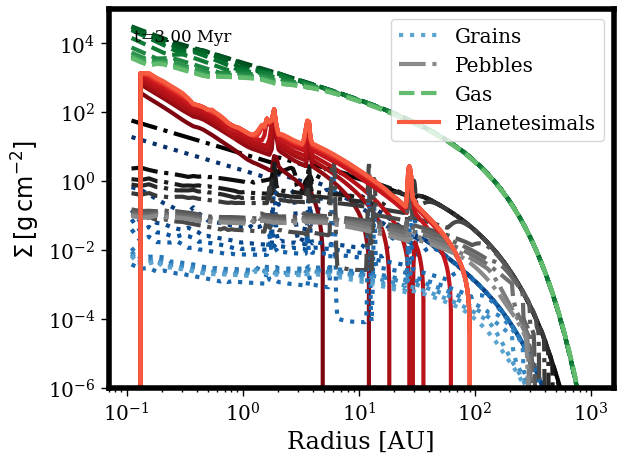

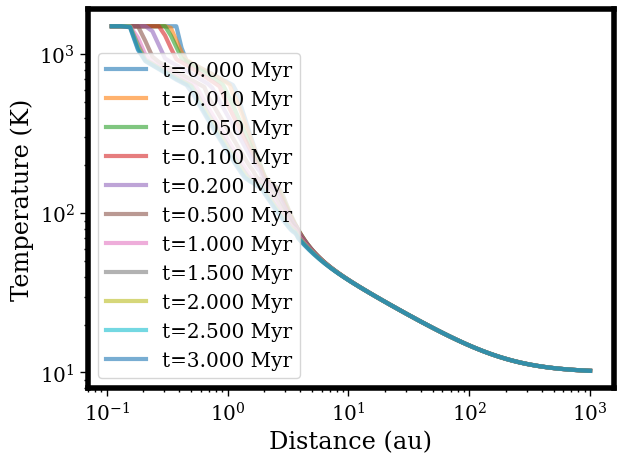

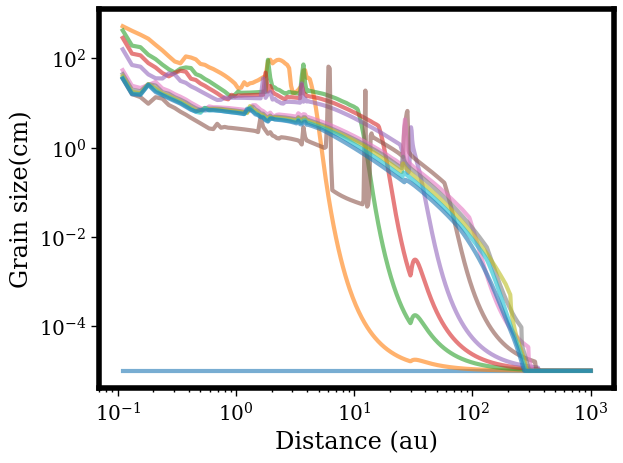

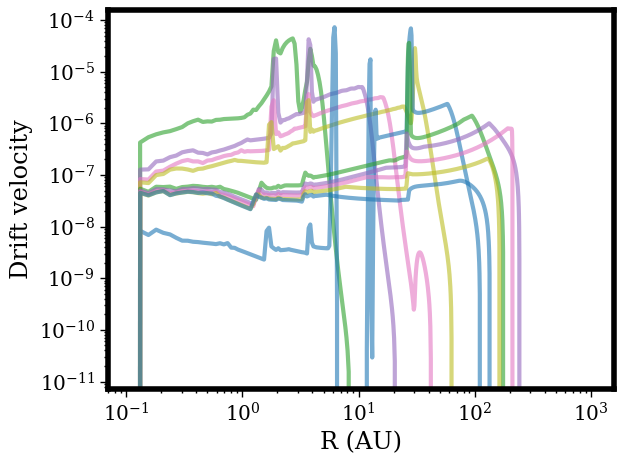

In [87]:
#file="winds_mig_psi0.01_Mdot3.0e-09_M1.0e-01_Rd5.0e+01.h5"
#file="winds_mig_psi0.01_Mdot1.0e-08_M1.5e-01_Rd2.0e+01.h5"
#file="winds_mig_psi0.01_Mdot3.0e-08_M1.0e-01_Rd1.0e+02.h5"
file="winds_mig_psi10.0_Mdot1.0e-08_M1.0e-01_Rd5.0e+01.h5"

sim_data = load_data(DATADIR+file)
snaps=np.array([0,3,4,5,6,7,8,9,10,11,12])
fig,ax=plot_Sigma(sim_data,snapnums=snaps,combinedust=False)
plt.show()
fig,ax=plot_T(sim_data,snapnums=snaps)
plt.show()
fig,ax=plot_a(sim_data,snapnums=snaps)
plt.show()
fig,ax=plot_v(sim_data,snapnums=snaps)
plt.show()

# MAIN PAPER FIGURES - Balogh et al. (2026)

## Initial conditions of all disks (Fig 1)

Saved to: /Users/mbalogh/projects/PlanetFormation/python/DiscEvolution/example/summer_2025/V3/Figs/alpha_total_vs_Mdot.png
Mdot bins used (M☉/Myr): ['0.0003', '0.001', '0.003', '0.01', '0.03', '0.1', '0.3', '1']
256
68
51


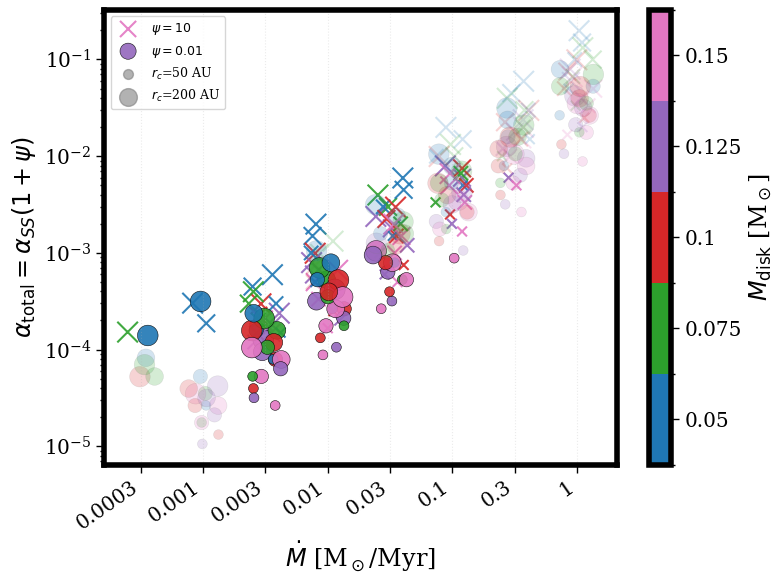

In [26]:
#===PLOT of alpha_total vs Mdot, color-coded by Mdisk, for all models===#
alpha_total = df['alpha_SS'] * (1. + df['psi'])


# Disk properties
Mdisk = _extract_column_first(df, ['Mdisk', 'disk_mass_t1e4']) / Msun
Rd = _extract_column_first(df, ['Rd', 'Rdisk', 'disk_radius'])

Mdot_raw = _extract_column_first(df, ['Mdot', 'disk_mdot_t1e4'])
Mdot = 1.0 * Mdot_raw * 1e6  # M☉/yr to M☉/Myr

# Force Mdisk to nearest allowed discrete value
mdisk_levels = np.array([0.05, 0.075, 0.1, 0.125, 0.15])
mdisk_idx = np.abs(Mdisk.to_numpy()[:, None] - mdisk_levels[None, :]).argmin(axis=1)
Mdisk_discrete = mdisk_levels[mdisk_idx]

# Discrete colormap (stepwise, 5 clearly distinct colors)
disk_colors = [plt.cm.tab10(i) for i in [0, 2, 3, 4, 6]]
cmap_disk = mpl.colors.ListedColormap(disk_colors)
bounds = np.concatenate((
    [mdisk_levels[0] - 0.0125],
    0.5 * (mdisk_levels[:-1] + mdisk_levels[1:]),
    [mdisk_levels[-1] + 0.0125]
))
norm_disk = mpl.colors.BoundaryNorm(bounds, cmap_disk.N)
# Bin Mdot robustly: snap to canonical bins (mantissa 0.3 or 1.0 per decade)
mdot_min = 0.0003  # M☉/Myr
mdot_max = 1.0     # M☉/Myr
mdot_vals = np.clip(Mdot.to_numpy(dtype=float), mdot_min, mdot_max)

# Generate all candidate snapped values in reasonable range
# e.g., 0.0003, 0.001, 0.003, 0.01, 0.03, 0.1, 0.3, 1.0
candidates_list = []
for n in range(-5, 2):  # adjust range if needed
    candidates_list.append(0.3 * (10.0 ** n))
    candidates_list.append(1.0 * (10.0 ** n))
candidates = np.sort(np.array(candidates_list))

# For each value, find the nearest candidate
mdot_snapped = np.zeros_like(mdot_vals)
for i, val in enumerate(mdot_vals):
    nearest_idx = np.argmin(np.abs(candidates - val))
    mdot_snapped[i] = candidates[nearest_idx]

mdot_snapped = np.clip(mdot_snapped, mdot_min, mdot_max)

mdot_levels = np.sort(np.unique(mdot_snapped))
mdot_bin_idx = np.searchsorted(mdot_levels, mdot_snapped).astype(float)

# Deterministic horizontal jitter within each Mdot bin
rng = np.random.default_rng(42)
x_plot = mdot_bin_idx + rng.uniform(-0.28, 0.28, size=len(mdot_bin_idx))

# Scale marker size with Rd
rd_vals = Rd.to_numpy(dtype=float)
if np.nanmax(rd_vals) > np.nanmin(rd_vals):
    size_vals = np.interp(rd_vals, (np.nanmin(rd_vals), np.nanmax(rd_vals)), (50, 220))
else:
    size_vals = np.full_like(rd_vals, 100.0)

# Plot
fig, ax = plt.subplots(figsize=(8, 6))
y = alpha_total
#####
# Identify simulations that formed at least one giant planet
has_giant = df_planets.groupby('file')['final_mass'].max() > giant_thresh
giant_sims = set(has_giant[has_giant].index)
# Create mask for which df rows have giants
df['has_giant'] = df['file'].isin(giant_sims)

#  Wind
select_wind_giant = (df['psi'] > 1) & df['has_giant']
select_wind_no_giant = (df['psi'] > 1) & ~df['has_giant']
ax.scatter(x_plot[select_wind_giant.to_numpy()], y[select_wind_giant].to_numpy(), 
          marker='x', cmap=cmap_disk, norm=norm_disk, c=Mdisk_discrete[select_wind_giant],
          s=size_vals[select_wind_giant],
          linewidths=1.5, alpha=0.9, label=r"$\psi=10$")

ax.scatter(x_plot[select_wind_no_giant.to_numpy()], y[select_wind_no_giant].to_numpy(),
          marker='x', cmap=cmap_disk, norm=norm_disk, c=Mdisk_discrete[select_wind_no_giant],
          s=size_vals[select_wind_no_giant],
          linewidths=1.5, alpha=0.2)

# viscous
select_visc_giant = (df['psi'] < 1) & df['has_giant']
select_visc_no_giant = (df['psi'] < 1) & ~df['has_giant']

ax.scatter(x_plot[select_visc_giant.to_numpy()], y[select_visc_giant].to_numpy(),
          marker='o', cmap=cmap_disk, norm=norm_disk, c=Mdisk_discrete[select_visc_giant],
          s=size_vals[select_visc_giant],
          edgecolors='k', linewidths=0.4, alpha=0.9, label=r"$\psi=0.01$")

ax.scatter(x_plot[select_visc_no_giant.to_numpy()], y[select_visc_no_giant].to_numpy(),
          marker='o', cmap=cmap_disk, norm=norm_disk, c=Mdisk_discrete[select_visc_no_giant],
          s=size_vals[select_visc_no_giant],
          edgecolors='gray', linewidths=0.4, alpha=0.2)
####
select = np.where(df['psi'] > 1)[0]

# Discrete colorbar for Mdisk bins
cbar = plt.colorbar(mpl.cm.ScalarMappable(norm=norm_disk, cmap=cmap_disk), ax=ax)
cbar.set_ticks(mdisk_levels)
cbar.set_ticklabels([f"{v:g}" for v in mdisk_levels])
cbar.set_label(r"$M_{\rm disk}$ [M$_\odot$]")

# X-axis shown as Mdot bins with one label per true bin
ax.set_xticks(np.arange(len(mdot_levels)))
ax.set_xticklabels([f"{val:g}" for val in mdot_levels], rotation=35, ha='right')
ax.set_xlabel(r"$\dot{M}$ [M$_\odot$/Myr]")

ax.set_yscale("log")
ax.set_ylabel(r"$\alpha_{\rm total} = \alpha_{SS}(1+\psi)$")
ax.grid(axis='x', alpha=0.25, linestyle=':')

# Legends: marker type + size guide
base_handles, base_labels = ax.get_legend_handles_labels()

if np.nanmax(rd_vals) > np.nanmin(rd_vals):
    rd_min, rd_mid, rd_max = np.nanmin(rd_vals), np.nanmedian(rd_vals), np.nanmax(rd_vals)
    size_legend_vals = np.interp([rd_min, rd_mid, rd_max], (rd_min, rd_max), (50, 220))
    #for s, rv in zip(size_legend_vals, [rd_min, rd_mid, rd_max]):
    for s, rv in zip(size_legend_vals, [rd_min, rd_max]):
        ax.scatter([], [], s=s, c='gray', alpha=0.6, label=f"$r_c$={rv:g} AU")

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, loc='best', fontsize=9)

outname = os.path.join(FIGDIR, "alpha_total_vs_Mdot.png")
fig.savefig(outname, dpi=300, bbox_inches='tight')
print("Saved to:", outname)
print("Mdot bins used (M☉/Myr):", [f"{v:g}" for v in mdot_levels])
print (len(df))
print (len(select_wind_giant[select_wind_giant]))
print (len(select_visc_giant[select_visc_giant]))

## Global disk evolution figures

### Accretion rate and disk mass vs time (Figs 2a, b)

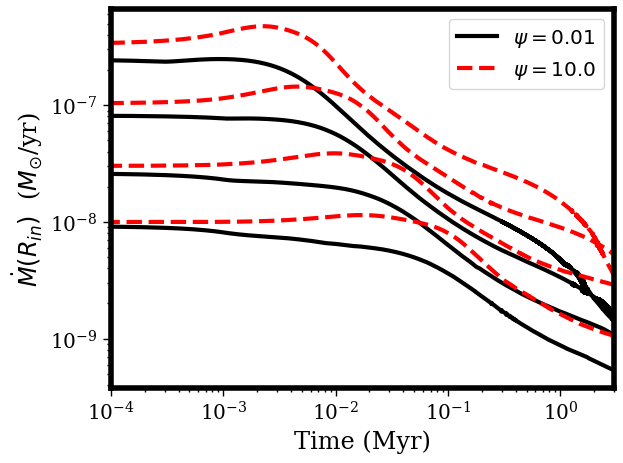

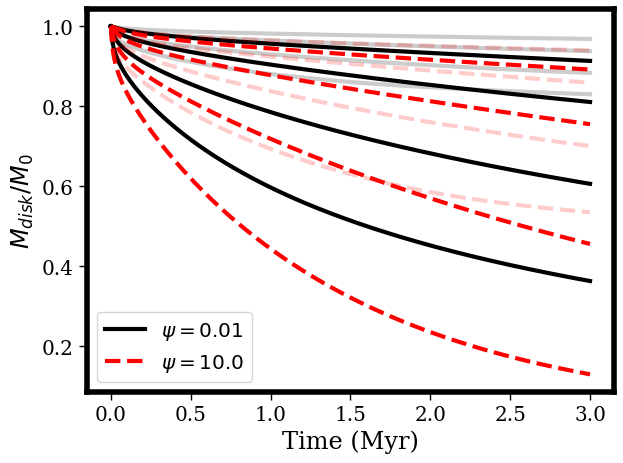

In [12]:
viscous_files=("winds_mig_psi0.01_Mdot1.0e-08_M1.0e-01_Rd5.0e+01.h5",
       "winds_mig_psi0.01_Mdot3.0e-08_M1.0e-01_Rd5.0e+01.h5",
       "winds_mig_psi0.01_Mdot1.0e-07_M1.0e-01_Rd5.0e+01.h5",
       "winds_mig_psi0.01_Mdot3.0e-07_M1.0e-01_Rd5.0e+01.h5")
wind_files=("winds_mig_psi10.0_Mdot1.0e-08_M1.0e-01_Rd5.0e+01.h5",
       "winds_mig_psi10.0_Mdot3.0e-08_M1.0e-01_Rd5.0e+01.h5",
       "winds_mig_psi10.0_Mdot1.0e-07_M1.0e-01_Rd5.0e+01.h5",
       "winds_mig_psi10.0_Mdot3.0e-07_M1.0e-01_Rd5.0e+01.h5")

fig1, ax1 = plt.subplots()
fig2, ax2 = plt.subplots()
for i, file in enumerate(viscous_files):
    try:
        sim_data = load_data(DATADIR+file)
        t = np.array(sim_data["t"])              # years
        tMyr = np.array(sim_data["t"])/1.e6              # Myr
        disk_Mass        = sim_data["disk_Mass"]
        Minit=disk_Mass[0]/Msun
        Mdot   = sim_data["disk_Mdot_star"]
        Mdot_smooth = uniform_filter1d(Mdot, size=51, mode="nearest")
        disk_Mass_predict=disk_Mass[0]+Mdot[1:]*(t[1:]-t[:-1])
        #dM=(np.cumsum(Mdot[1:] * np.diff(t)))
        #print (Mdot[-5:-1],np.diff(t)[-5:-1],dM[-5:-1])
        disk_Mass_predict = np.concatenate(([disk_Mass[0]/Msun], disk_Mass[0]/Msun - np.cumsum(Mdot[1:] * np.diff(t))))
        ax1.loglog(tMyr,Mdot_smooth,c='k',label='$\psi=0.01$' if i == 0 else '_nolegend_')
        ax2.plot(tMyr,np.array(disk_Mass)/Msun/Minit,c='k',label='$\psi=0.01$'if i == 0 else '_nolegend_')
        ax2.plot(tMyr,np.array(disk_Mass_predict)/Minit,c='k',alpha=0.2)
    except Exception as e:
        print(f"Error loading {file}: {e}")
for i, file in enumerate(wind_files):
    try:
        sim_data = load_data(DATADIR+file)
        t = np.array(sim_data["t"])              # years
        tMyr = np.array(sim_data["t"])/1.e6              # Myr
        Mdot   = sim_data["disk_Mdot_star"]
        Mdot_smooth = uniform_filter1d(Mdot, size=51, mode="nearest")
        disk_Mass        = sim_data["disk_Mass"]
        disk_Mass_predict = np.concatenate(([disk_Mass[0]/Msun], disk_Mass[0]/Msun - np.cumsum(Mdot[1:] * np.diff(t))))
        ax1.loglog(tMyr,Mdot_smooth,linestyle='--',c='r',label='$\psi=10.0$' if i == 0 else '_nolegend_')
        ax2.plot(tMyr,np.array(disk_Mass)/Msun/Minit,linestyle='--',c='r',label='$\psi=10.0$' if i == 0 else '_nolegend_')
        ax2.plot(tMyr,np.array(disk_Mass_predict)/Minit,c='r',alpha=0.2,linestyle='--')
    except Exception as e:
        print(f"Error loading {file}: {e}")

ax1.set_xlabel('Time (Myr)')
ax1.set_ylabel('$\dot{M}(R_{in})$  ($M_⊙$/yr)')
ax1.set_xlim(1.e-4, 3.)
ax2.set_xlabel('Time (Myr)')
ax2.set_ylabel('$M_{disk}/M_0$')
ax2.legend()
ax1.legend()
fig1.savefig(FIGDIR+"Mdot_evolution.png", dpi=300)
fig2.savefig(FIGDIR+"Mdisk_evolution.png", dpi=300)

# ax2.set_yticks([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0])
# ax2.yaxis.set_major_formatter(ticker.FuncFormatter(
#     lambda y, _: f'{y:.1f}' if y in (0.1, 0.5, 1.0) else ''
# ))


### Pebble and planetesimal mass evolution (Fig 2c)

3.0 6.967117634166366 173.5125785088108
3.0 15.011338919386361 208.51387430372773


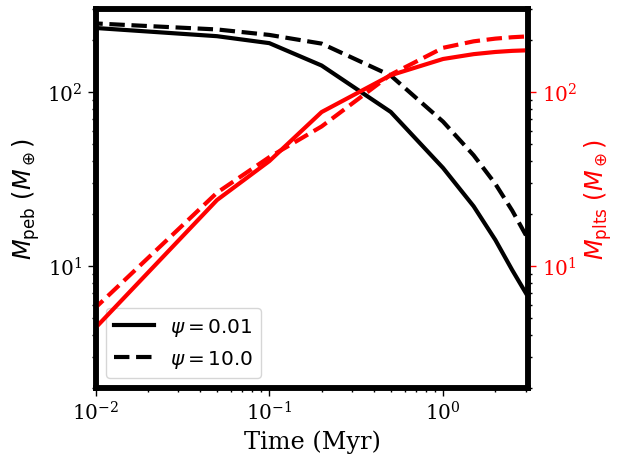

In [24]:
# Pebbles (left axis) + Planetesimals (right axis), single viscous + wind file each
single_viscous = "winds_mig_psi0.01_Mdot1.0e-08_M1.0e-01_Rd5.0e+01.h5"
single_wind    = "winds_mig_psi10.0_Mdot1.0e-08_M1.0e-01_Rd5.0e+01.h5"

fig, ax_peb = plt.subplots()
ax_pln = ax_peb.twinx()

for file, color, ls, label in [
    (single_viscous, "k", "-",  r"$\psi=0.01$"),
    (single_wind,    "r", "--", r"$\psi=10.0$"),
]:
    try:
        sim_data = load_data(DATADIR + file)
        t = np.asarray(sim_data["time_snap"], dtype=float)

        M_peb = integrate_surface_density_mass(sim_data, "Sigma_pebbles")
        M_pln = integrate_surface_density_mass(sim_data, "Sigma_planetesimals")

        n = min(len(t), len(M_peb), len(M_pln))
        t     = t[:n]
        M_peb = M_peb[:n]
        M_pln = M_pln[:n]
        print (t[-1],M_peb[-1]/Mearth,M_pln[-1]/Mearth)

        ax_peb.loglog(t, M_peb / Mearth, c='k', linestyle=ls,       label=label)
        ax_pln.loglog(t, M_pln / Mearth, c='r', linestyle=ls)

    except Exception as e:
        print(f"Error loading {file}: {e}")

ax_peb.set_xlabel("Time (Myr)")
ax_peb.set_ylabel(r"$M_{\rm peb}\ (M_\oplus)$")
ax_pln.set_ylabel(r"$M_{\rm plts}\ (M_\oplus)$")
ax_peb.set_xlim(1.0e-2, 3.1)
ax_peb.set_ylim(2, 300)
ax_pln.set_ylim(2, 300)
ax_peb.legend(loc="lower left")

ax_pln.yaxis.label.set_color("red")
ax_pln.tick_params(axis="y", colors="red")

fig.tight_layout()
fig.savefig(FIGDIR + "Mpebble_Mplanetesimal_combined.png", dpi=300)

### Wind mass loss rate vs accretion rate (Fig 3)

Viscous files: 6
Wind files:    6
Example viscous: winds_mig_psi0.01_Mdot1.0e-09_M1.0e-01_Rd5.0e+01.h5
Example wind:    winds_mig_psi10.0_Mdot1.0e-09_M1.0e-01_Rd5.0e+01.h5
Error loading winds_mig_psi10.0_Mdot1.0e-09_M1.0e-01_Rd5.0e+01.h5 for wind-loss plot: [Errno 2] Unable to open file (unable to open file: name = '/Users/mbalogh/projects/PlanetFormation/python/output/HJpaper/V3/winds_mig_psi10.0_Mdot1.0e-09_M1.0e-01_Rd5.0e+01.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)
Error loading winds_mig_psi10.0_Mdot3.0e-09_M1.0e-01_Rd5.0e+01.h5 for wind-loss plot: [Errno 2] Unable to open file (unable to open file: name = '/Users/mbalogh/projects/PlanetFormation/python/output/HJpaper/V3/winds_mig_psi10.0_Mdot3.0e-09_M1.0e-01_Rd5.0e+01.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)
Matched rows used for plotting: 30
Only in table1 after aliasing: ['HD 142666', 'HD 143006', 'HD 163296', 'MWC 480']
Only in table4 after 

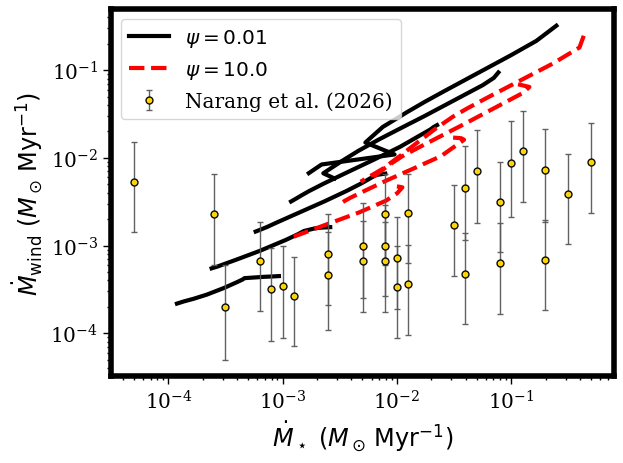

In [23]:

# Choose parameter grids in normal numeric format
MDOT_VALUES = [1e-9, 3e-9, 1e-8, 3e-8, 1e-7, 3e-7]
M_VALUES    = [0.1]
RD_VALUES   = [50]   
viscous_files, wind_files = build_file_lists(
    MDOT_VALUES,
    M_VALUES,
    RD_VALUES,
    datadir=DATADIR,
    keep_only_existing=False,   # set True if you want to auto-drop missing files
)

print(f"Viscous files: {len(viscous_files)}")
print(f"Wind files:    {len(wind_files)}")
print("Example viscous:", viscous_files[0] if viscous_files else "none")
print("Example wind:   ", wind_files[0] if wind_files else "none")
fig_windloss, ax_windloss = plot_windloss_vs_mdot_star()

# File paths
t1_path = LITDATA+"Narang/table1_disk_sample.csv"
t4_path = LITDATA+"Narang/table4_wind_properties.csv"

# Load tables
df1 = pd.read_csv(t1_path)
df4 = pd.read_csv(t4_path)

# Resolve known naming mismatch(s)
name_map_t4_to_t1 = {
    "AS 205": "AS 205 N",
}
df4["Target_match"] = df4["Disk"].replace(name_map_t4_to_t1)

# Merge wind table with accretion table
df_obs = df4.merge(
    df1[["Target", "log10_Mdot_acc_Msun_per_yr"]],
    left_on="Target_match",
    right_on="Target",
    how="inner"
)

# Matching diagnostics
common = set(df_obs["Target_match"])
only_t1 = sorted(set(df1["Target"]) - common)
only_t4 = sorted(set(df4["Disk"]) - set(name_map_t4_to_t1.keys()) - set(df1["Target"]))
print(f"Matched rows used for plotting: {len(df_obs)}")
print("Only in table1 after aliasing:", only_t1)
print("Only in table4 after aliasing:", only_t4)

# Convert from log10(Msun/yr) to linear
x_log = df_obs["log10_Mdot_acc_Msun_per_yr"].astype(float).to_numpy()
y_log = df_obs["log10_Mdot_wind_tot_Msun_per_yr"].astype(float).to_numpy()
y_err_up_dex = df_obs["log10_Mdot_wind_tot_err_upper"].astype(float).to_numpy()
y_err_lo_dex = df_obs["log10_Mdot_wind_tot_err_lower"].astype(float).to_numpy()

x = 10.0**x_log
y = 10.0**y_log

# Asymmetric y-errors in linear space
y_hi = 10.0**(y_log + y_err_up_dex)
y_lo = 10.0**(y_log - y_err_lo_dex)
yerr = np.vstack([y - y_lo, y_hi - y])

# Overlay on existing wind-loss axis if it exists
if "ax_windloss" in globals():
    ax = ax_windloss
else:
    ax = plt.gca()

ax.errorbar(
    x*1.e6, y*1.e6,
    yerr=yerr*1.e6,
    fmt="o",
    ms=5,
    mfc="gold",
    mec="black",
    ecolor="0.35",
    elinewidth=1.0,
    capsize=2.5,
    alpha=0.95,
    label="Narang et al. (2026)"
)

ax.legend()

# Save updated figure if existing figure object is present
if "fig_windloss" in globals():
    fig_windloss.savefig(FIGDIR + "Mdot_wind_vs_Mdot_star_with_Narang.png", dpi=300)



### Disk profile evolution

Saved /Users/mbalogh/projects/PlanetFormation/python/DiscEvolution/example/summer_2025/V3/Figs/sigmaT_comparison_M0.10_Rd50.png
Saved /Users/mbalogh/projects/PlanetFormation/python/DiscEvolution/example/summer_2025/V3/Figs/chem_comparison_M0.10_Rd50.png
Saved /Users/mbalogh/projects/PlanetFormation/python/DiscEvolution/example/summer_2025/V3/Figs/dustprop2_comparison_M0.10_Rd50.png
Saved /Users/mbalogh/projects/PlanetFormation/python/DiscEvolution/example/summer_2025/V3/Figs/dust_comparison_M0.10_Rd50.png
Saved /Users/mbalogh/projects/PlanetFormation/python/DiscEvolution/example/summer_2025/V3/Figs/CHOH_comparison_M0.10_Rd50.png


(<Figure size 1200x1000 with 4 Axes>,
 array([[<AxesSubplot: title={'center': '$\\psi$=0.01'}, ylabel='$C/H_{\\rm gas}$ [$Z_\\odot$]'>,
         <AxesSubplot: title={'center': '$\\psi$=10'}, ylabel='$C/H_{\\rm gas}$ [$Z_\\odot$]'>],
        [<AxesSubplot: xlabel='Distance [AU]', ylabel='$O/H_{\\rm gas}$ [$Z_\\odot$]'>,
         <AxesSubplot: xlabel='Distance [AU]', ylabel='$O/H_{\\rm gas}$ [$Z_\\odot$]'>]],
       dtype=object))

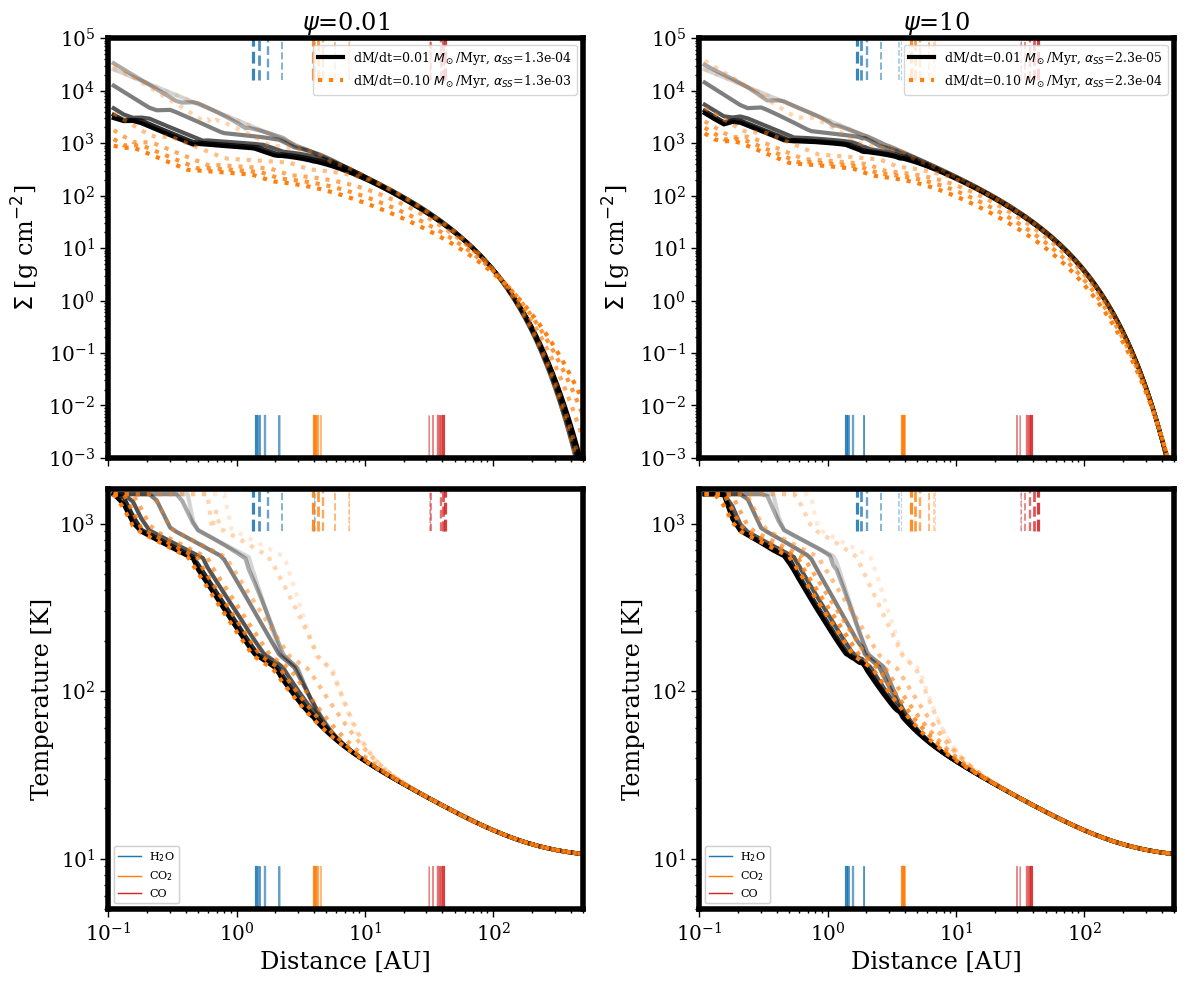

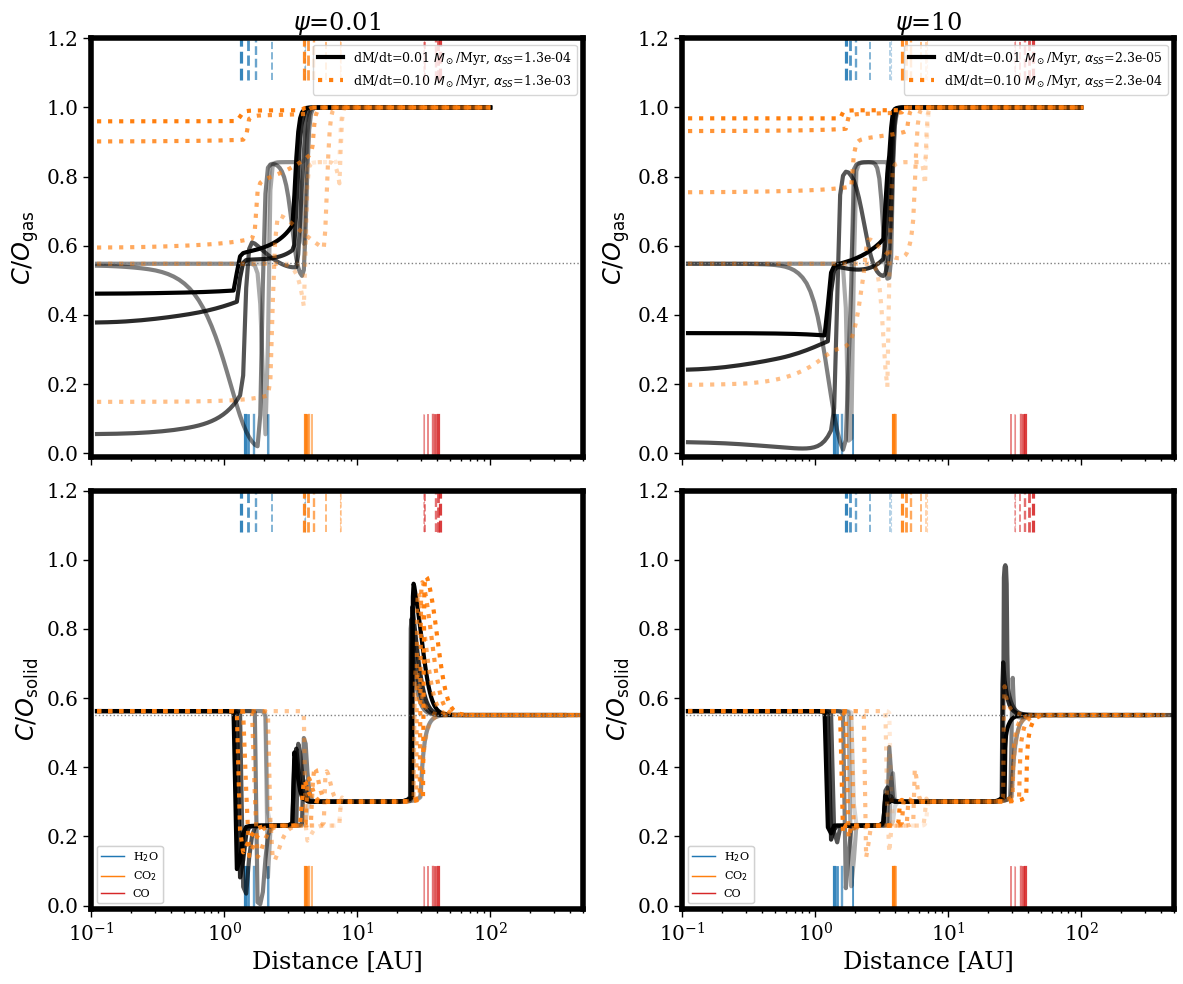

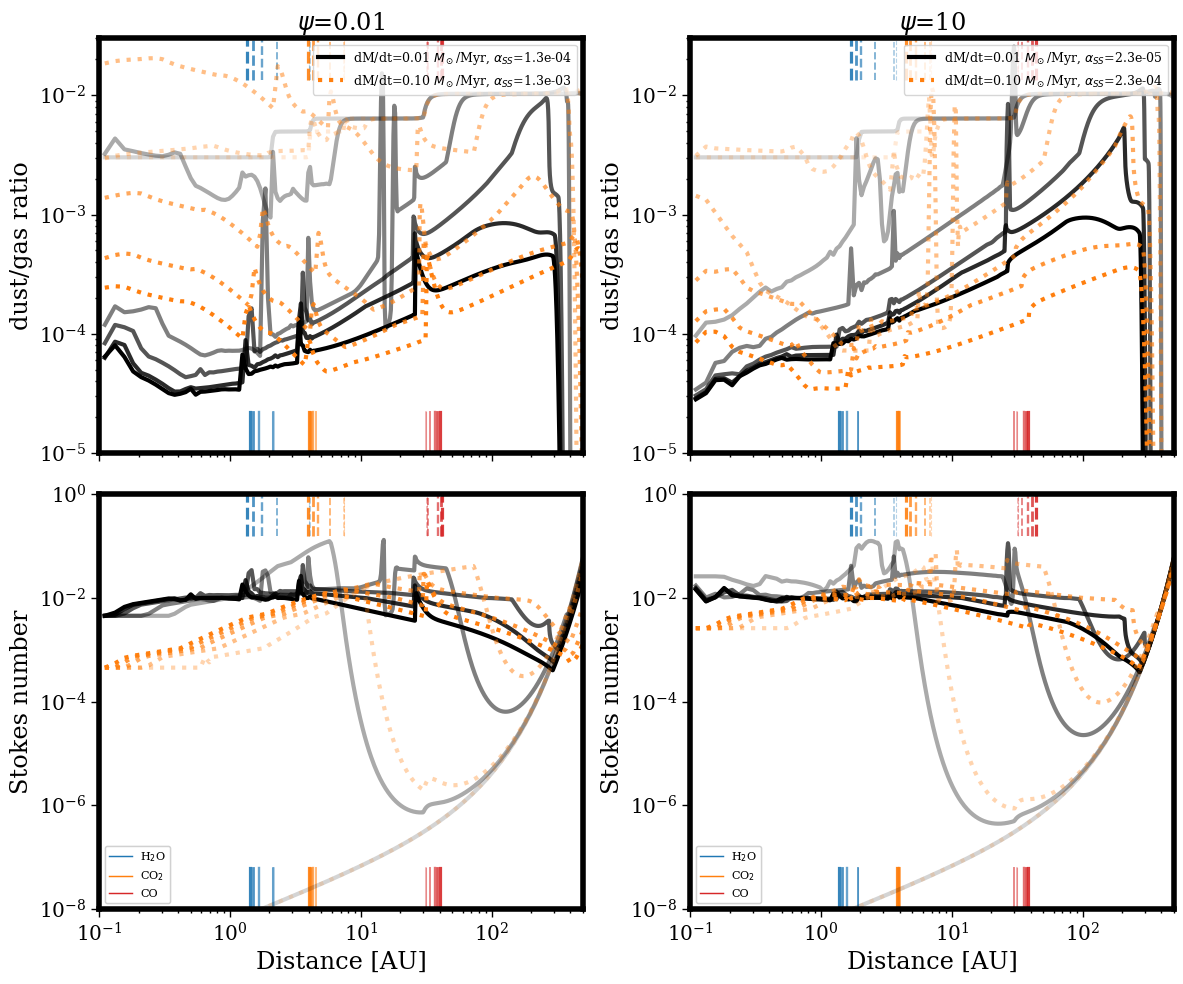

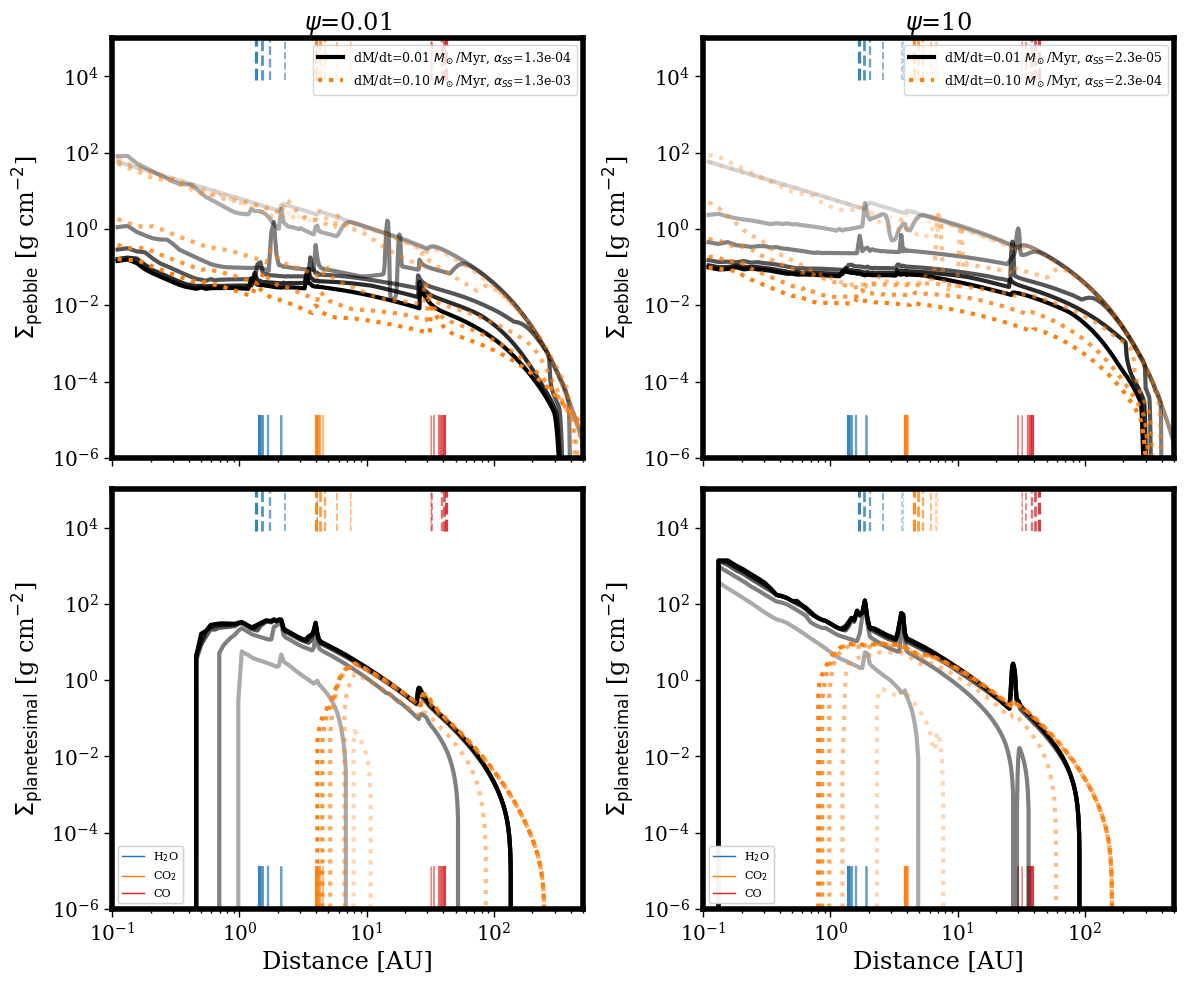

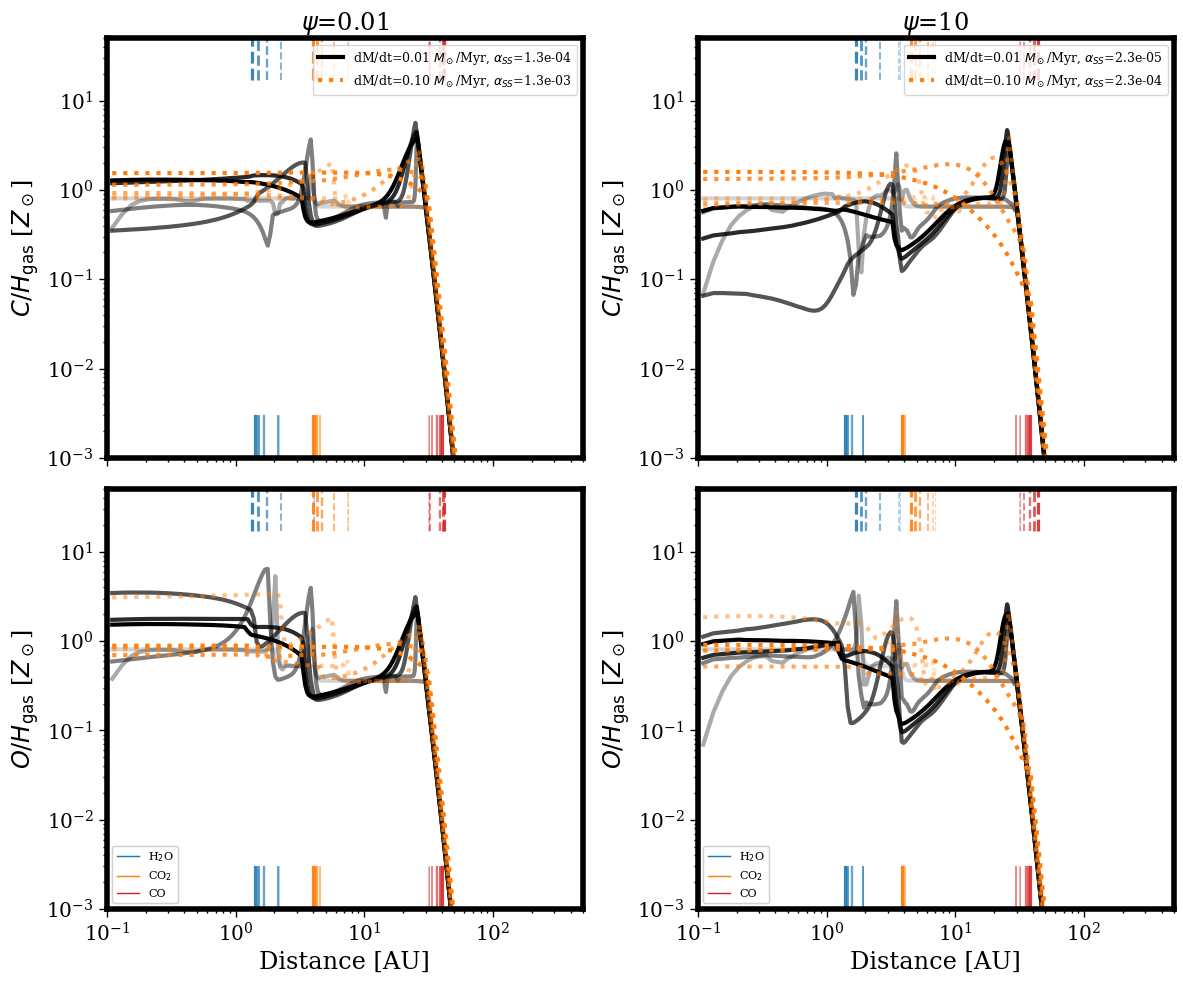

In [16]:
mdots=(1e-8, 1e-7)
times=[0.0, 0.01,0.2, 1,2,3]
M=0.1
Rd=50
# Sigma and T (Fig 4)
plot_disk_comparison("sigmaT",    DATADIR, M=M, Rd=Rd, mdots=mdots,
                     psis=(0.01,10), times=times,planets=True,figdir=FIGDIR,plot_ice_lines=True,ice_line_indices=ice_line_indices)
# C/O gas and solid (Fig 5)
plot_disk_comparison("chem",      DATADIR, M=M, Rd=Rd, mdots=mdots,
                     psis=(0.01,10), times=times,planets=True,figdir=FIGDIR,plot_ice_lines=True,ice_line_indices=ice_line_indices)
# dust/gas ratio and Stokes (Fig 13)
plot_disk_comparison("dustprop2",  DATADIR, M=M, Rd=Rd, mdots=mdots,
                     psis=(0.01,10), times=times,planets=True,figdir=FIGDIR,plot_ice_lines=True,ice_line_indices=ice_line_indices)
# Pebble and planetesimal (Fig 14)
plot_disk_comparison("dust",      DATADIR, M=M, Rd=Rd, mdots=mdots,
                      psis=(0.01,10), times=times,planets=True,figdir=FIGDIR,plot_ice_lines=True,ice_line_indices=ice_line_indices)
# gas phase C/H and O/H (Fig 15)
plot_disk_comparison("CHOH",      DATADIR, M=M, Rd=Rd, mdots=mdots,
                     psis=(0.01,10), times=times,planets=True,figdir=FIGDIR,plot_ice_lines=True,ice_line_indices=ice_line_indices)


### Planet evolution tracks

/Users/mbalogh/projects/PlanetFormation/python/DiscEvolution/example/summer_2025/V3/Figs/


/var/folders/nm/mkv23rl56kl_6krs900_0npc0000gn/T/ipykernel_14787/3265904594.py:823: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/var/folders/nm/mkv23rl56kl_6krs900_0npc0000gn/T/ipykernel_14787/3265904594.py:828: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.savefig(outname, dpi=300, bbox_inches='tight')


✅ Saved: /Users/mbalogh/projects/PlanetFormation/python/DiscEvolution/example/summer_2025/V3/Figs/winds_mig_psi10_noplan_vs_with_tracks.png


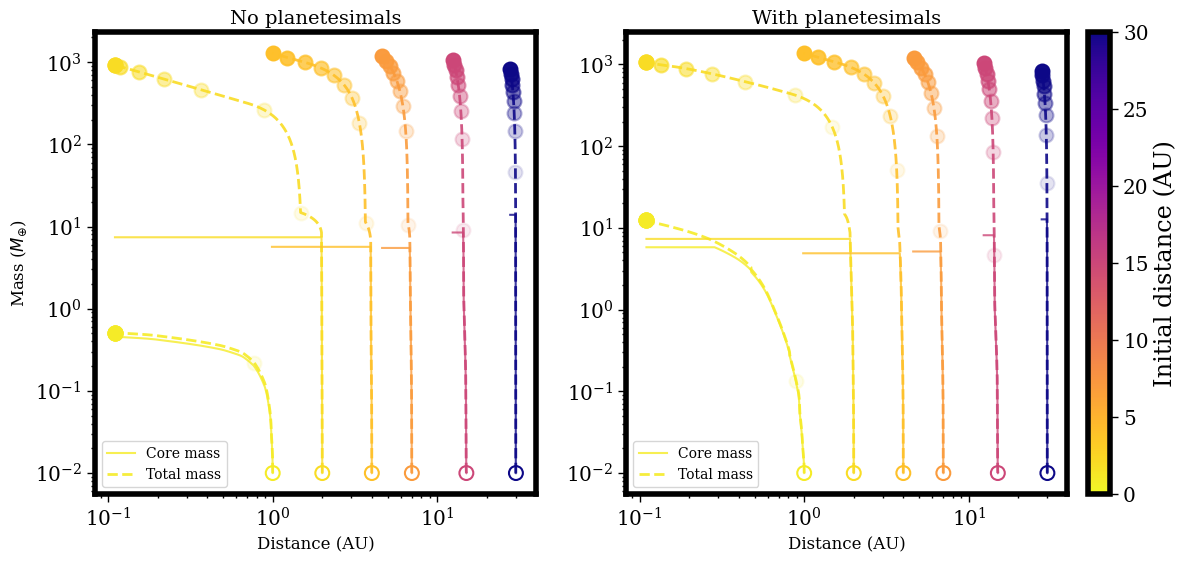

✅ Saved: /Users/mbalogh/projects/PlanetFormation/python/DiscEvolution/example/summer_2025/V3/Figs/winds_mig_psi0.01_noplan_vs_with_tracks.png


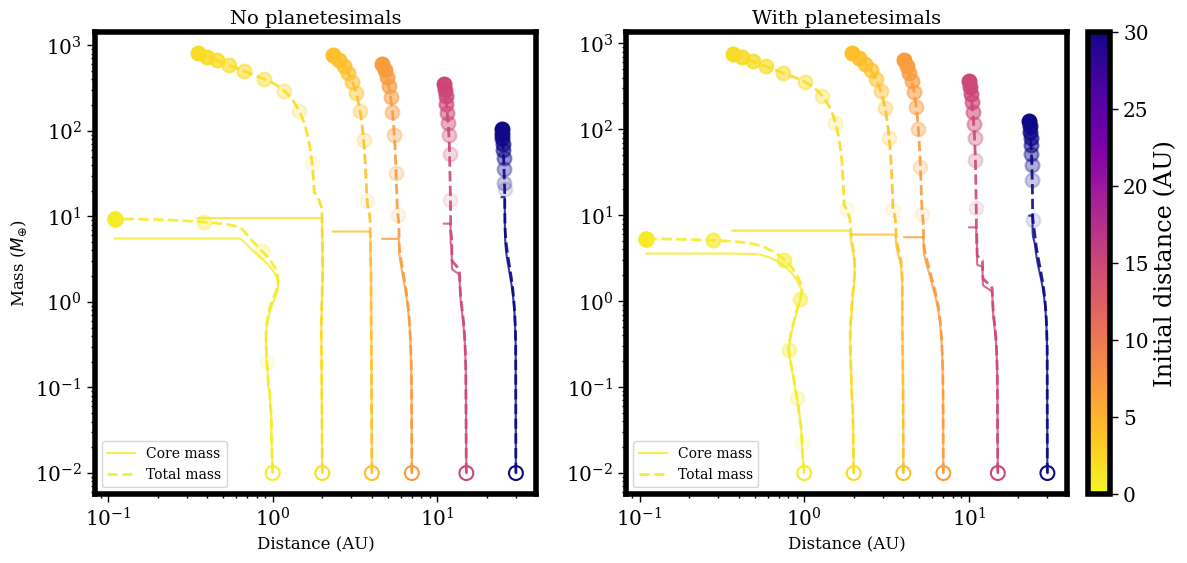

/Users/mbalogh/projects/PlanetFormation/python/output/HJpaper/V3/winds_mig_psi10.0_Mdot1.0e-08_M1.0e-01_Rd5.0e+01.h5 /Users/mbalogh/projects/PlanetFormation/python/output/HJpaper/V3/winds_mig_psi0.01_Mdot1.0e-08_M1.0e-01_Rd5.0e+01.h5
2.2686577973404914e-05 0.00013091562556183397
✅ Saved figure to /Users/mbalogh/projects/PlanetFormation/python/DiscEvolution/example/summer_2025/V3/Figs/winds_mig_psi10-0.01_Mdot1e-08_M1e-01_Rd50_Total_mass_M_vs_Distance_AU.png


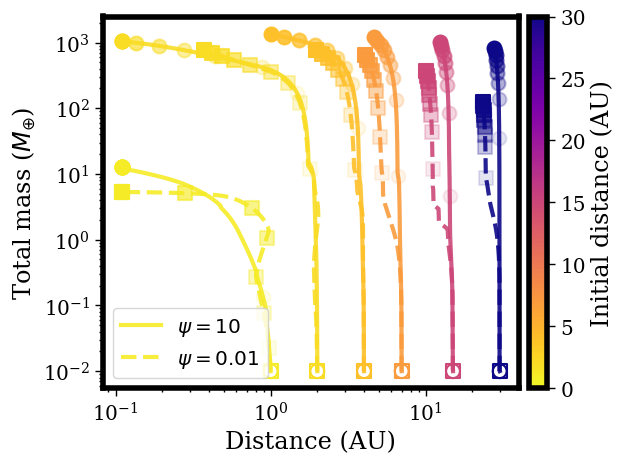

Adding solar C/O reference line at 0.55
✅ Saved figure to /Users/mbalogh/projects/PlanetFormation/python/DiscEvolution/example/summer_2025/V3/Figs/winds_mig_psi10-0.01_Mdot1e-08_M1e-01_Rd50_C_O_envelope_vs_Distance_AU_envelope.png


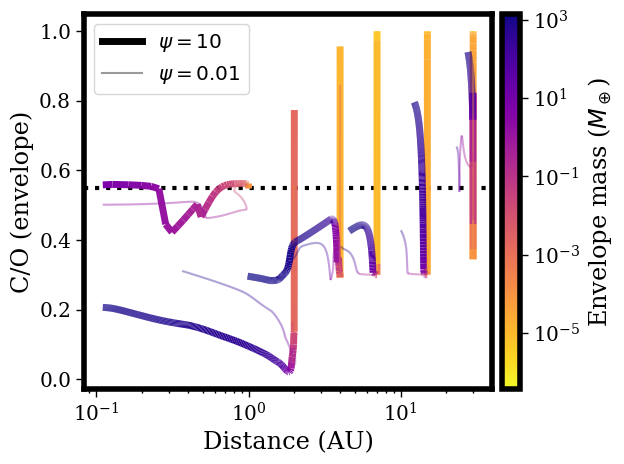

Adding solar C/O reference line at 0.55
✅ Saved figure to /Users/mbalogh/projects/PlanetFormation/python/DiscEvolution/example/summer_2025/V3/Figs/noplan/noplan_winds_mig_psi10-0.01_Mdot1e-08_M1e-01_Rd50_C_O_envelope_vs_Distance_AU_envelope.png


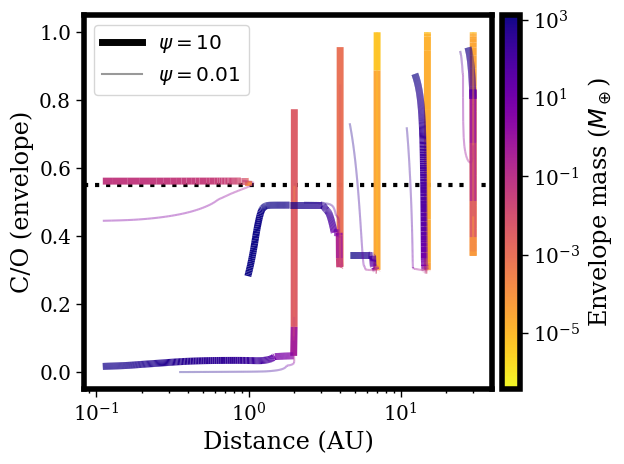

(<Figure size 640x480 with 2 Axes>,
 <AxesSubplot: xlabel='Distance (AU)', ylabel='C/O (envelope)'>)

In [22]:
# ==== COMPARISON PLOTS ====
header="winds_mig"
psicompare=(10, 0.01)
Mdotcompare=(1.0e-8, 1.0e-8)
Mdiskcompare=(0.1, 0.1)
Rdcompare=(50, 50)
planets=(0, 1, 3, 5, 7, 10)
print (FIGDIR)

# Core mass + envelope mass vs time for planetesimal runs
# Wind model (Fig 16)
compare_planetesimals(
    outdir=DATADIR,
    psi=10,
    mdot=1.0e-8,
    mdisk=0.1,
    rd=50,
    planets=[0, 1, 3, 5, 7, 10],
    figdir=FIGDIR,
    header="winds_mig",
    model_name="winds"
)
# Core mass + envelope mass vs time for planetesimal runs
# Viscous model (Fig not included in paper)
compare_planetesimals(
    outdir=DATADIR,
    psi=0.01,
    mdot=1.0e-8,
    mdisk=0.1,
    rd=50,
    planets=[0, 1, 3, 5, 7, 10],
    figdir=FIGDIR,
    header="winds_mig",
    model_name="winds"
)
# Compare wind and viscous model total mass growth tracks (Fig 6)
compare_models_onepanel(
    DATADIR,
    psicompare,
    Mdotcompare,
    Mdiskcompare,
    Rdcompare,
    planets=planets,
    xkey="Rp",
    ykey=lambda d,i: np.array(d["Mcs"][i]) + np.array(d["Mes"][i]),
    xlabel="Distance (AU)",
    ylabel="Total mass ($M_⊕$)",
    labels=("$\psi=10$","$\psi=0.01$"),
    figdir=FIGDIR,
    header=header,
    time_marker_interval=0.33
)
# Compare wind and viscous model envelope C/O vs distance (Fig 7a)
compare_models(
    outdir=DATADIR,
    Psi=psicompare,
    Mdot=Mdotcompare,
    Mdisk=Mdiskcompare,
    Rd=Rdcompare,
    planets=planets,
    #planets=(3, 7),
    #xkey="Rp",
    xkey="Rp",
    ykey=lambda d,i: (d["ratios"] if "ratios" in d else compute_abundance_ratios(d, by_number=True, scaled_to_solar=False))["C/O_env"][i],
    xlabel="Distance (AU)",
    #xlabel="Envelope mass ($M_⊕$)",
    ylabel="C/O (envelope)",
    labels=("$\psi=10$","$\psi=0.01$"),
    logy=False,
    logx=True,
    figdir=FIGDIR,
    header=header,
    time_marker_interval=0.33,
    color_by="envelope",
    show_time_markers=False,
    draw_solarCO=True)
# As previous but for no-planetesimal runs (Fig 7b)
compare_models(
    outdir=DATADIR,
    Psi=psicompare,
    Mdot=Mdotcompare,
    Mdisk=Mdiskcompare,
    Rd=Rdcompare,
    planets=planets,
    #planets=(3, 7),
    #xkey="Rp",
    xkey="Rp",
    ykey=lambda d,i: (d["ratios"] if "ratios" in d else compute_abundance_ratios(d, by_number=True, scaled_to_solar=False))["C/O_env"][i],
    xlabel="Distance (AU)",
    #xlabel="Envelope mass ($M_⊕$)",
    ylabel="C/O (envelope)",
    labels=("$\psi=10$","$\psi=0.01$"),
    logy=False,
    logx=True,
    figdir=FIGDIR,
    header="noplan/noplan_winds_mig",
    time_marker_interval=0.33,
    color_by="envelope",
    show_time_markers=False,
    draw_solarCO=True)


## Population plots

### Final Mass-distance plots for all planets (Fig 8)

/var/folders/nm/mkv23rl56kl_6krs900_0npc0000gn/T/ipykernel_13882/2259950770.py:70: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


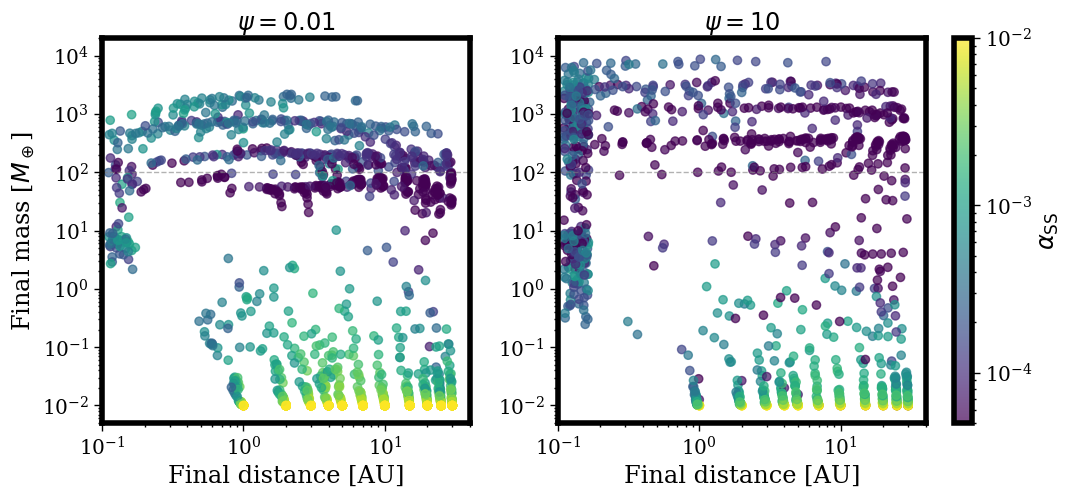

/var/folders/nm/mkv23rl56kl_6krs900_0npc0000gn/T/ipykernel_13882/2259950770.py:74: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.savefig(outname, dpi=300, bbox_inches="tight")


Saved to: /Users/mbalogh/projects/PlanetFormation/python/DiscEvolution/example/summer_2025/V3/Figs/final_M_a.png


In [25]:
# Plot final mass and radius of all planets formed in simulation
# 2 panel plot with psi=0.01 on the left and psi=10 on the right.
# --- Extract planet-level data ---
xs   = df_planets["final_r"].to_numpy()        # final radius (AU)
ys   = df_planets["final_mass"].to_numpy()     # final mass (Mearth)
psis = df_planets["psi"].to_numpy()            # psi per planet
alphas = df_planets["alpha_SS"].to_numpy()     # α_SS per planet

# Color scale: α_total = α_SS (1 + ψ)
#cs = alphas * (1.0 + psis)
cs = alphas 

alphamin = 1e-5

# --- Avoid overplotting near minimum r ---
min_x = xs.min()
xs = xs.copy()
xs += np.random.uniform(0, 5e-1 * min_x, size=xs.shape) * (xs <= 1.01 * min_x)

# --- Masks ---
mask_low  = (psis < 1)  & (cs > alphamin)
mask_high = (psis >= 1) & (cs > alphamin)

# --- Plot: two side-by-side panels with a dedicated colorbar column ---
fig = plt.figure(figsize=(12, 5))
gs = fig.add_gridspec(1, 3, width_ratios=[1, 1, 0.05], wspace=0.35)
ax_left  = fig.add_subplot(gs[0, 0])
ax_right = fig.add_subplot(gs[0, 1], sharex=ax_left, sharey=ax_left)
cax      = fig.add_subplot(gs[0, 2])  # reserved solely for colorbar

# Move the colorbar axis closer to the right panel
pos = cax.get_position()
cax.set_position([pos.x0 - 0.05, pos.y0, pos.width, pos.height])

#norm = LogNorm(vmin=alphamin, vmax=cs.max())
norm = LogNorm(vmin=5.e-5, vmax=1.e-2)
cmap = "viridis"

# Left: psi = 0.01
sc1 = ax_left.scatter(xs[mask_low], ys[mask_low], c=cs[mask_low], cmap=cmap,
                      norm=norm, alpha=0.7, marker="o")
ax_left.set_title(r"$\psi = 0.01$")

# Right: psi = 10
ax_right.scatter(xs[mask_high], ys[mask_high], c=cs[mask_high], cmap=cmap,
                 norm=norm, alpha=0.7, marker="o")
ax_right.set_title(r"$\psi = 10$")

xmin, xmax = 1e-1, 40  # Adjust to your data range
ymin = giant_thresh
ymax = 2e4  # Adjust to your data range
for i, ax in enumerate([ax_left, ax_right]):
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Final distance [AU]")
    if i == 0:
        ax.set_ylabel("Final mass [$M_\oplus$]")
    else:
        ax.set_ylabel("")
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(0.005, ymax)
# --- Add shaded regions for IJ and OJ ---
for ax in [ax_left, ax_right]:
    ax.axhline(100, color="grey", lw=1, ls="--", alpha=0.6)
# Colorbar in its own column (guaranteed outside panels)
cbar = fig.colorbar(sc1, cax=cax)
#cbar.set_label(r"$\alpha_{\rm total} = \alpha_{\rm SS}(1+\psi)$")
cbar.set_label(r"$\alpha_{\rm SS}$")

fig.tight_layout()
plt.show()

outname = os.path.join(FIGDIR, "final_M_a.png")
fig.savefig(outname, dpi=300, bbox_inches="tight")
print("Saved to:", outname)

### Final envelope composition plots 

/var/folders/nm/mkv23rl56kl_6krs900_0npc0000gn/T/ipykernel_13882/723046321.py:1428: UserWarning: FixedFormatter should only be used together with FixedLocator
  cbar.set_ticklabels(cbar_labels)
/var/folders/nm/mkv23rl56kl_6krs900_0npc0000gn/T/ipykernel_13882/723046321.py:1467: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  ax.figure.canvas.draw_idle()
/var/folders/nm/mkv23rl56kl_6krs900_0npc0000gn/T/ipykernel_13882/723046321.py:1499: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 0.95])
/var/folders/nm/mkv23rl56kl_6krs900_0npc0000gn/T/ipykernel_13882/2861146238.py:48: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.savefig(os.path.join(FIGDIR, "Mass_vs_total_metal_mass_Thorngren.png"), dpi=300, bbox_inches='tight')
/var/folders/nm/mkv23rl56kl_6krs900_

C/H: total=66 (direct=26, derived_from_(O+C)/H=24, derived_from_C/O=16)


/var/folders/nm/mkv23rl56kl_6krs900_0npc0000gn/T/ipykernel_13882/2861146238.py:66: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.savefig(os.path.join(FIGDIR, "CH_vs_MASS_chachan.png"), dpi=300, bbox_inches='tight')
/var/folders/nm/mkv23rl56kl_6krs900_0npc0000gn/T/ipykernel_13882/723046321.py:1428: UserWarning: FixedFormatter should only be used together with FixedLocator
  cbar.set_ticklabels(cbar_labels)
/var/folders/nm/mkv23rl56kl_6krs900_0npc0000gn/T/ipykernel_13882/723046321.py:1499: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 0.95])
/var/folders/nm/mkv23rl56kl_6krs900_0npc0000gn/T/ipykernel_13882/723046321.py:1467: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  ax.figure.canvas.draw_idle()


O/H: total=66 (direct=16, derived_from_(O+C)/H=24, derived_from_C/O=26)


/var/folders/nm/mkv23rl56kl_6krs900_0npc0000gn/T/ipykernel_13882/2861146238.py:85: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.savefig(os.path.join(FIGDIR, "OH_vs_MASS_chachan.png"), dpi=300, bbox_inches='tight')
/var/folders/nm/mkv23rl56kl_6krs900_0npc0000gn/T/ipykernel_13882/723046321.py:1428: UserWarning: FixedFormatter should only be used together with FixedLocator
  cbar.set_ticklabels(cbar_labels)
/var/folders/nm/mkv23rl56kl_6krs900_0npc0000gn/T/ipykernel_13882/723046321.py:1467: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  ax.figure.canvas.draw_idle()
/var/folders/nm/mkv23rl56kl_6krs900_0npc0000gn/T/ipykernel_13882/723046321.py:1499: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 0.95])
/var/folders/nm/mkv23rl56kl_6krs900_0npc0000gn/T/ipy

  direct_C+CO: 18
  direct_O+CO: 10
  direct+direct: 2


/var/folders/nm/mkv23rl56kl_6krs900_0npc0000gn/T/ipykernel_13882/2861146238.py:184: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.savefig(os.path.join(FIGDIR, "CH_vs_OH_chachan.png"), dpi=300, bbox_inches='tight')
/Users/mbalogh/anaconda3/envs/stenv/lib/python3.10/site-packages/IPython/core/events.py:89: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  func(*args, **kwargs)
/Users/mbalogh/anaconda3/envs/stenv/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


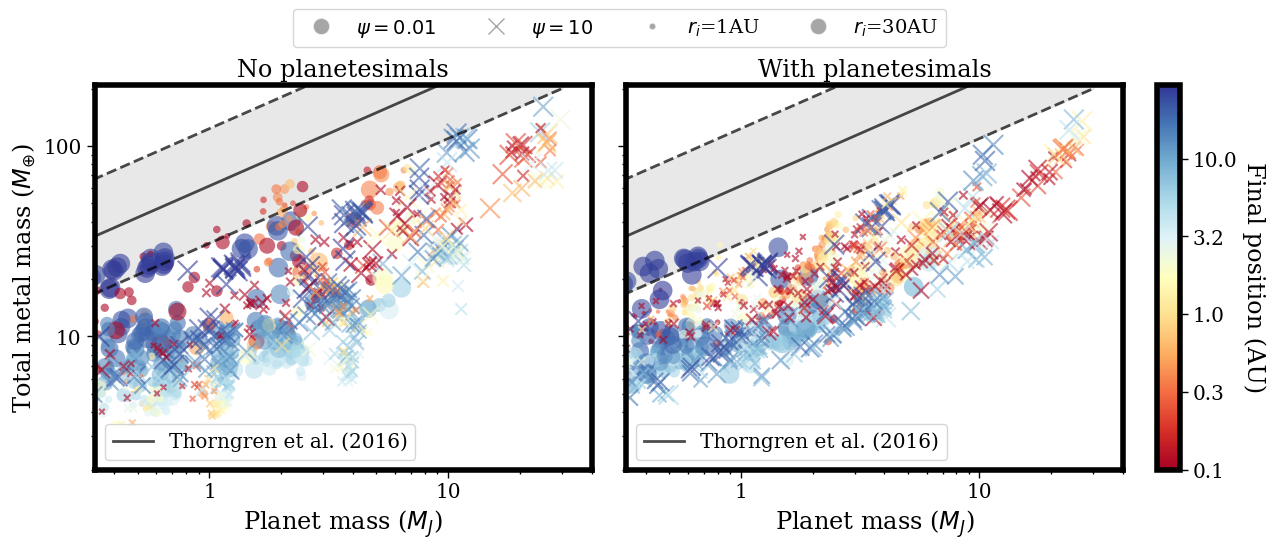

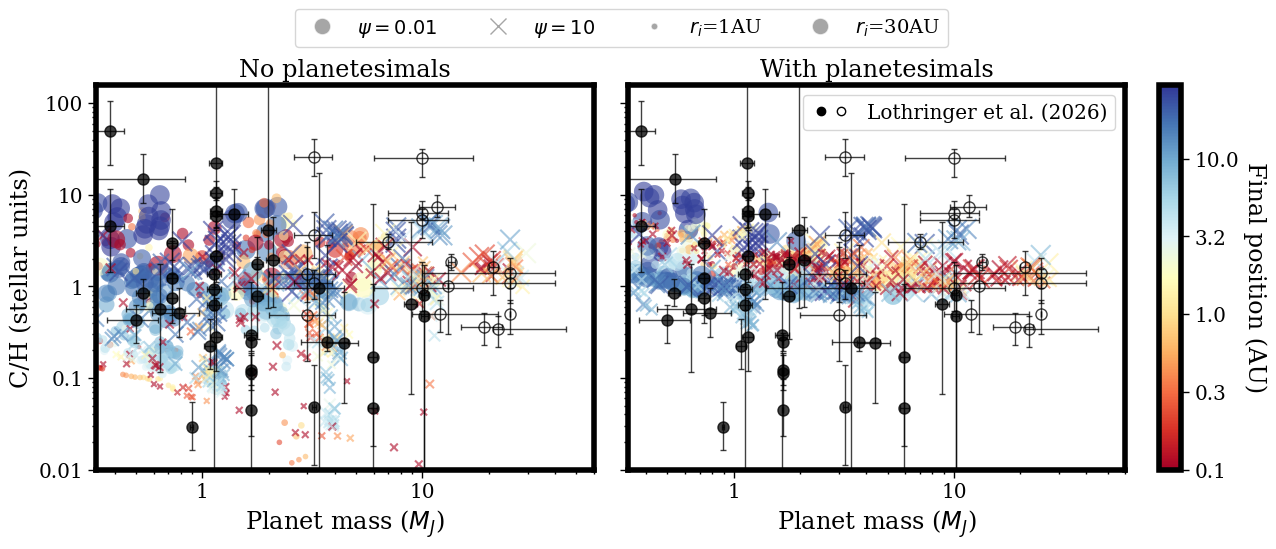

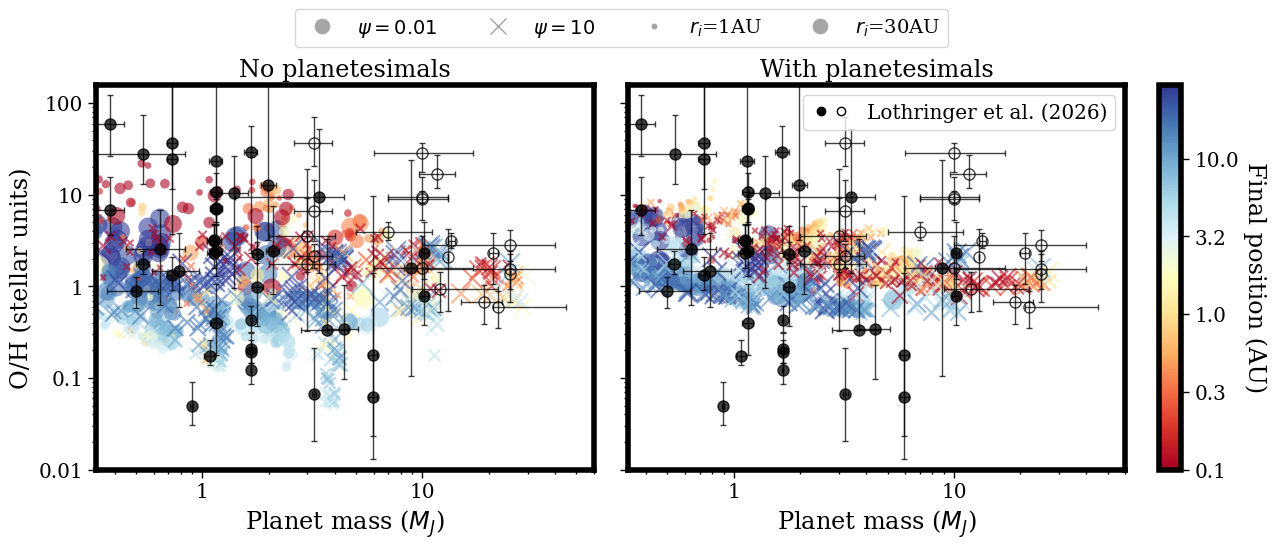

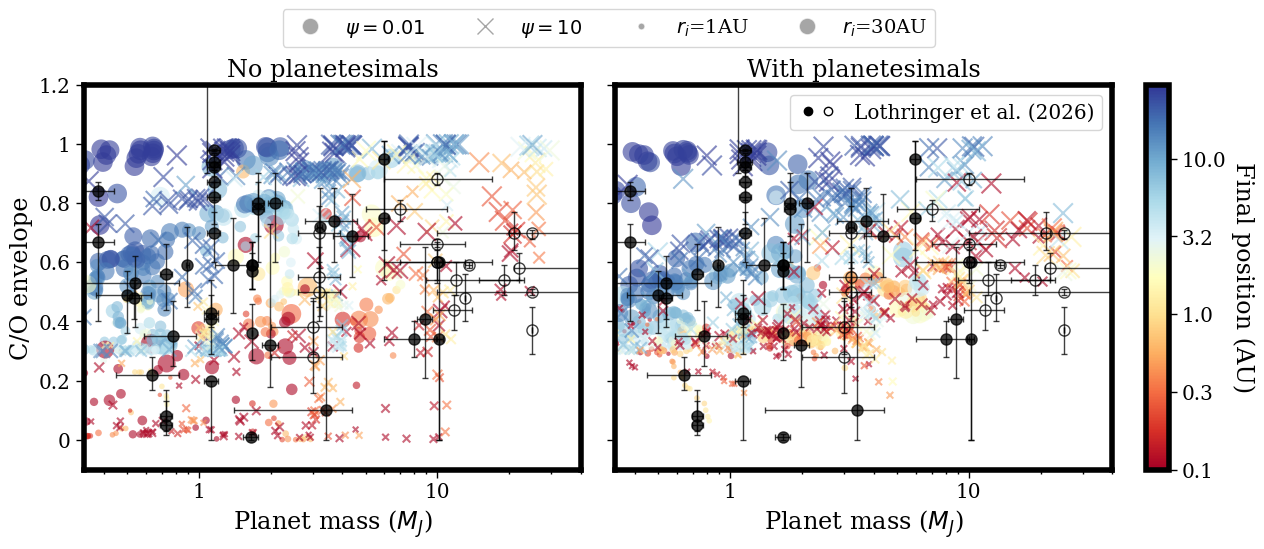

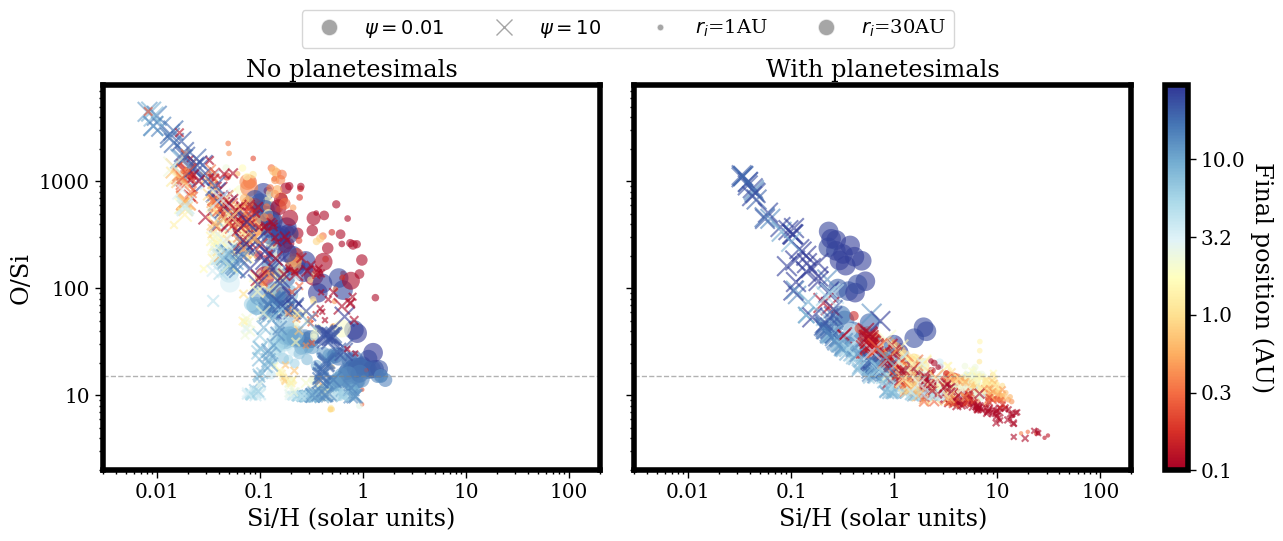

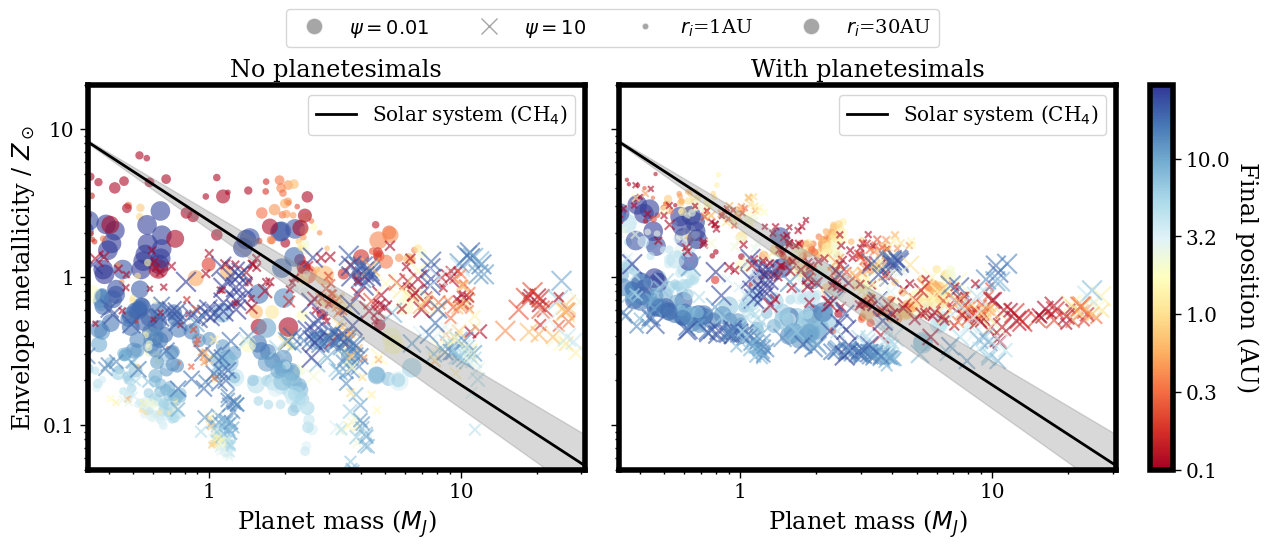

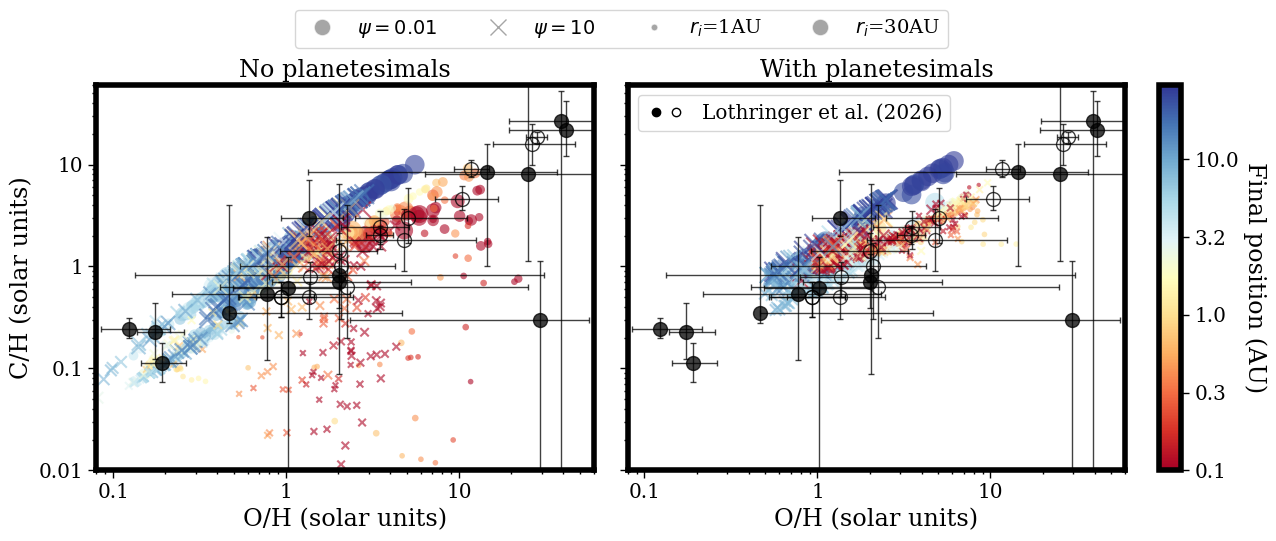

In [30]:
mass_range = np.logspace(np.log10(0.1), np.log10(30), 100)
final_r=df_with_props["final_r"]
final_r_alt=df_with_props_alt["final_r"]
initial_r=df_with_props["initial_r"]
initial_r_alt=df_with_props_alt["initial_r"]


# 1. Total metal mass vs planet mass (Fig 9, c.f. Thorngren et al. 2016)
# Calculate total metal mass in Earth masses
total_metal_mass = dfp["metallicity_total"] * dfp["final_mass"]  # Already in Earth masses
total_metal_mass_alt = dfp_alt["metallicity_total"] * dfp_alt["final_mass"]  # Already in Earth masses


fig, ax1, ax2=plot2_panels(dfp["final_mass"]/317.8, total_metal_mass,
      "Planet mass ($M_J$)", "Total metal mass ($M_⊕$)",final_r=final_r,initial_r=initial_r,xalt=dfp_alt["final_mass"]/317.8,yalt=total_metal_mass_alt,ralt=final_r_alt,ralt2=initial_r_alt)
ax1.set_xscale("log")
ax1.set_yscale("log")
ax2.set_xscale("log")
ax2.set_yscale("log")
ax1.set_xlim(0.33, 40)
ax2.set_xlim(0.33, 40)
ax1.set_ylim(2, 210)
ax2.set_ylim(2, 210)

# Calculate Thorngren relation for metal mass: Z_total * M_planet = 9.7 * M_planet * M_planet^0.45
thorngren_metal_mass = 9.7 * mass_range * mass_range**(-0.45) * 0.02 * 317.8  # Convert MJ to Mearth

# Add shaded regions with zorder=0 to appear behind everything
ax1.fill_between(mass_range, thorngren_metal_mass*0.5, thorngren_metal_mass/0.5, 
                 color='lightgray', alpha=0.5, zorder=0)
ax2.fill_between(mass_range, thorngren_metal_mass*0.5, thorngren_metal_mass/0.5, 
                 color='lightgray', alpha=0.5, zorder=0)

ax1.plot(mass_range, thorngren_metal_mass, 'k-', linewidth=2, alpha=0.7,
         label='Thorngren et al. (2016)', zorder=2)
ax1.plot(mass_range, thorngren_metal_mass*0.5, 'k--', linewidth=2, alpha=0.7, zorder=2)
ax1.plot(mass_range, thorngren_metal_mass/0.5, 'k--', linewidth=2, alpha=0.7, zorder=2)
ax2.plot(mass_range, thorngren_metal_mass, 'k-', linewidth=2, alpha=0.7,
         label='Thorngren et al. (2016)', zorder=2)
ax2.plot(mass_range, thorngren_metal_mass*0.5, 'k--', linewidth=2, alpha=0.7, zorder=2)
ax2.plot(mass_range, thorngren_metal_mass/0.5, 'k--', linewidth=2, alpha=0.7, zorder=2)
ax1.legend(loc='lower left')
ax2.legend(loc='lower left')
# Set custom formatting for clean axis labels
setup_axis_formatting([ax1, ax2])
legend=add_default_legend_top(fig,ax1,ax2)

fig.savefig(os.path.join(FIGDIR, "Mass_vs_total_metal_mass_Thorngren.png"), dpi=300, bbox_inches='tight')

#2a. C/H vs mass (Fig 10, top)
fig, ax1, ax2=plot2_panels(dfp["final_mass"]/317.8, CH_scaled,
      "Planet mass ($M_J$)", "C/H (solar units)",final_r=final_r,initial_r=initial_r,xalt=dfp_alt["final_mass"]/317.8,yalt=CH_scaled_alt,ralt=final_r_alt,ralt2=initial_r_alt)
ax1.set_xscale("log")
ax1.set_yscale("log")
ax2.set_xscale("log")
ax2.set_yscale("log")
add_default_legend_top(fig, ax1, ax2)
#plot_Lothringer_XH_vs_mass("C/H")
plot_Lothringer_XH_vs_mass("C/H", require_solar_reference=False, linear_solar=True, use_sum_for_missing=True,scale_to_stellar=True)
ax1.set_xlim(.33, 60)
ax2.set_xlim(.33, 60)
ax1.set_ylim(0.01, 160)
ax2.set_ylim(0.01,160)
# Set custom formatting for clean axis labels
setup_axis_formatting([ax1, ax2])
fig.savefig(os.path.join(FIGDIR, "CH_vs_MASS_chachan.png"), dpi=300, bbox_inches='tight')

#2b. C/H vs mass (Fig 10, bottom)
fig, ax1, ax2=plot2_panels(dfp["final_mass"]/317.8, OH_scaled,
      "Planet mass ($M_J$)", "O/H (solar units)",final_r=final_r,initial_r=initial_r,xalt=dfp_alt["final_mass"]/317.8,yalt=OH_scaled_alt,ralt=final_r_alt,ralt2=initial_r_alt)
ax1.set_xscale("log")
ax1.set_yscale("log")
ax2.set_xscale("log")
ax2.set_yscale("log")
add_default_legend_top(fig, ax1, ax2)
#plot_Lothringer_XH_vs_mass("O/H")
plot_Lothringer_XH_vs_mass("O/H", require_solar_reference=False, linear_solar=True, use_sum_for_missing=True,scale_to_stellar=True)

ax1.set_xlim(.33, 60)
ax2.set_xlim(.33, 60)
ax1.set_ylim(0.01, 160)
ax2.set_ylim(0.01, 160)
# Set custom formatting for clean axis labels
setup_axis_formatting([ax1, ax2])
fig.savefig(os.path.join(FIGDIR, "OH_vs_MASS_chachan.png"), dpi=300, bbox_inches='tight')


# 3. Envelope C/O vs mass (Fig 11)
fig, ax1, ax2=plot2_panels(dfp["final_mass"]/317.8, dfp["C/O_env"],
      "Planet mass ($M_J$)", "C/O envelope",final_r=final_r,initial_r=initial_r,xalt=dfp_alt["final_mass"]/317.8,yalt=dfp_alt["C/O_env"],ralt=final_r_alt,ralt2=initial_r_alt)
ax1.set_xscale("log")
ax2.set_xscale("log")
plot_Lothringer()
# Set normal notation for axis labels
for ax in [ax1, ax2]:
    ax.xaxis.set_major_formatter(ScalarFormatter())
    ax.xaxis.get_major_formatter().set_scientific(False)
# Set custom formatting for clean axis labels
setup_axis_formatting([ax1, ax2])
ax1.set_xlim(0.33, 40.01)
# ax2.set_xlim(0.0, 1.01)
ax1.set_ylim(-0.1, 1.2)
ax2.set_ylim(-0.1, 1.2)
ax2.set_xlim(0.33, 40.01)
add_default_legend_top(fig,ax1,ax2)
fig.savefig(os.path.join(FIGDIR, "CO_vs_mass_refrac.png"), dpi=300, bbox_inches='tight')

# 4. O/Si vs Si/H plot  (Fig 12)
# Chachan Fig 3 left panel
fig, ax1, ax2=plot2_panels(SiH_scaled, OSi,
      "Si/H (solar units)", "O/Si",final_r=final_r,initial_r=initial_r,xalt=SiH_scaled_alt,yalt=OSi_alt,ralt=final_r_alt,ralt2=initial_r_alt)
ax1.set_xscale("log")
ax1.set_yscale("log")
ax2.set_xscale("log")
ax2.set_yscale("log")
# annotate=False
# plot_chachan_OSi_vs_SiH(ax1, annotate=annotate,model=2)
# plot_chachan_OSi_vs_SiH(ax2, annotate=annotate,model=2)
# add_chachan_legend_top(fig, ax1, ax2)
add_default_legend_top(fig, ax1, ax2)
ax1.set_xlim(.003, 200)
ax2.set_xlim(.003, 200)
ax1.set_ylim(2, 7900)
ax2.set_ylim(2, 7900)
# Set custom formatting for clean axis labels
setup_axis_formatting([ax1, ax2])
# horizontal solar line at O/Si = solar value
#print (OSi_solar_number)
ax1.axhline(OSi_solar_number, color="grey", lw=1, ls="--", alpha=0.6)
ax2.axhline(OSi_solar_number, color="grey", lw=1, ls="--", alpha=0.6)
fig.savefig(os.path.join(FIGDIR, "OSi_vs_SiH_chachan.png"), dpi=300, bbox_inches='tight')

# 5. Mass vs envelope metallicity with Welbanks relations (Fig 17)

fig, ax1, ax2=plot2_panels(dfp["final_mass"]/317.8, dfp["metallicity_env"]/0.02,
      "Planet mass ($M_J$)", "Envelope metallicity / $Z_\\odot$",final_r=final_r,initial_r=initial_r,xalt=dfp_alt["final_mass"]/317.8,yalt=dfp_alt["metallicity_env"]/0.02,ralt=final_r_alt,ralt2=initial_r_alt)
ax1.set_xscale("log")
ax1.set_yscale("log")
ax2.set_xscale("log")
ax2.set_yscale("log")
# Set normal notation for axis labels
ax1.set_xlim(0.33, 31)
ax2.set_xlim(0.33, 31)

# Add Welbanks et al. (2019) reference lines
# H2O/H reference line: (0.01, 15.25) to (9.17, 0.01)
h2o_x = np.array([0.01, 9.17])
h2o_y = np.array([15.25, 0.01])
#ax1.plot(h2o_x, h2o_y, 'g--', linewidth=2, alpha=0.7)
#ax2.plot(h2o_x, h2o_y, 'g--', linewidth=2, alpha=0.7)

# CH4/H reference line: (0.01, 376) to (41.4, 0.04)
Mz_methane(ax1)
Mz_methane(ax2)

ax1.set_ylim(.05, 20)
ax2.set_ylim(.05, 20)
ax1.legend(loc='upper right')
ax2.legend(loc='upper right')
# Set custom formatting for clean axis labels
setup_axis_formatting([ax1, ax2])
add_default_legend_top(fig,ax1,ax2)
fig.savefig(os.path.join(FIGDIR, "Mass_vs_envelope_metallicity_Welbanks.png"), dpi=300, bbox_inches='tight')


# 6. C/H vs O/H plot (Fig 18)
# Chachan Fig 2 right panel
fig, ax1, ax2=plot2_panels(OH_scaled, CH_scaled,
      "O/H (solar units)", "C/H (solar units)",final_r=final_r,initial_r=initial_r,xalt=OH_scaled_alt,yalt=CH_scaled_alt,ralt=final_r_alt,ralt2=initial_r_alt)
ax1.set_xscale("log")
ax1.set_yscale("log")
ax2.set_xscale("log")
ax2.set_yscale("log")
# plot_chachan_CH_vs_OH(ax1, annotate=annotate)
# plot_chachan_CH_vs_OH(ax2, annotate=annotate)
add_default_legend_top(fig, ax1, ax2)
plot_Lothringer_CH_vs_OH(require_solar_reference=False)
ax1.set_xlim(.08, 60)
ax2.set_xlim(.08, 60)
ax1.set_ylim(0.01, 60)
ax2.set_ylim(0.01, 60)
# Set custom formatting for clean axis labels
setup_axis_formatting([ax1, ax2])
fig.savefig(os.path.join(FIGDIR, "CH_vs_OH_chachan.png"), dpi=300, bbox_inches='tight')




# Resolution Tests

Saved /Users/mbalogh/projects/PlanetFormation/python/DiscEvolution/example/summer_2025/V3/Figs/highres/sigmaT_comparison_M0.10_Rd50.png
Saved /Users/mbalogh/projects/PlanetFormation/python/DiscEvolution/example/summer_2025/V3/Figs/highres/sigmaT_comparison_M0.10_Rd50.png
Saved /Users/mbalogh/projects/PlanetFormation/python/DiscEvolution/example/summer_2025/V3/Figs/highres/sigmaT_comparison_M0.10_Rd50.png
Saved /Users/mbalogh/projects/PlanetFormation/python/DiscEvolution/example/summer_2025/V3/Figs/highres/dust_comparison_M0.10_Rd50.png
Saved /Users/mbalogh/projects/PlanetFormation/python/DiscEvolution/example/summer_2025/V3/Figs/highres/chem_comparison_M0.10_Rd50.png
Saved /Users/mbalogh/projects/PlanetFormation/python/DiscEvolution/example/summer_2025/V3/Figs/highres/CHOH_comparison_M0.10_Rd50.png
Saved /Users/mbalogh/projects/PlanetFormation/python/DiscEvolution/example/summer_2025/V3/Figs/highres/CHOH_ice_comparison_M0.10_Rd50.png
Saved /Users/mbalogh/projects/PlanetFormation/python

(<Figure size 1200x1000 with 4 Axes>,
 array([[<AxesSubplot: title={'center': '$\\psi$=0.01'}, ylabel='dust/gas ratio'>,
         <AxesSubplot: title={'center': '$\\psi$=10.0'}, ylabel='dust/gas ratio'>],
        [<AxesSubplot: xlabel='Radius [AU]', ylabel='Stokes number'>,
         <AxesSubplot: xlabel='Radius [AU]', ylabel='Stokes number'>]],
       dtype=object))

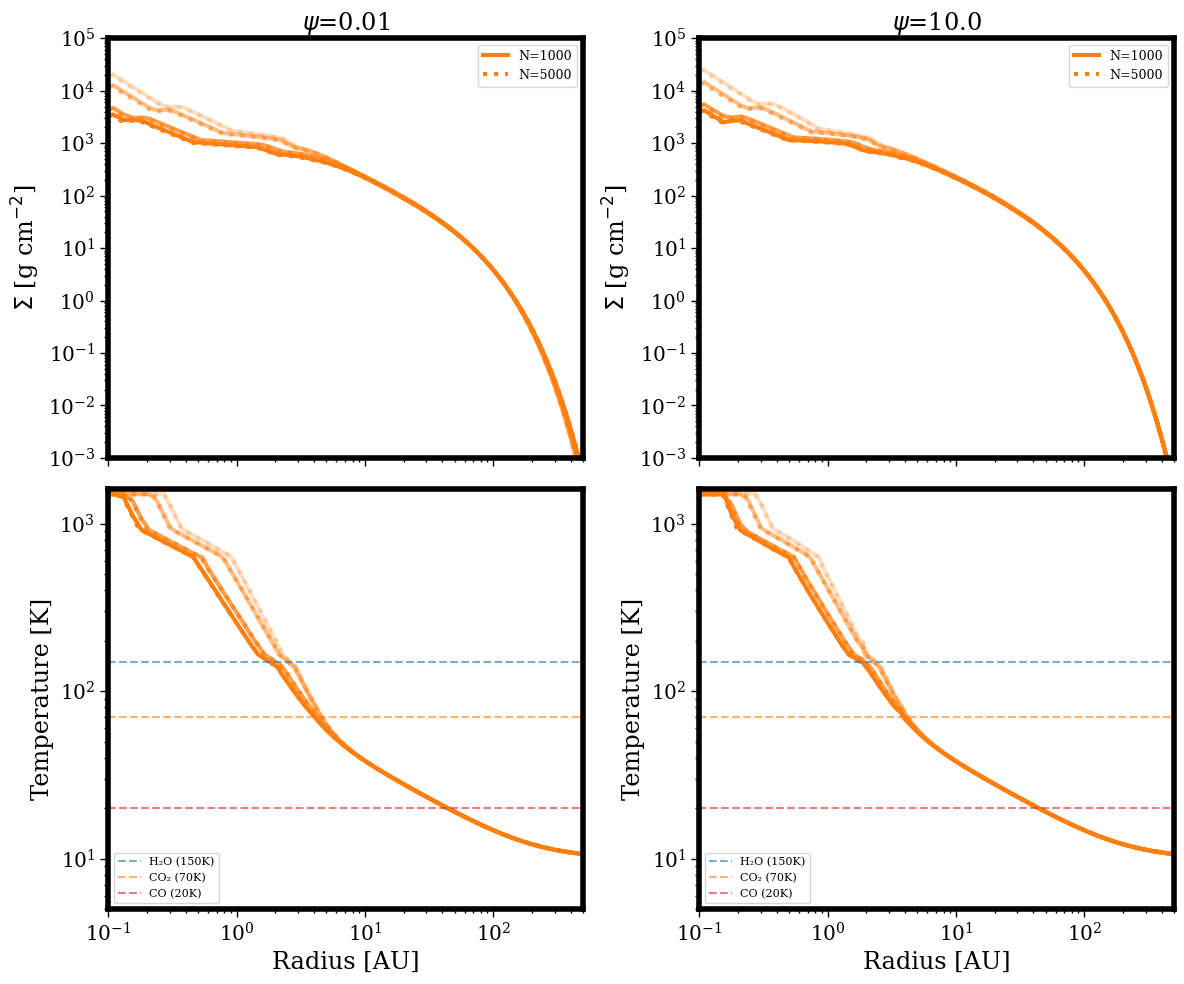

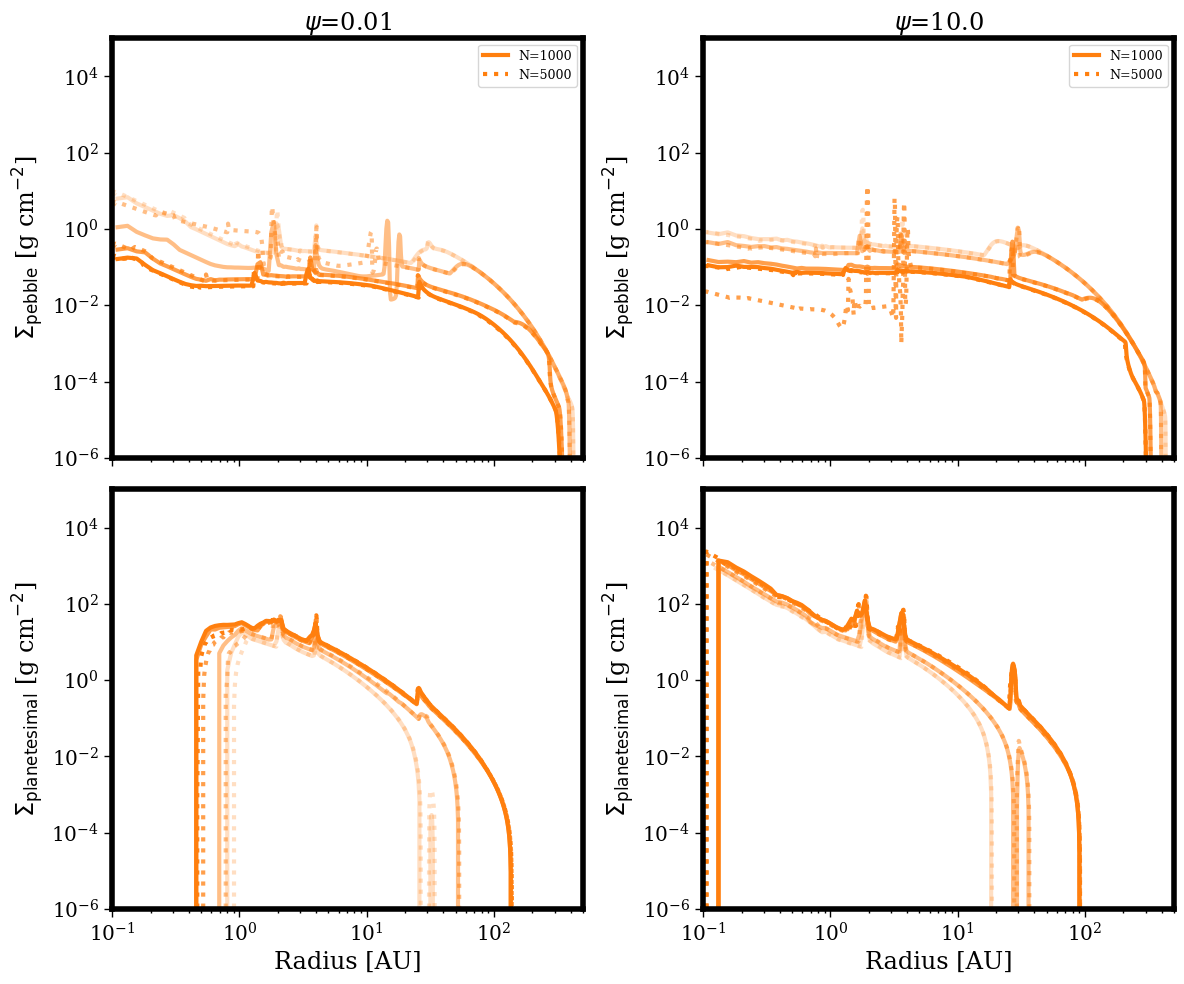

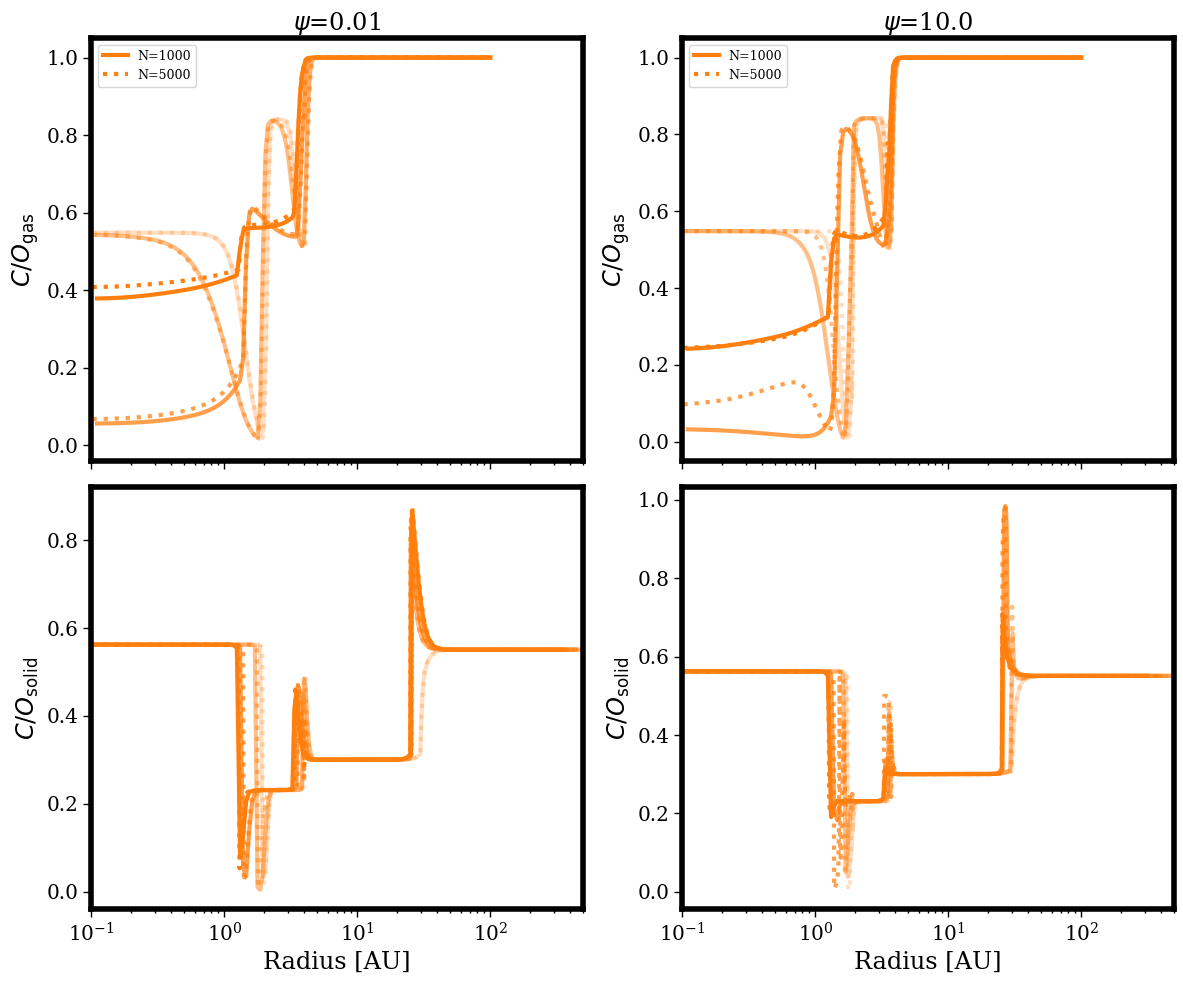

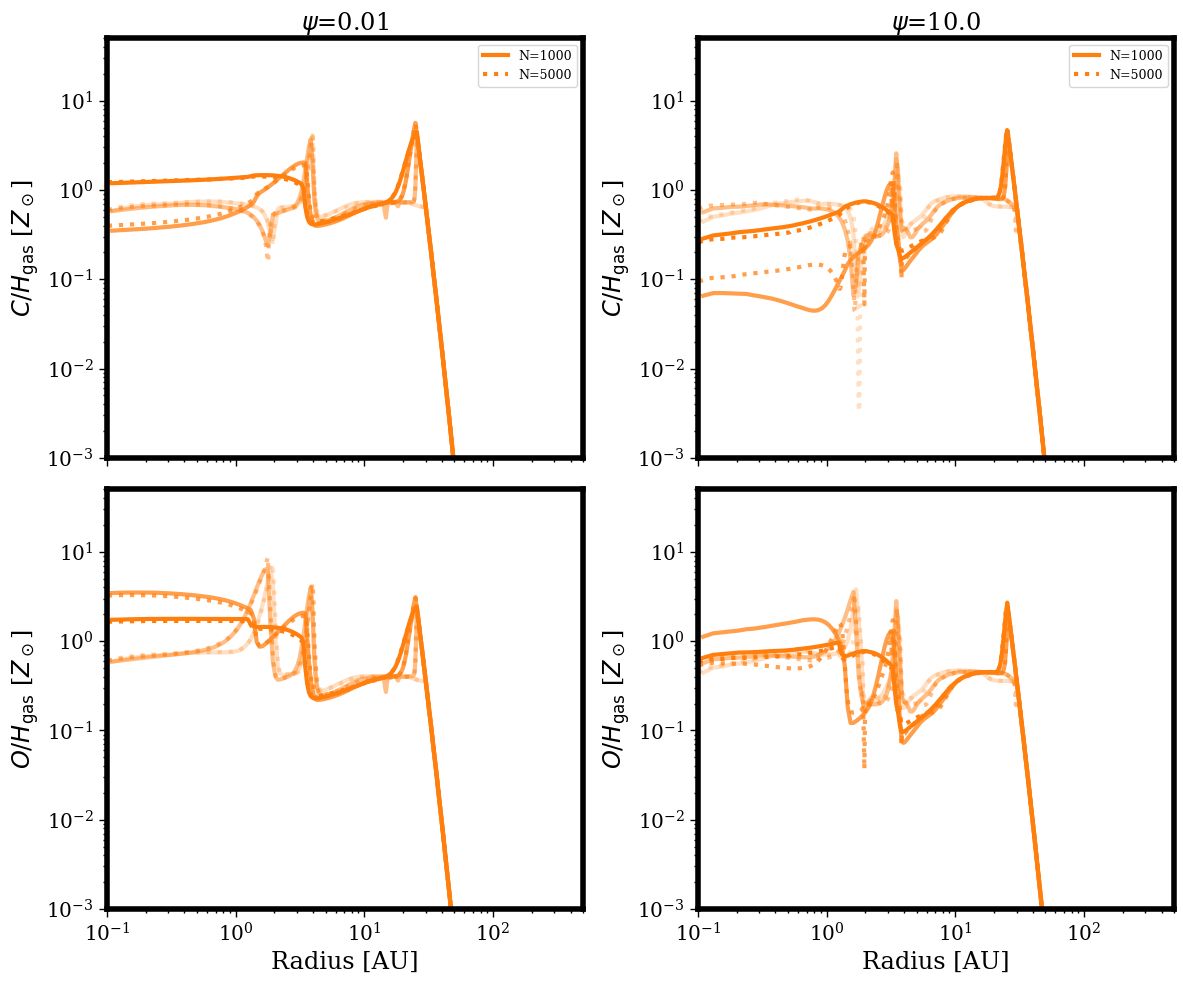

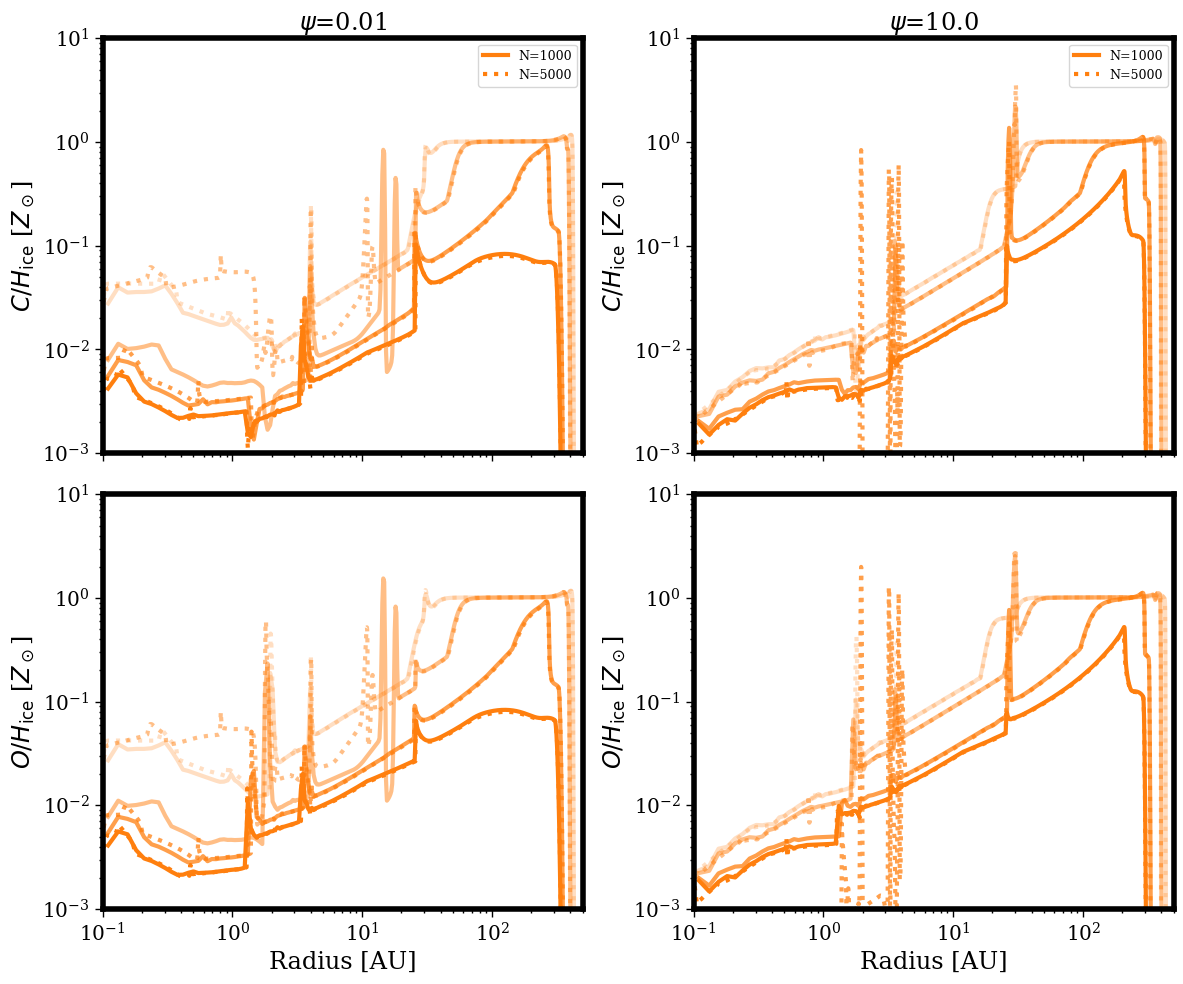

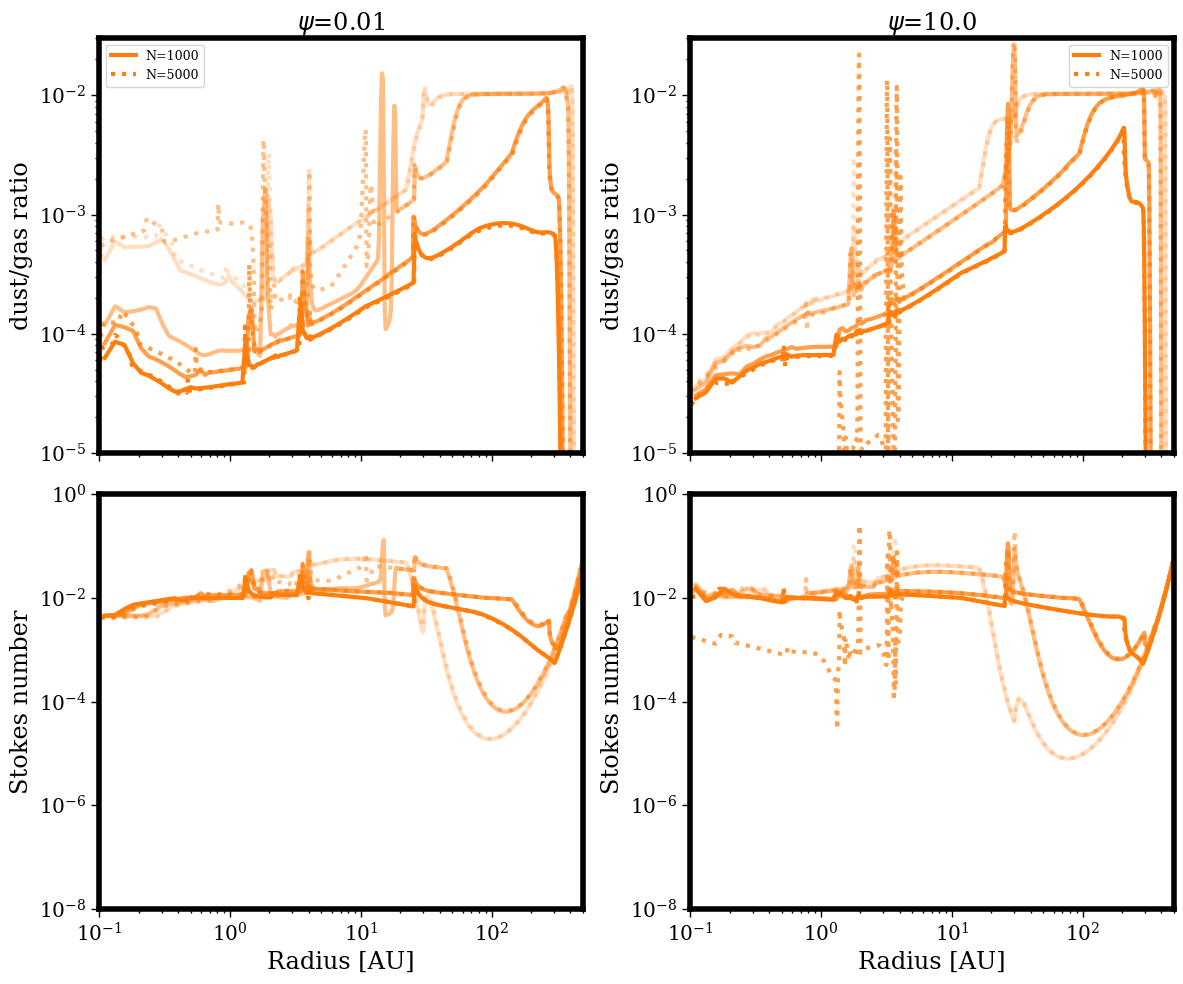

In [ ]:
RESDIR=DATADIR+"highres/"
RESFIG=FIGDIR+"highres/"
headers=("winds_mig_psi","highres_winds_mig_psi")
mdot = 1.e-8
psis=(0.01, 10.0)
#times=[0.0,0.1,0.5,1,3]
times=[0.1, 0.2, 1, 2]

def plot_disk_comparison_restest(kind, outdirs=(DATADIR,DATADIR), M=0.05, Rd=100,
                         mdot=1e-8, psis=(0.01, 0.01),
                         times=(0.01, 0.1, 0.5, 1, 2, 3),
                         figdir=None, planets=True,headers=("winds_mig_psi","highres_winds_mig_psi")):
    """
    Generic 4-panel plot for viscous / windy discs.
    kind ∈ {"sigmaT","dust","chem","CHOH","CHOH_ice","dustprop"}
    """
    #labels=("N=1000","N=5000")
    if kind not in PLOT_RECIPES:
        raise ValueError(f"Unknown plot kind '{kind}'")

    recipe = PLOT_RECIPES[kind]

    fig, axes = plt.subplots(2, 2, figsize=(12,10),
                             sharex=True, constrained_layout=True)
    # Radius is always treated logarithmically in the original plots
    for ax in axes.ravel():
        ax.set_xscale("log")

    linestyles = ["solid", "dotted"]
    mdot_colors = {mdots[0]: "tab:blue", mdots[1]: "tab:orange"}

    times = np.array(times, float)
    ntime = len(times)

    # Loop over psi (columns)
    for col, psi in enumerate(psis):

        for ls, header, outdir in zip(linestyles, headers,outdirs):

            # Build filename
            if psi < 1:
                file = f"{header}{psi:.2f}_Mdot{mdot:.1e}_M{M:.1e}_Rd{Rd:.1e}.h5"
            else:
                file = f"{header}{psi:.1f}_Mdot{mdot:.1e}_M{M:.1e}_Rd{Rd:.1e}.h5"
            fpath = os.path.join(outdir, file)

            try:
                data = load_data(fpath,planets=planets)
            except Exception as e:
                print(f"⚠️ Missing {fpath}: {e}")
                continue

            R = np.array(data["R"], float)
            N=np.shape(R)
            t_snap = np.array(data.get("time_snap", []), float)
            if t_snap.size == 0:
                t_snap = np.array([0,1e-3,1e-2,1e-1,0.2,0.5,1,2,3], float)

            # times → snapshot indices
            idxs = [np.argmin(abs(t_snap - tt)) for tt in times]

            # Loop over chosen times
            for k, idx in enumerate(idxs):
                alpha = (k+1)/ntime
                stuff = recipe(data, idx)

                # upper panel
                up = stuff["upper"]
                lo = stuff["lower"]

                if stuff["ylog_upper"]:
                    axes[0,col].loglog(R, up, ls=ls, color=mdot_colors[mdot], alpha=alpha)
                else:
                    axes[0,col].plot(R, up, ls=ls, color=mdot_colors[mdot], alpha=alpha)

                # lower panel
                if stuff["ylog_lower"]:
                    axes[1,col].loglog(R, lo, ls=ls, color=mdot_colors[mdot], alpha=alpha)
                else:
                    axes[1,col].plot(R, lo, ls=ls, color=mdot_colors[mdot], alpha=alpha)

            axes[0,col].plot([],[], ls=ls, color=mdot_colors[mdot],
                             label="N="+str(N[0]))

        # Labels and titles
        example = recipe(data, idx=0)
        axes[0,col].set_ylabel(example["ylabel_upper"])
        axes[1,col].set_ylabel(example["ylabel_lower"])
        axes[1,col].set_xlabel("Radius [AU]")
        axes[0,col].set_title(f"$\psi$={psi}")

        if example["ylim_upper"]:
            axes[0,col].set_ylim(*example["ylim_upper"])
        if example["ylim_lower"]:
            axes[1,col].set_ylim(*example["ylim_lower"])

        axes[0,col].legend(fontsize=9)
        axes[0,col].set_xlim(0.1, 500)
        axes[1,col].set_xlim(0.1, 500)

    plt.tight_layout()

    if figdir:
        outname = os.path.join(figdir, f"{kind}_comparison_M{M:.2f}_Rd{Rd}.png")
        fig.savefig(outname, dpi=300)
        print(f"Saved {outname}")
    else:
        plt.show()

    return fig, axes


# Condensation temperatures for ice lines (K)
condensation_temps = {
    "H₂O": 150,
    "CO₂": 70,
    #"CH₄": 30,
    "CO": 20,
}

colors_ice = {
    "H₂O": "#1f77b4",
    "CO₂": "#ff7f0e",
   # "CH₄": "#2ca02c",
    "CO": "#d62728",
}
M=0.1
Rd=50
plot_disk_comparison_restest("sigmaT",    (DATADIR,RESDIR), M=M, Rd=Rd, mdot=mdot,
                     psis=(0.01,10.0), times=times,planets=True,figdir=RESFIG,headers=headers)
fig = plt.gcf()
axes = fig.get_axes()
for col_idx in [0, 1]:  # Two columns
    ax_temp = axes[2 + col_idx]  # Lower panels are indices 2 and 3
    for species, temp in condensation_temps.items():
        ax_temp.axhline(temp, color=colors_ice[species], linestyle="--", 
                       linewidth=1.5, alpha=0.6, label=f"{species} ({temp}K)")
    ax_temp.legend(fontsize=8, loc="lower left")
    if RESFIG:
        outname = os.path.join(RESFIG, f"sigmaT_comparison_M{M:.2f}_Rd{Rd}.png")
        fig.savefig(outname, dpi=300)
        print(f"Saved {outname}")
    else:
        plt.show()


plot_disk_comparison_restest("dust",      (DATADIR,RESDIR), M=M, Rd=Rd, mdot=mdot,
                     psis=psis, times=times,planets=True,figdir=RESFIG,headers=headers)
plot_disk_comparison_restest("chem",      (DATADIR,RESDIR), M=M, Rd=Rd, mdot=mdot,
                     psis=psis, times=times,planets=True,figdir=RESFIG,headers=headers)
plot_disk_comparison_restest("CHOH",      (DATADIR,RESDIR), M=M, Rd=Rd, mdot=mdot,
                     psis=psis, times=times,planets=True,figdir=RESFIG,headers=headers)
plot_disk_comparison_restest("dustprop2",  (DATADIR,RESDIR), M=M, Rd=Rd, mdot=mdot,
                     psis=psis, times=times,planets=True,figdir=RESFIG,headers=headers)


✅ Saved figure to /Users/mbalogh/projects/PlanetFormation/python/DiscEvolution/example/summer_2025/V3/Figs/highres/winds_mig_psi10.0-10.0_Mdot1e-08_M1e-01_Rd50_Total_mass_M_vs_Distance_AU_envelope.png


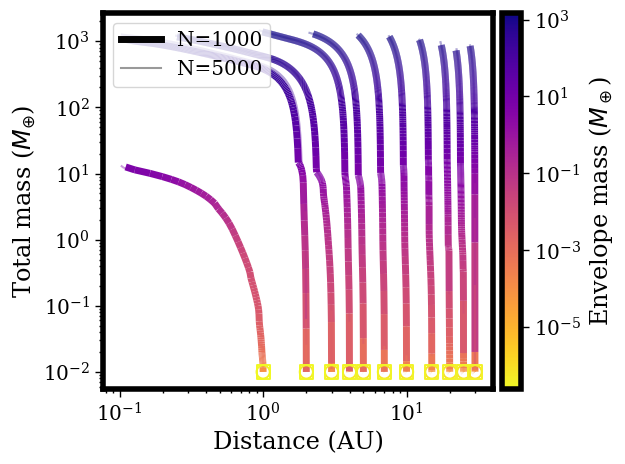

Adding solar C/O reference line at 0.55
✅ Saved figure to /Users/mbalogh/projects/PlanetFormation/python/DiscEvolution/example/summer_2025/V3/Figs/highres/winds_mig_psi10.0-10.0_Mdot1e-08_M1e-01_Rd50_C_O_envelope_vs_Distance_AU_envelope.png


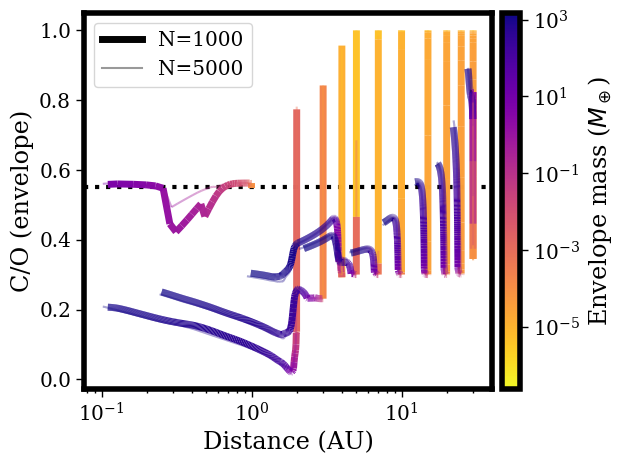

Adding solar C/O reference line at 0.55
✅ Saved figure to /Users/mbalogh/projects/PlanetFormation/python/DiscEvolution/example/summer_2025/V3/Figs/highres/winds_mig_psi10.0-10.0_Mdot1e-08_M1e-01_Rd50_C_O_envelope_vs_Envelope_mass_M_core.png


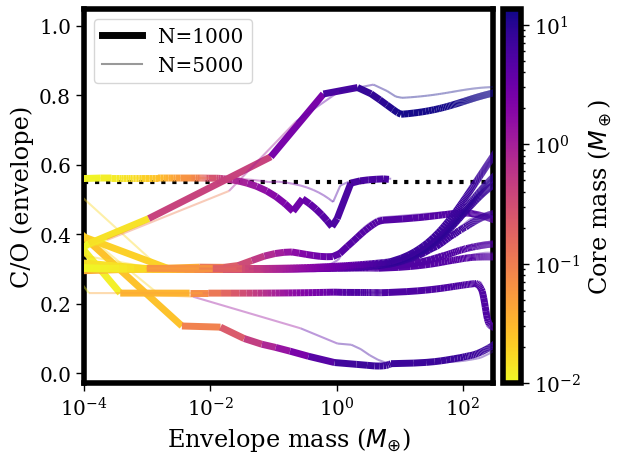

✅ Saved figure to /Users/mbalogh/projects/PlanetFormation/python/DiscEvolution/example/summer_2025/V3/Figs/highres/winds_mig_psi10.0-10.0_Mdot1e-08_M1e-01_Rd50_O_Si_vs_Distance_AU_envelope.png


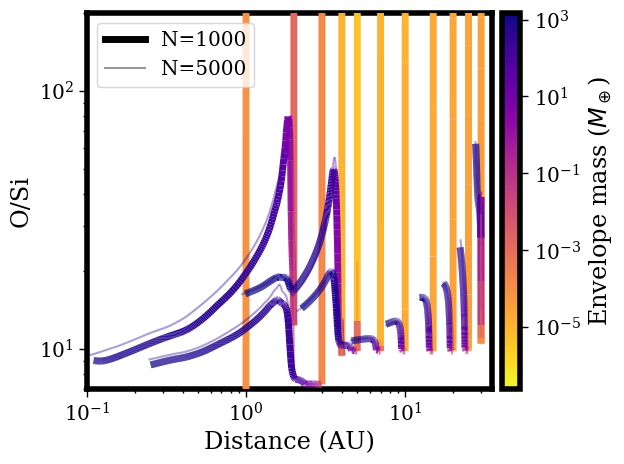

✅ Saved figure to /Users/mbalogh/projects/PlanetFormation/python/DiscEvolution/example/summer_2025/V3/Figs/highres/winds_mig_psi10.0-10.0_Mdot1e-08_M1e-01_Rd50_O_H_solar_vs_C_H_solar_envelope.png


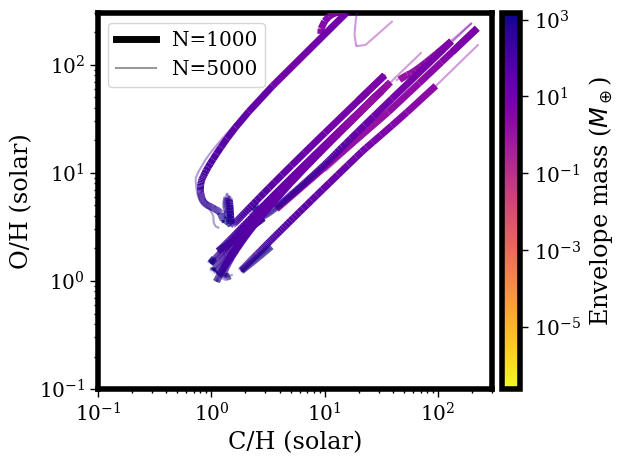

In [54]:

# Wind model shows some sensitivity to resolution, so test effect on main outputs here
# Common to all plots
FIGDIR=WORKINGDIR+'Figs/highres/'
psicompare=(10.0, 10.0)
Mdotcompare=(1.0e-8, 1.0e-8)
Mdiskcompare=(0.1, 0.1)
Rdcompare=(50, 50)
planets=np.array([0,1,2,3,4,5,6,7,8,9,10])
headers=("winds_mig","highres/highres_winds_mig")

# ==== COMPARISON PLOTS ====
Menv=lambda d, i: np.array(d["Mes"][i])
Menvlabel="Envelope Mass (M$_⊕$)"
OSi_env=lambda d,i: (d["ratios"] if "ratios" in d else compute_abundance_ratios(d, by_number=True, scaled_to_solar=False))["O/Si_env"][i]
OSi_label="O/Si"
#xlim=(.01,300)
#ylim=(7,200)

# 1.  Planet growth tracks
compare_models(
    outdir=DATADIR,
    Psi=psicompare,
    Mdot=Mdotcompare,
    Mdisk=Mdiskcompare,
    Rd=Rdcompare,
    planets=planets,
    xkey="Rp",
    ykey=lambda d,i: np.array(d["Mcs"][i]) + np.array(d["Mes"][i]),
    xlabel="Distance (AU)",
    ylabel="Total mass ($M_⊕$)",
    labels=("N=1000","N=5000"),
    titlepos=(0.15, 0.25),
    figdir=FIGDIR,
    header=headers,
    time_marker_interval=0.33
)
# 2. C/O vs distance
compare_models(
    outdir=DATADIR,
    Psi=psicompare,
    Mdot=Mdotcompare,
    Mdisk=Mdiskcompare,
    Rd=Rdcompare,
    planets=planets,
    xkey="Rp",
    ykey=lambda d,i: (d["ratios"] if "ratios" in d else compute_abundance_ratios(d, by_number=True, scaled_to_solar=False))["C/O_env"][i],
    xlabel="Distance (AU)",
    ylabel="C/O (envelope)",
    labels=("N=1000","N=5000"),
    logy=False,
    logx=True,
    figdir=FIGDIR,
    header=headers,
    time_marker_interval=0.33,
    color_by="envelope",
    show_time_markers=False,
    draw_solarCO=True)
# 3. C/O vs envelope mass
compare_models(
    outdir=DATADIR,
    Psi=psicompare,
    Mdot=Mdotcompare,
    Mdisk=Mdiskcompare,
    Rd=Rdcompare,
    planets=planets,
    xkey=Menv,
    ykey=lambda d,i: (d["ratios"] if "ratios" in d else compute_abundance_ratios(d, by_number=True, scaled_to_solar=False))["C/O_env"][i],
    xlabel="Envelope mass ($M_⊕$)",
    ylabel="C/O (envelope)",
    labels=("N=1000","N=5000"),
    logy=False,
    logx=True,
    figdir=FIGDIR,
    header=headers,
    time_marker_interval=0.33,
    color_by="core",
    xlim=(.0001,300),
    show_time_markers=False,
    draw_solarCO=True)
#4. O/Si vs distance
compare_models(
    outdir=DATADIR,
    Psi=psicompare,
    Mdot=Mdotcompare,
    Mdisk=Mdiskcompare,
    Rd=Rdcompare,
    planets=planets,
    xkey="Rp",
    ykey=OSi_env,
    xlabel="Distance (AU)",
    ylabel=OSi_label,
    labels=("N=1000","N=5000"),
    logy=True,
    logx=True,
    figdir=FIGDIR,
    header=headers,
    titlepos=(0.15, 0.95),
    time_marker_interval=0.5,
    xlim=(0.1,35),
    ylim=(7,200)
)
#5. C/H vs O/H (solar), recomputed consistently and masked at tiny envelope mass
MIN_ENV_MASS = 1.0  # Earth masses; raise to 1e-3 if you still see spikes

def CH_env_solar_track(d, i):
    r = compute_abundance_ratios(
        d,
        by_number=True,
        scaled_to_solar=True,
        hydrogen_model="primordial",
        cache=False,   # avoid stale d["ratios"] from earlier calls
    )
    ch = np.asarray(r["C/H_env"][i], dtype=float)
    me = np.asarray(d["Mes"][i], dtype=float)
    ch[me < MIN_ENV_MASS] = np.nan
    return ch

def OH_env_solar_track(d, i):
    r = compute_abundance_ratios(
        d,
        by_number=True,
        scaled_to_solar=True,
        hydrogen_model="primordial",
        cache=False,
    )
    oh = np.asarray(r["O/H_env"][i], dtype=float)
    me = np.asarray(d["Mes"][i], dtype=float)
    oh[me < MIN_ENV_MASS] = np.nan
    return oh

compare_models(
    outdir=DATADIR,
    Psi=psicompare,
    Mdot=Mdotcompare,
    Mdisk=Mdiskcompare,
    Rd=Rdcompare,
    planets=planets,
    xkey=CH_env_solar_track,
    ykey=OH_env_solar_track,
    xlabel="C/H (solar)",
    ylabel="O/H (solar)",
    labels=("N=1000","N=5000"),
    logy=True,
    logx=True,
    figdir=FIGDIR,
    header=headers,
    titlepos=(0.15, 0.95),
    time_marker_interval=0.5,
    xlim=(0.1, 300),
    ylim=(0.1, 300),
    color_by="envelope",
    show_time_markers=False,
)
#5. C/H vs O/H
# compare_models(
#     outdir=DATADIR,
#     Psi=psicompare,
#     Mdot=Mdotcompare,
#     Mdisk=Mdiskcompare,
#     Rd=Rdcompare,
#     planets=planets,
#     xkey=lambda d,i: (d["ratios"] if "ratios" in d else compute_abundance_ratios(d, by_number=True, scaled_to_solar=True))["C/H_env"][i],
#     ykey=lambda d,i: (d["ratios"] if "ratios" in d else compute_abundance_ratios(d, by_number=True, scaled_to_solar=True))["O/H_env"][i],
#     xlabel="C/H (solar)",
#     ylabel="O/H (solar)",
#     labels=("N=1000","N=5000"),
#     logy=True,
#     logx=True,
#     figdir=FIGDIR,
#     header=headers,
#     titlepos=(0.15, 0.95),
#     time_marker_interval=0.5,
#     xlim=(0.1,10000),
#     ylim=(0.01,10000)
# )

FIGDIR=WORKINGDIR+'Figs/'
